# Tarea 3: Cross-Dataset Ecological Modeling
**Team members**: [Renato Fernández] , [Vicente Vargas]

**Region**: [Región Metropolitana de Santiago (Maipú)]

**Date**: [05/03/2026]

## Part 0: Building the Analytical Table

### 0.1 Class-pooled master table

Primero se revisaron los archivos subidos por todos los grupos al data pool. A la fecha de trabajo, de los 21 grupos esperados, el grupo 14 no había subido sus archivos, por lo que no fue posible incorporarlo en esta revisión.

El primer control fue verificar que todos los archivos tuvieran una columna llamada `codigo_comuna`, ya que esta variable es la llave principal para unir las bases. Antes de hacer esta revisión, también fue necesario corregir manualmente algunos nombres de archivos que no seguían el formato esperado. Por ejemplo, algunos tenían palabras adicionales como `census_teamNN.csv_Santiago`, mientras que otros no usaban dos dígitos para el número de grupo, como `census_teamN.csv` en vez de `census_teamNN.csv`.

In [143]:
import pandas as pd
import glob
import re
import os
import shutil
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import textwrap
import warnings
from adjustText import adjust_text
import statsmodels.api as sm
import zipfile
import geopandas as gpd
import matplotlib as mpl
import matplotlib.patheffects as pe

In [144]:
# Buscar archivos csv
archivos = glob.glob("*.csv")

resultados = []
archivos_sin_codigo = []

# Revisar archivo por archivo
for archivo in archivos:
    try:
        df = pd.read_csv(archivo, encoding="utf-8-sig")
    except UnicodeDecodeError:
        df = pd.read_csv(archivo, encoding="latin-1")

    # Limpiar nombres de columnas
    df.columns = df.columns.str.strip()

    # Buscar columna codigo_comuna
    columnas_match = [
        col for col in df.columns
        if col.strip().lower() == "codigo_comuna"
    ]

    if len(columnas_match) == 0:
        archivos_sin_codigo.append(archivo)
        continue

    col_codigo = columnas_match[0]

    # Extraer número de grupo
    grupo_match = re.search(r"team(\d+)", archivo)
    grupo = grupo_match.group(1) if grupo_match else "No identificado"

    # Extraer tipo de archivo
    tipo = archivo.split("_team")[0]

    # Obtener comunas únicas del archivo
    comunas = (
        df[col_codigo]
        .dropna()
        .astype(str)
        .str.strip()
        .unique()
    )

    for comuna in comunas:
        resultados.append({
            "archivo": archivo,
            "tipo": tipo,
            "grupo": grupo,
            "codigo_comuna": comuna
        })

# Crear tabla base
revision_comunas = pd.DataFrame(resultados)

# Buscar comunas repetidas
comunas_repetidas = (
    revision_comunas
    .groupby("codigo_comuna")
    .agg(
        n_archivos=("archivo", "nunique"),
        grupos=("grupo", lambda x: ", ".join(sorted(set(x)))),
        archivos=("archivo", lambda x: ", ".join(sorted(set(x))))
    )
    .reset_index()
)

comunas_repetidas = comunas_repetidas[
    comunas_repetidas["n_archivos"] > 1
].sort_values("codigo_comuna")

# Mostrar resultados
print("Comunas repetidas entre archivos:")
display(comunas_repetidas)

print("\nArchivos sin columna codigo_comuna:")
if len(archivos_sin_codigo) == 0:
    print("Todos los archivos tienen columna codigo_comuna.")
else:
    for archivo in archivos_sin_codigo:
        print(archivo)

Comunas repetidas entre archivos:


,codigo_comuna,n_archivos,grupos,archivos
0,13101,3,04,"census_team04.csv, eno_team04.csv, grd_team04.csv"
1,13102,3,11,"census_team11.csv, eno_team11.csv, grd_team11.csv"
2,13104,3,19,"census_team19.csv, eno_team19.csv, grd_team19.csv"
3,13105,6,"11, 12","census_team11.csv, census_team12.csv, eno_team11.csv, eno_team12.csv, grd_team11.csv, grd_team12.csv"
4,13107,3,13,"census_team13.csv, eno_team13.csv, grd_team13.csv"
5,13108,3,09,"census_team09.csv, eno_team09.csv, grd_team09.csv"
6,13109,6,"03, 19","census_team03.csv, census_team19.csv, eno_team03.csv, eno_team19.csv, grd_team03.csv, grd_team19.csv"
7,13110,3,02,"census_team02.csv, eno_team02.csv, grd_team02.csv"
8,13111,3,01,"census_team01.csv, eno_team01.csv, grd_team01.csv"
9,13112,3,13,"census_team13.csv, eno_team13.csv, grd_team13.csv"



Archivos sin columna codigo_comuna:
Todos los archivos tienen columna codigo_comuna.


Como se puede observar, los archivos `census_team07.csv` y `eno_team07.csv` no tenían la columna con el nombre esperado `codigo_comuna`. Al revisarlos manualmente, identificamos que en `census_team07.csv` la columna equivalente se llamaba `comuna`, mientras que en `eno_team07.csv` aparecía como `codigo_comuna_residencia`. Con lo cual, a continuación nos dispusimos a revisar si no existían comunas duplicadas utilizadas por grupos diferentes. **Cabe señalar que estas correcciones se aplicaron directamente sobre los archivos originales, no sobre una copia. Por eso, una vez al ejecutar todas las celdas una vez terminada la tarea, esos errores iniciales ya no aparecen en la revisión y los archivos se ven como si hubieran estado correctos desde el principio.**

In [146]:
# Mostrar texto completo en tablas
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

# Buscar archivos csv
archivos = glob.glob("*.csv")

resultados = []
archivos_sin_codigo = []

# Detectar columna de código
def detectar_columna_codigo(df, archivo):
    columnas = {col.strip().lower(): col for col in df.columns}

    if "codigo_comuna" in columnas:
        return columnas["codigo_comuna"]

    if archivo == "census_team07.csv" and "comuna" in columnas:
        return columnas["comuna"]

    if archivo == "eno_team07.csv" and "codigo_comuna_residencia" in columnas:
        return columnas["codigo_comuna_residencia"]

    return None

# Revisar archivos
for archivo in archivos:
    try:
        df = pd.read_csv(archivo, encoding="utf-8-sig")
    except UnicodeDecodeError:
        df = pd.read_csv(archivo, encoding="latin-1")

    df.columns = df.columns.str.strip()

    col_codigo = detectar_columna_codigo(df, archivo)

    if col_codigo is None:
        archivos_sin_codigo.append(archivo)
        continue

    grupo_match = re.search(r"team(\d+)", archivo)
    grupo = grupo_match.group(1) if grupo_match else "No identificado"

    tipo = archivo.split("_team")[0]

    comunas = (
        df[col_codigo]
        .dropna()
        .astype(str)
        .str.strip()
        .unique()
    )

    for comuna in comunas:
        resultados.append({
            "archivo": archivo,
            "tipo": tipo,
            "grupo": grupo,
            "codigo_comuna": comuna
        })

revision_comunas = pd.DataFrame(resultados)

# Repeticiones dentro del mismo grupo
repetidas_mismo_grupo = (
    revision_comunas
    .groupby(["codigo_comuna", "grupo"])
    .agg(
        n_archivos=("archivo", "nunique"),
        archivos=("archivo", lambda x: ", ".join(sorted(set(x))))
    )
    .reset_index()
)

repetidas_mismo_grupo = repetidas_mismo_grupo[
    repetidas_mismo_grupo["n_archivos"] > 1
].sort_values(["codigo_comuna", "grupo"])

# Repeticiones entre grupos distintos
repetidas_distinto_grupo = (
    revision_comunas
    .groupby("codigo_comuna")
    .agg(
        n_grupos=("grupo", "nunique"),
        grupos=("grupo", lambda x: ", ".join(sorted(set(x)))),
        archivos=("archivo", lambda x: ", ".join(sorted(set(x))))
    )
    .reset_index()
)

repetidas_distinto_grupo = repetidas_distinto_grupo[
    repetidas_distinto_grupo["n_grupos"] > 1
].sort_values("codigo_comuna")

# Mostrar resultados
print("Comunas repetidas dentro del mismo grupo:")
display(repetidas_mismo_grupo)

print("Comunas repetidas entre grupos distintos:")
display(repetidas_distinto_grupo)

print("Archivos sin columna de código reconocida:")
if len(archivos_sin_codigo) == 0:
    print("Todos los archivos tienen columna de código reconocida.")
else:
    for archivo in archivos_sin_codigo:
        print(archivo)

Comunas repetidas dentro del mismo grupo:


,codigo_comuna,grupo,n_archivos,archivos
0,13101,04,3,"census_team04.csv, eno_team04.csv, grd_team04.csv"
1,13102,11,3,"census_team11.csv, eno_team11.csv, grd_team11.csv"
2,13104,19,3,"census_team19.csv, eno_team19.csv, grd_team19.csv"
3,13105,11,3,"census_team11.csv, eno_team11.csv, grd_team11.csv"
4,13105,12,3,"census_team12.csv, eno_team12.csv, grd_team12.csv"
5,13107,13,3,"census_team13.csv, eno_team13.csv, grd_team13.csv"
6,13108,09,3,"census_team09.csv, eno_team09.csv, grd_team09.csv"
7,13109,03,3,"census_team03.csv, eno_team03.csv, grd_team03.csv"
8,13109,19,3,"census_team19.csv, eno_team19.csv, grd_team19.csv"
9,13110,02,3,"census_team02.csv, eno_team02.csv, grd_team02.csv"


Comunas repetidas entre grupos distintos:


,codigo_comuna,n_grupos,grupos,archivos
3,13105,2,"11, 12","census_team11.csv, census_team12.csv, eno_team11.csv, eno_team12.csv, grd_team11.csv, grd_team12.csv"
6,13109,2,"03, 19","census_team03.csv, census_team19.csv, eno_team03.csv, eno_team19.csv, grd_team03.csv, grd_team19.csv"
17,13122,2,"03, 16","census_team03.csv, census_team16.csv, eno_team03.csv, eno_team16.csv, grd_team03.csv, grd_team16.csv"


Archivos sin columna de código reconocida:
Todos los archivos tienen columna de código reconocida.


Como se puede observar, algunos grupos trabajaron las mismas comunas, lo que podía generar duplicados e inconsistencias al construir las tablas master. Para resolverlo, se decidió conservar solo una versión por comuna repetida, usando como criterio el primer grupo en orden ascendente.

Por ejemplo, si la comuna `13105` fue trabajada por los grupos 11 y 12, se mantuvieron los datos del grupo 11 y se excluyó esa fila específica del grupo 12. Este criterio se aplicó de la misma forma para todos los casos de comunas repetidas. Estos cambios se implementaron más adelante.

---
Luego revisamos si cada grupo trabajó con la misma comuna en sus tres archivos, es decir, en `census`, `eno` y `grd`. Este control permite verificar que los datos de un mismo grupo sean consistentes entre sí y evita que, más adelante, se mezclen resultados de comunas distintas dentro de una misma unidad de análisis.

In [149]:
# Crear tabla con comunas únicas por grupo y tipo
consistencia_grupo = (
    revision_comunas
    .groupby(["grupo", "tipo"])["codigo_comuna"]
    .apply(lambda x: sorted(set(x)))
    .reset_index()
)

# Pasar a formato ancho
consistencia_wide = consistencia_grupo.pivot(
    index="grupo",
    columns="tipo",
    values="codigo_comuna"
)

# Comparar comunas entre archivos del mismo grupo
def revisar_consistencia(row):
    listas_validas = [v for v in row if isinstance(v, list)]
    
    if len(listas_validas) <= 1:
        return "No comparable"
    
    primera = listas_validas[0]
    
    for lista in listas_validas[1:]:
        if lista != primera:
            return "Inconsistente"
    
    return "Consistente"

# Agregar estado
consistencia_wide["estado"] = consistencia_wide.apply(revisar_consistencia, axis=1)

# Filtrar inconsistentes
grupos_inconsistentes = consistencia_wide[
    consistencia_wide["estado"] == "Inconsistente"
].copy()

# Mostrar todos los grupos
print("Revisión de consistencia por grupo:")
display(consistencia_wide)

# Mostrar solo grupos inconsistentes
print("Grupos que no usaron las mismas comunas en todos sus archivos:")
display(grupos_inconsistentes)

Revisión de consistencia por grupo:


tipo,census,eno,grd,estado
grupo,,,,
01,"[13111, 13118, 13131]","[13111, 13118, 13131]","[13111, 13118, 13131]",Consistente
02,[13110],[13110],[13110],Consistente
03,"[13109, 13122, 13125]","[13109, 13122, 13125]","[13109, 13122, 13125]",Consistente
04,[13101],[13101],[13101],Consistente
05,"[13120, 13129, 13203]","[13120, 13129, 13203]","[13120, 13129, 13203]",Consistente
06,"[13401, 13403]","[13401, 13403]","[13401, 13403]",Consistente
07,"[13117, 13124]","[13117, 13124]","[13117, 13124]",Consistente
08,[13119],[13119],[13119],Consistente
09,"[13108, 13127, 13505, 13604]","[13108, 13127, 13505, 13604]","[13108, 13127, 13505, 13604]",Consistente


Grupos que no usaron las mismas comunas en todos sus archivos:


tipo,census,eno,grd,estado
grupo,,,,


También se revisó si todos los grupos usaron los nombres de columnas solicitados para cada tipo de archivo. Esto era importante porque, aunque los datos estuvieran presentes, una columna mal nombrada podía generar errores al unir o procesar las bases.

Este control permitió detectar casos como el del grupo 7, donde la columna correspondiente a `codigo_comuna` tenía otro nombre. Con esta revisión se buscó anticipar problemas de formato antes de construir la base final.

In [151]:
# Columnas esperadas por tipo de archivo
expected_cols = {
    "census": [
        "codigo_comuna", "nombre_comuna", "pop_total", "pop_chilean", "pop_foreign",
        "pct_foreign", "median_age_chilean", "median_age_foreign",
        "mean_schooling_chilean", "mean_schooling_foreign",
        "emp_rate_chilean", "emp_rate_foreign", "dependency_ratio"
    ],
    "eno": [
        "codigo_comuna", "nombre_comuna", "eno_total", "eno_chilean", "eno_foreign",
        "eno_desconocido", "eno_top3_diseases", "eno_rate_per_10k"
    ],
    "grd": [
        "codigo_comuna", "nombre_comuna", "grd_total", "grd_chilean", "grd_foreign",
        "grd_pct_foreign", "grd_mean_los", "grd_mean_los_chilean",
        "grd_mean_los_foreign", "grd_mean_severity", "grd_mortality_rate",
        "grd_top3_chapters", "grd_rate_per_10k"
    ]
}

# Buscar archivos relevantes
archivos = glob.glob("*.csv")

revision_columnas = []

# Revisar archivo por archivo
for archivo in archivos:
    match = re.match(r"(census|eno|grd)_team(\d+)\.csv$", archivo)

    if match is None:
        continue

    tipo = match.group(1)
    grupo = match.group(2)

    try:
        df = pd.read_csv(archivo, encoding="utf-8-sig", nrows=0)
    except UnicodeDecodeError:
        df = pd.read_csv(archivo, encoding="latin-1", nrows=0)

    cols_actuales = [col.strip() for col in df.columns]
    cols_esperadas = expected_cols[tipo]

    faltantes = [col for col in cols_esperadas if col not in cols_actuales]
    extras = [col for col in cols_actuales if col not in cols_esperadas]

    orden_correcto = cols_actuales == cols_esperadas

    if faltantes or extras or not orden_correcto:
        revision_columnas.append({
            "grupo": grupo,
            "archivo": archivo,
            "tipo": tipo,
            "columnas_faltantes": ", ".join(faltantes) if faltantes else "",
            "columnas_extra": ", ".join(extras) if extras else "",
            "orden_correcto": orden_correcto,
            "columnas_actuales": ", ".join(cols_actuales)
        })

# Crear tabla de problemas
problemas_columnas = pd.DataFrame(revision_columnas)

# Mostrar resultado
if problemas_columnas.empty:
    print("Todos los grupos usaron correctamente los nombres y el orden de las columnas.")
else:
    print("Archivos con problemas en nombres, columnas extra o falta de orden:")
    display(problemas_columnas)

Archivos con problemas en nombres, columnas extra o falta de orden:


,grupo,archivo,tipo,columnas_faltantes,columnas_extra,orden_correcto,columnas_actuales
0,07,census_team07.csv,census,,,False,"nombre_comuna, codigo_comuna, pop_total, pop_chilean, pop_foreign, pct_foreign, median_age_chilean, median_age_foreign, mean_schooling_chilean, mean_schooling_foreign, emp_rate_chilean, emp_rate_foreign, dependency_ratio"
1,07,eno_team07.csv,eno,,,False,"codigo_comuna, eno_total, eno_chilean, eno_foreign, eno_desconocido, eno_top3_diseases, nombre_comuna, eno_rate_per_10k"


Con esta revisión, se confirmó que el grupo 7 fue el único que presentó diferencias relevantes en los nombres de columnas solicitados. Por eso, se decidió corregir los nombres en `census_team07.csv` y `eno_team07.csv`, para que quedaran alineados con el formato esperado.

En el caso de `grd_team07.csv`, el problema no era el nombre de las columnas principales, sino la presencia de columnas adicionales. Por esto, se eliminaron esas columnas extra y se mantuvieron solo las variables requeridas por el esquema. **Cabe señalar que estas correcciones se aplicaron directamente sobre los archivos originales, no sobre una copia. Por eso, una vez al ejecutar todas las celdas una vez terminada la tarea, esos errores iniciales ya no aparecen en la revisión y los archivos se ven como si hubieran estado correctos desde el principio.**

In [153]:
# Corregir census_team07
census_07 = pd.read_csv("census_team07.csv", encoding="utf-8-sig")

census_07 = census_07.rename(columns={
    "Comuna Nombre": "nombre_comuna",
    "comuna": "codigo_comuna"
})

census_07.to_csv("census_team07.csv", index=False, encoding="utf-8-sig")


# Corregir eno_team07
eno_07 = pd.read_csv("eno_team07.csv", encoding="utf-8-sig")

eno_07 = eno_07.rename(columns={
    "codigo_comuna_residencia": "codigo_comuna",
    "Comuna Nombre": "nombre_comuna"
})

eno_07 = eno_07.drop(columns=["pop_total"], errors="ignore")

eno_07.to_csv("eno_team07.csv", index=False, encoding="utf-8-sig")


# Corregir grd_team07
grd_07 = pd.read_csv("grd_team07.csv", encoding="utf-8-sig")

columnas_grd_correctas = [
    "codigo_comuna",
    "nombre_comuna",
    "grd_total",
    "grd_chilean",
    "grd_foreign",
    "grd_pct_foreign",
    "grd_mean_los",
    "grd_mean_los_chilean",
    "grd_mean_los_foreign",
    "grd_mean_severity",
    "grd_mortality_rate",
    "grd_top3_chapters",
    "grd_rate_per_10k"
]

grd_07 = grd_07[[col for col in columnas_grd_correctas if col in grd_07.columns]]

grd_07.to_csv("grd_team07.csv", index=False, encoding="utf-8-sig")

print("Columnas census_team07")
print(census_07.columns.tolist())

print("\nColumnas eno_team07")
print(eno_07.columns.tolist())

print("\nColumnas grd_team07")
print(grd_07.columns.tolist())

Columnas census_team07
['nombre_comuna', 'codigo_comuna', 'pop_total', 'pop_chilean', 'pop_foreign', 'pct_foreign', 'median_age_chilean', 'median_age_foreign', 'mean_schooling_chilean', 'mean_schooling_foreign', 'emp_rate_chilean', 'emp_rate_foreign', 'dependency_ratio']

Columnas eno_team07
['codigo_comuna', 'eno_total', 'eno_chilean', 'eno_foreign', 'eno_desconocido', 'eno_top3_diseases', 'nombre_comuna', 'eno_rate_per_10k']

Columnas grd_team07
['codigo_comuna', 'nombre_comuna', 'grd_total', 'grd_chilean', 'grd_foreign', 'grd_pct_foreign', 'grd_mean_los', 'grd_mean_los_chilean', 'grd_mean_los_foreign', 'grd_mean_severity', 'grd_mortality_rate', 'grd_top3_chapters', 'grd_rate_per_10k']


A continuación se validó que los archivos de cada grupo cumplieran con el formato esperado antes de construir la base final. Para esto se revisaron las columnas requeridas, el orden de las variables, los tipos de dato y el uso correcto del separador `|` en las columnas de top 3 enfermedades y capítulos. Esta etapa permitió detectar errores de estructura y formato antes de avanzar con la integración de los datos.

In [155]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

expected_specs = {
    "census": {
        "columns": [
            "codigo_comuna", "nombre_comuna", "pop_total", "pop_chilean", "pop_foreign",
            "pct_foreign", "median_age_chilean", "median_age_foreign",
            "mean_schooling_chilean", "mean_schooling_foreign",
            "emp_rate_chilean", "emp_rate_foreign", "dependency_ratio"
        ],
        "dtypes": {
            "codigo_comuna": "int64",
            "nombre_comuna": "string",
            "pop_total": "int64",
            "pop_chilean": "int64",
            "pop_foreign": "int64",
            "pct_foreign": "float64",
            "median_age_chilean": "float64",
            "median_age_foreign": "float64",
            "mean_schooling_chilean": "float64",
            "mean_schooling_foreign": "float64",
            "emp_rate_chilean": "float64",
            "emp_rate_foreign": "float64",
            "dependency_ratio": "float64"
        },
        "pipe_columns": []
    },
    "eno": {
        "columns": [
            "codigo_comuna", "nombre_comuna", "eno_total", "eno_chilean", "eno_foreign",
            "eno_desconocido", "eno_top3_diseases", "eno_rate_per_10k"
        ],
        "dtypes": {
            "codigo_comuna": "int64",
            "nombre_comuna": "string",
            "eno_total": "int64",
            "eno_chilean": "int64",
            "eno_foreign": "int64",
            "eno_desconocido": "int64",
            "eno_top3_diseases": "string",
            "eno_rate_per_10k": "float64"
        },
        "pipe_columns": ["eno_top3_diseases"]
    },
    "grd": {
        "columns": [
            "codigo_comuna", "nombre_comuna", "grd_total", "grd_chilean", "grd_foreign",
            "grd_pct_foreign", "grd_mean_los", "grd_mean_los_chilean",
            "grd_mean_los_foreign", "grd_mean_severity", "grd_mortality_rate",
            "grd_top3_chapters", "grd_rate_per_10k"
        ],
        "dtypes": {
            "codigo_comuna": "int64",
            "nombre_comuna": "string",
            "grd_total": "int64",
            "grd_chilean": "int64",
            "grd_foreign": "int64",
            "grd_pct_foreign": "float64",
            "grd_mean_los": "float64",
            "grd_mean_los_chilean": "float64",
            "grd_mean_los_foreign": "float64",
            "grd_mean_severity": "float64",
            "grd_mortality_rate": "float64",
            "grd_top3_chapters": "string",
            "grd_rate_per_10k": "float64"
        },
        "pipe_columns": ["grd_top3_chapters"]
    }
}

def leer_csv(path):
    try:
        return pd.read_csv(path, encoding="utf-8-sig")
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="latin-1")

def obtener_info_archivo(path):
    nombre = os.path.basename(path)
    match = re.match(r"(census|eno|grd)_team(\d+)\.csv$", nombre)
    if match is None:
        return None, None
    return match.group(1), match.group(2)

def cumple_tipo(serie, tipo_esperado):
    dtype_actual = str(serie.dtype)

    if tipo_esperado == "int64":
        return dtype_actual == "int64"

    if tipo_esperado == "float64":
        return dtype_actual == "float64"

    if tipo_esperado == "string":
        return dtype_actual in ["object", "string"]

    return False

archivos = sorted(glob.glob("*_team*.csv"))

resumen_archivos = []
problemas = []

for archivo in archivos:
    tipo, grupo = obtener_info_archivo(archivo)

    if tipo is None:
        continue

    spec = expected_specs[tipo]
    expected_columns = spec["columns"]

    try:
        df = leer_csv(archivo)
    except Exception as e:
        problemas.append({
            "grupo": grupo,
            "archivo": archivo,
            "tipo": tipo,
            "categoria": "lectura",
            "columna": "",
            "esperado": "archivo legible",
            "actual": type(e).__name__,
            "detalle": str(e)
        })
        continue

    df.columns = df.columns.str.strip()
    actual_columns = list(df.columns)

    resumen_archivos.append({
        "grupo": grupo,
        "archivo": archivo,
        "tipo": tipo,
        "n_filas": len(df),
        "n_columnas": len(df.columns)
    })

    missing_cols = [col for col in expected_columns if col not in actual_columns]
    extra_cols = [col for col in actual_columns if col not in expected_columns]

    if missing_cols:
        problemas.append({
            "grupo": grupo,
            "archivo": archivo,
            "tipo": tipo,
            "categoria": "columnas_faltantes",
            "columna": "",
            "esperado": ", ".join(expected_columns),
            "actual": ", ".join(actual_columns),
            "detalle": ", ".join(missing_cols)
        })

    if extra_cols:
        problemas.append({
            "grupo": grupo,
            "archivo": archivo,
            "tipo": tipo,
            "categoria": "columnas_extra",
            "columna": "",
            "esperado": ", ".join(expected_columns),
            "actual": ", ".join(actual_columns),
            "detalle": ", ".join(extra_cols)
        })

    if actual_columns != expected_columns:
        problemas.append({
            "grupo": grupo,
            "archivo": archivo,
            "tipo": tipo,
            "categoria": "orden_columnas",
            "columna": "",
            "esperado": "orden exacto del esquema",
            "actual": "orden distinto",
            "detalle": "Las columnas no están en el orden solicitado"
        })

    for col, tipo_esperado in spec["dtypes"].items():
        if col not in df.columns:
            continue

        dtype_actual = str(df[col].dtype)
        ok = cumple_tipo(df[col], tipo_esperado)

        if not ok:
            problemas.append({
                "grupo": grupo,
                "archivo": archivo,
                "tipo": tipo,
                "categoria": "tipo_dato",
                "columna": col,
                "esperado": tipo_esperado,
                "actual": dtype_actual,
                "detalle": "Tipo de dato no coincide con el esquema"
            })

    for col in spec["pipe_columns"]:
        if col not in df.columns:
            continue

        valores = df[col].dropna().astype(str).str.strip()
        valores = valores[valores != ""]

        if len(valores) == 0:
            problemas.append({
                "grupo": grupo,
                "archivo": archivo,
                "tipo": tipo,
                "categoria": "separador_top3",
                "columna": col,
                "esperado": "tres valores separados por ' | '",
                "actual": "sin valores revisables",
                "detalle": "La columna está vacía o solo tiene valores nulos"
            })
            continue

        pipe_count_ok = (valores.str.count(r"\|") == 2)
        space_pipe_ok = valores.str.contains(r"\s\|\s", regex=True)

        bad_values = valores[~(pipe_count_ok & space_pipe_ok)]

        if len(bad_values) > 0:
            problemas.append({
                "grupo": grupo,
                "archivo": archivo,
                "tipo": tipo,
                "categoria": "separador_top3",
                "columna": col,
                "esperado": "tres valores separados por ' | '",
                "actual": "formato distinto",
                "detalle": "Ejemplo problemático: " + bad_values.iloc[0]
            })

resumen_archivos = pd.DataFrame(resumen_archivos)
problemas = pd.DataFrame(problemas)

print("Resumen de archivos revisados")
display(resumen_archivos)

print("Archivos con problemas")
if problemas.empty:
    print("Todos los archivos cumplen con columnas, tipos de dato y separadores solicitados.")
else:
    display(problemas.sort_values(["tipo", "grupo", "archivo", "categoria", "columna"]))

print("Resumen de problemas por archivo")
if problemas.empty:
    print("No hay problemas para resumir.")
else:
    resumen_problemas = (
        problemas
        .groupby(["grupo", "archivo", "tipo", "categoria"])
        .size()
        .reset_index(name="n_problemas")
        .sort_values(["tipo", "grupo", "archivo", "categoria"])
    )
    display(resumen_problemas)

Resumen de archivos revisados


,grupo,archivo,tipo,n_filas,n_columnas
0,01,census_team01.csv,census,3,13
1,02,census_team02.csv,census,1,13
2,03,census_team03.csv,census,3,13
3,04,census_team04.csv,census,1,13
4,05,census_team05.csv,census,3,13
5,06,census_team06.csv,census,2,13
6,07,census_team07.csv,census,2,13
7,08,census_team08.csv,census,1,13
8,09,census_team09.csv,census,4,13
9,10,census_team10.csv,census,3,13


Archivos con problemas


,grupo,archivo,tipo,categoria,columna,esperado,actual,detalle
0,07,census_team07.csv,census,orden_columnas,,orden exacto del esquema,orden distinto,Las columnas no están en el orden solicitado
2,07,census_team07.csv,census,tipo_dato,pop_chilean,int64,float64,Tipo de dato no coincide con el esquema
3,07,census_team07.csv,census,tipo_dato,pop_foreign,int64,float64,Tipo de dato no coincide con el esquema
1,07,census_team07.csv,census,tipo_dato,pop_total,int64,float64,Tipo de dato no coincide con el esquema
4,06,eno_team06.csv,eno,separador_top3,eno_top3_diseases,tres valores separados por ' | ',formato distinto,"Ejemplo problemático: PAROTIDITIS, SIN COMPLICACIONES, no aplica, TOS FERINA, NO ESPECIFICADA"
5,07,eno_team07.csv,eno,orden_columnas,,orden exacto del esquema,orden distinto,Las columnas no están en el orden solicitado
6,07,eno_team07.csv,eno,separador_top3,eno_top3_diseases,tres valores separados por ' | ',formato distinto,"Ejemplo problemático: VIH, Sifilis, Parotiditis"
7,09,eno_team09.csv,eno,separador_top3,eno_top3_diseases,tres valores separados por ' | ',formato distinto,Ejemplo problemático: Dato Faltante
8,12,eno_team12.csv,eno,separador_top3,eno_top3_diseases,tres valores separados por ' | ',formato distinto,"Ejemplo problemático: VIH, Parotiditis, Coqueluche"
9,01,grd_team01.csv,grd,separador_top3,grd_top3_chapters,tres valores separados por ' | ',formato distinto,Ejemplo problemático: Cap.15 EMBARAZO | PARTO Y PUERPERIO (O00-O9A) | Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K00-K95) | Cap.09 ENFERMEDADES DEL APARATO CIRCULATORIO (I00-I99)


Resumen de problemas por archivo


,grupo,archivo,tipo,categoria,n_problemas
3,07,census_team07.csv,census,orden_columnas,1
4,07,census_team07.csv,census,tipo_dato,3
1,06,eno_team06.csv,eno,separador_top3,1
5,07,eno_team07.csv,eno,orden_columnas,1
6,07,eno_team07.csv,eno,separador_top3,1
8,09,eno_team09.csv,eno,separador_top3,1
11,12,eno_team12.csv,eno,separador_top3,1
0,01,grd_team01.csv,grd,separador_top3,1
2,06,grd_team06.csv,grd,separador_top3,1
7,07,grd_team07.csv,grd,separador_top3,1


A partir de la revisión anterior, se decidió eliminar completamente los archivos de los grupos 6, 7, 9 y 15, ya que presentaban errores de formato importantes en variables clave. En particular, había problemas en las columnas de top 3 enfermedades y capítulos, ya sea porque no respetaban el separador solicitado, tenían más valores de los esperados, estaban vacías o no incluían correctamente el número de capítulo.

Para los errores menores, se optó por corregirlos directamente. En `grd_team01.csv`, `grd_team11.csv`, `grd_team17.csv` y `grd_team18.csv`, se corrigieron los casos donde se usaba `|` dentro del nombre del capítulo cuando correspondía usar coma. En `grd_team12.csv`, se reemplazaron las comas usadas entre capítulos por `|`, y en `eno_team12.csv` se hizo lo mismo para separar correctamente las tres enfermedades principales.

In [157]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

# Definir carpetas
raw_dir = Path(".")
clean_dir = Path("clean_pool")
clean_dir.mkdir(exist_ok=True)

# Limpiar carpeta clean_pool
for file in clean_dir.glob("*_team*.csv"):
    file.unlink()

# Grupos eliminados completamente
grupos_excluir = {"06", "07", "09", "15"}

# Archivos GRD donde hay pipes internos que deben ser comas
grd_pipe_interno = {
    "grd_team01.csv",
    "grd_team11.csv",
    "grd_team17.csv",
    "grd_team18.csv"
}

# Archivo GRD donde los capítulos están separados por coma
grd_coma_separador = {
    "grd_team12.csv"
}

# Archivo ENO donde las enfermedades están separadas por coma
eno_coma_separador = {
    "eno_team12.csv"
}

# Columnas esperadas
expected_cols = {
    "census": [
        "codigo_comuna", "nombre_comuna", "pop_total", "pop_chilean", "pop_foreign",
        "pct_foreign", "median_age_chilean", "median_age_foreign",
        "mean_schooling_chilean", "mean_schooling_foreign",
        "emp_rate_chilean", "emp_rate_foreign", "dependency_ratio"
    ],
    "eno": [
        "codigo_comuna", "nombre_comuna", "eno_total", "eno_chilean", "eno_foreign",
        "eno_desconocido", "eno_top3_diseases", "eno_rate_per_10k"
    ],
    "grd": [
        "codigo_comuna", "nombre_comuna", "grd_total", "grd_chilean", "grd_foreign",
        "grd_pct_foreign", "grd_mean_los", "grd_mean_los_chilean",
        "grd_mean_los_foreign", "grd_mean_severity", "grd_mortality_rate",
        "grd_top3_chapters", "grd_rate_per_10k"
    ]
}

# Leer csv con respaldo
def leer_csv(path):
    try:
        return pd.read_csv(path, encoding="utf-8-sig")
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="latin-1")

# Obtener tipo y grupo desde el nombre
def obtener_info_archivo(path):
    nombre = path.name
    match = re.match(r"(census|eno|grd)_team(\d+)\.csv$", nombre)
    if match is None:
        return None, None
    return match.group(1), match.group(2)

# Corregir pipes internos dentro de capítulos
def corregir_pipes_internos_grd(texto):
    if pd.isna(texto):
        return texto

    partes = [p.strip() for p in str(texto).split("|")]
    capitulos = []
    actual = ""

    for parte in partes:
        if re.match(r"^Cap\.\d+", parte):
            if actual:
                capitulos.append(actual.strip())
            actual = parte
        else:
            if actual:
                actual = actual + ", " + parte
            else:
                actual = parte

    if actual:
        capitulos.append(actual.strip())

    return " | ".join(capitulos)

# Corregir capítulos separados por coma antes de Cap.NN
def corregir_comas_grd(texto):
    if pd.isna(texto):
        return texto

    texto = str(texto).strip()
    texto = re.sub(r",\s*(?=Cap\.\d+)", " | ", texto)
    return texto

# Corregir enfermedades separadas por coma
def corregir_comas_eno(texto):
    if pd.isna(texto):
        return texto

    partes = [p.strip() for p in str(texto).split(",") if p.strip()]
    return " | ".join(partes)

# Procesar archivos
resumen = []
excluidos = []
corregidos = []
problemas = []

for archivo in sorted(raw_dir.glob("*_team*.csv")):
    tipo, grupo = obtener_info_archivo(archivo)

    if tipo is None:
        continue

    nombre = archivo.name

    if grupo in grupos_excluir:
        excluidos.append({
            "archivo": nombre,
            "grupo": grupo,
            "tipo": tipo,
            "motivo": "grupo eliminado completamente"
        })
        continue

    df = leer_csv(archivo)
    df.columns = df.columns.str.strip()

    if tipo == "grd" and nombre in grd_pipe_interno:
        df["grd_top3_chapters"] = df["grd_top3_chapters"].apply(corregir_pipes_internos_grd)
        corregidos.append({
            "archivo": nombre,
            "grupo": grupo,
            "tipo": tipo,
            "correccion": "pipes internos reemplazados por comas dentro de capítulos"
        })

    if tipo == "grd" and nombre in grd_coma_separador:
        df["grd_top3_chapters"] = df["grd_top3_chapters"].apply(corregir_comas_grd)
        corregidos.append({
            "archivo": nombre,
            "grupo": grupo,
            "tipo": tipo,
            "correccion": "comas entre capítulos reemplazadas por pipes"
        })

    if tipo == "eno" and nombre in eno_coma_separador:
        df["eno_top3_diseases"] = df["eno_top3_diseases"].apply(corregir_comas_eno)
        corregidos.append({
            "archivo": nombre,
            "grupo": grupo,
            "tipo": tipo,
            "correccion": "comas entre enfermedades reemplazadas por pipes"
        })

    faltantes = [col for col in expected_cols[tipo] if col not in df.columns]
    extras = [col for col in df.columns if col not in expected_cols[tipo]]

    if faltantes:
        problemas.append({
            "archivo": nombre,
            "grupo": grupo,
            "tipo": tipo,
            "problema": "columnas faltantes",
            "detalle": ", ".join(faltantes)
        })
        continue

    df = df[expected_cols[tipo]].copy()

    output_path = clean_dir / nombre
    df.to_csv(output_path, index=False, encoding="utf-8-sig")

    resumen.append({
        "archivo": nombre,
        "grupo": grupo,
        "tipo": tipo,
        "filas": len(df),
        "columnas": len(df.columns),
        "guardado_en": str(output_path)
    })

# Mostrar resultados
print("Archivos excluidos completamente")
display(pd.DataFrame(excluidos))

print("Archivos corregidos")
display(pd.DataFrame(corregidos))

print("Problemas encontrados al procesar")
if len(problemas) == 0:
    print("No se detectaron problemas que impidieran guardar archivos.")
else:
    display(pd.DataFrame(problemas))

print("Archivos finales guardados en clean_pool")
display(pd.DataFrame(resumen))

Archivos excluidos completamente


,archivo,grupo,tipo,motivo
0,census_team06.csv,06,census,grupo eliminado completamente
1,census_team07.csv,07,census,grupo eliminado completamente
2,census_team09.csv,09,census,grupo eliminado completamente
3,census_team15.csv,15,census,grupo eliminado completamente
4,eno_team06.csv,06,eno,grupo eliminado completamente
5,eno_team07.csv,07,eno,grupo eliminado completamente
6,eno_team09.csv,09,eno,grupo eliminado completamente
7,eno_team15.csv,15,eno,grupo eliminado completamente
8,grd_team06.csv,06,grd,grupo eliminado completamente
9,grd_team07.csv,07,grd,grupo eliminado completamente


Archivos corregidos


,archivo,grupo,tipo,correccion
0,eno_team12.csv,12,eno,comas entre enfermedades reemplazadas por pipes
1,grd_team01.csv,01,grd,pipes internos reemplazados por comas dentro de capítulos
2,grd_team11.csv,11,grd,pipes internos reemplazados por comas dentro de capítulos
3,grd_team12.csv,12,grd,comas entre capítulos reemplazadas por pipes
4,grd_team17.csv,17,grd,pipes internos reemplazados por comas dentro de capítulos
5,grd_team18.csv,18,grd,pipes internos reemplazados por comas dentro de capítulos


Problemas encontrados al procesar
No se detectaron problemas que impidieran guardar archivos.
Archivos finales guardados en clean_pool


,archivo,grupo,tipo,filas,columnas,guardado_en
0,census_team01.csv,01,census,3,13,clean_pool\census_team01.csv
1,census_team02.csv,02,census,1,13,clean_pool\census_team02.csv
2,census_team03.csv,03,census,3,13,clean_pool\census_team03.csv
3,census_team04.csv,04,census,1,13,clean_pool\census_team04.csv
4,census_team05.csv,05,census,3,13,clean_pool\census_team05.csv
5,census_team08.csv,08,census,1,13,clean_pool\census_team08.csv
6,census_team10.csv,10,census,3,13,clean_pool\census_team10.csv
7,census_team11.csv,11,census,3,13,clean_pool\census_team11.csv
8,census_team12.csv,12,census,4,13,clean_pool\census_team12.csv
9,census_team13.csv,13,census,5,13,clean_pool\census_team13.csv


Después de crear `clean_pool`, se hizo una segunda revisión para confirmar que los archivos depurados cumplieran con el esquema esperado. En esta validación se revisaron nombres y orden de columnas, tipos de dato y separadores en las variables de top 3. Esto permitió verificar si la carpeta limpia estaba lista para pasar a la siguiente etapa.

In [159]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

# Definir carpeta limpia
DATA_DIR = "clean_pool"

# Definir esquemas esperados
expected_specs = {
    "census": {
        "columns": [
            "codigo_comuna", "nombre_comuna", "pop_total", "pop_chilean", "pop_foreign",
            "pct_foreign", "median_age_chilean", "median_age_foreign",
            "mean_schooling_chilean", "mean_schooling_foreign",
            "emp_rate_chilean", "emp_rate_foreign", "dependency_ratio"
        ],
        "dtypes": {
            "codigo_comuna": "int64",
            "nombre_comuna": "string",
            "pop_total": "int64",
            "pop_chilean": "int64",
            "pop_foreign": "int64",
            "pct_foreign": "float64",
            "median_age_chilean": "float64",
            "median_age_foreign": "float64",
            "mean_schooling_chilean": "float64",
            "mean_schooling_foreign": "float64",
            "emp_rate_chilean": "float64",
            "emp_rate_foreign": "float64",
            "dependency_ratio": "float64"
        },
        "pipe_columns": []
    },
    "eno": {
        "columns": [
            "codigo_comuna", "nombre_comuna", "eno_total", "eno_chilean", "eno_foreign",
            "eno_desconocido", "eno_top3_diseases", "eno_rate_per_10k"
        ],
        "dtypes": {
            "codigo_comuna": "int64",
            "nombre_comuna": "string",
            "eno_total": "int64",
            "eno_chilean": "int64",
            "eno_foreign": "int64",
            "eno_desconocido": "int64",
            "eno_top3_diseases": "string",
            "eno_rate_per_10k": "float64"
        },
        "pipe_columns": ["eno_top3_diseases"]
    },
    "grd": {
        "columns": [
            "codigo_comuna", "nombre_comuna", "grd_total", "grd_chilean", "grd_foreign",
            "grd_pct_foreign", "grd_mean_los", "grd_mean_los_chilean",
            "grd_mean_los_foreign", "grd_mean_severity", "grd_mortality_rate",
            "grd_top3_chapters", "grd_rate_per_10k"
        ],
        "dtypes": {
            "codigo_comuna": "int64",
            "nombre_comuna": "string",
            "grd_total": "int64",
            "grd_chilean": "int64",
            "grd_foreign": "int64",
            "grd_pct_foreign": "float64",
            "grd_mean_los": "float64",
            "grd_mean_los_chilean": "float64",
            "grd_mean_los_foreign": "float64",
            "grd_mean_severity": "float64",
            "grd_mortality_rate": "float64",
            "grd_top3_chapters": "string",
            "grd_rate_per_10k": "float64"
        },
        "pipe_columns": ["grd_top3_chapters"]
    }
}

# Leer csv con respaldo
def leer_csv(path):
    try:
        return pd.read_csv(path, encoding="utf-8-sig")
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="latin-1")

# Obtener tipo y grupo
def obtener_info_archivo(path):
    nombre = os.path.basename(path)
    match = re.match(r"(census|eno|grd)_team(\d+)\.csv$", nombre)

    if match is None:
        return None, None

    return match.group(1), match.group(2)

# Revisar tipo de dato
def cumple_tipo(serie, tipo_esperado):
    dtype_actual = str(serie.dtype)

    if tipo_esperado == "int64":
        return dtype_actual == "int64"

    if tipo_esperado == "float64":
        return dtype_actual == "float64"

    if tipo_esperado == "string":
        return dtype_actual in ["object", "string"]

    return False

# Revisar separador top 3
def revisar_separador_top3(valores):
    valores = valores.dropna().astype(str).str.strip()
    valores = valores[valores != ""]

    if len(valores) == 0:
        return False, "sin valores revisables"

    pipe_count_ok = valores.str.count(r"\|") == 2
    space_pipe_ok = valores.str.contains(r"\s\|\s", regex=True)

    malos = valores[~(pipe_count_ok & space_pipe_ok)]

    if len(malos) > 0:
        return False, malos.iloc[0]

    return True, ""

# Revisar archivos
archivos = sorted(glob.glob(os.path.join(DATA_DIR, "*_team*.csv")))

resumen_archivos = []
problemas = []

for archivo in archivos:
    tipo, grupo = obtener_info_archivo(archivo)
    nombre = os.path.basename(archivo)

    if tipo is None:
        continue

    spec = expected_specs[tipo]
    expected_columns = spec["columns"]

    try:
        df = leer_csv(archivo)
    except Exception as e:
        problemas.append({
            "grupo": grupo,
            "archivo": nombre,
            "tipo": tipo,
            "categoria": "lectura",
            "columna": "",
            "esperado": "archivo legible",
            "actual": type(e).__name__,
            "detalle": str(e)
        })
        continue

    df.columns = df.columns.str.strip()
    actual_columns = list(df.columns)

    resumen_archivos.append({
        "grupo": grupo,
        "archivo": nombre,
        "tipo": tipo,
        "n_filas": len(df),
        "n_columnas": len(df.columns)
    })

    # Revisar columnas
    missing_cols = [col for col in expected_columns if col not in actual_columns]
    extra_cols = [col for col in actual_columns if col not in expected_columns]

    if missing_cols:
        problemas.append({
            "grupo": grupo,
            "archivo": nombre,
            "tipo": tipo,
            "categoria": "columnas_faltantes",
            "columna": "",
            "esperado": ", ".join(expected_columns),
            "actual": ", ".join(actual_columns),
            "detalle": ", ".join(missing_cols)
        })

    if extra_cols:
        problemas.append({
            "grupo": grupo,
            "archivo": nombre,
            "tipo": tipo,
            "categoria": "columnas_extra",
            "columna": "",
            "esperado": ", ".join(expected_columns),
            "actual": ", ".join(actual_columns),
            "detalle": ", ".join(extra_cols)
        })

    if actual_columns != expected_columns:
        problemas.append({
            "grupo": grupo,
            "archivo": nombre,
            "tipo": tipo,
            "categoria": "orden_columnas",
            "columna": "",
            "esperado": "orden exacto del esquema",
            "actual": "orden distinto",
            "detalle": "Las columnas no están en el orden solicitado"
        })

    # Revisar tipos
    for col, tipo_esperado in spec["dtypes"].items():
        if col not in df.columns:
            continue

        dtype_actual = str(df[col].dtype)

        if not cumple_tipo(df[col], tipo_esperado):
            problemas.append({
                "grupo": grupo,
                "archivo": nombre,
                "tipo": tipo,
                "categoria": "tipo_dato",
                "columna": col,
                "esperado": tipo_esperado,
                "actual": dtype_actual,
                "detalle": "Tipo de dato no coincide con el esquema"
            })

    # Revisar separadores
    for col in spec["pipe_columns"]:
        if col not in df.columns:
            continue

        ok, ejemplo = revisar_separador_top3(df[col])

        if not ok:
            problemas.append({
                "grupo": grupo,
                "archivo": nombre,
                "tipo": tipo,
                "categoria": "separador_top3",
                "columna": col,
                "esperado": "tres valores separados por ' | '",
                "actual": "formato distinto",
                "detalle": f"Ejemplo problemático: {ejemplo}"
            })

# Crear tablas finales
resumen_archivos = pd.DataFrame(resumen_archivos)
problemas = pd.DataFrame(problemas)

# Mostrar resumen
print("Resumen de archivos revisados")
display(resumen_archivos)

# Mostrar cantidad por familia
print("Cantidad de archivos por familia en clean_pool")
display(
    resumen_archivos
    .groupby("tipo")
    .size()
    .reset_index(name="n_archivos")
)

# Mostrar problemas
print("Archivos con problemas")
if problemas.empty:
    print("Todos los archivos de clean_pool cumplen con columnas, orden, tipos de dato y separadores.")
else:
    display(
        problemas.sort_values(
            ["tipo", "grupo", "archivo", "categoria", "columna"]
        )
    )

# Resumen de problemas
print("Resumen de problemas por archivo")
if problemas.empty:
    print("No hay problemas para resumir.")
else:
    resumen_problemas = (
        problemas
        .groupby(["grupo", "archivo", "tipo", "categoria"])
        .size()
        .reset_index(name="n_problemas")
        .sort_values(["tipo", "grupo", "archivo", "categoria"])
    )

    display(resumen_problemas)

Resumen de archivos revisados


,grupo,archivo,tipo,n_filas,n_columnas
0,01,census_team01.csv,census,3,13
1,02,census_team02.csv,census,1,13
2,03,census_team03.csv,census,3,13
3,04,census_team04.csv,census,1,13
4,05,census_team05.csv,census,3,13
5,08,census_team08.csv,census,1,13
6,10,census_team10.csv,census,3,13
7,11,census_team11.csv,census,3,13
8,12,census_team12.csv,census,4,13
9,13,census_team13.csv,census,5,13


Cantidad de archivos por familia en clean_pool


,tipo,n_archivos
0,census,16
1,eno,16
2,grd,16


Archivos con problemas
Todos los archivos de clean_pool cumplen con columnas, orden, tipos de dato y separadores.
Resumen de problemas por archivo
No hay problemas para resumir.


Luego se revisaron las columnas porcentuales de `clean_pool` para detectar valores escritos como proporciones, es decir, entre 0 y 1. Esta validación era necesaria porque esas variables debían estar expresadas en escala de 0 a 100. Con esto se identificaron los casos que debían corregirse antes de crear la versión definitiva del pool.

In [161]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

# Definir carpeta limpia
DATA_DIR = Path("clean_pool")

# Columnas que deben estar expresadas como porcentaje 0 a 100
percentage_cols = {
    "census": [
        "pct_foreign",
        "emp_rate_chilean",
        "emp_rate_foreign",
        "dependency_ratio"
    ],
    "grd": [
        "grd_pct_foreign",
        "grd_mortality_rate"
    ]
}

# Leer csv con respaldo
def leer_csv(path):
    try:
        return pd.read_csv(path, encoding="utf-8-sig")
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="latin-1")

# Obtener tipo y grupo desde nombre del archivo
def obtener_info_archivo(path):
    match = re.match(r"(census|eno|grd)_team(\d+)\.csv$", path.name)
    if match is None:
        return None, None
    return match.group(1), match.group(2)

# Convertir valores numéricos aunque tengan coma decimal
def convertir_numero(serie):
    return pd.to_numeric(
        serie.astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )

problemas_porcentaje = []

# Revisar archivos
for archivo in sorted(DATA_DIR.glob("*_team*.csv")):
    tipo, grupo = obtener_info_archivo(archivo)

    if tipo not in percentage_cols:
        continue

    df = leer_csv(archivo)
    df.columns = df.columns.str.strip()

    for col in percentage_cols[tipo]:
        if col not in df.columns:
            continue

        valores = convertir_numero(df[col])

        # Detectar valores escritos como fracción
        mask_fraction = (valores > 0) & (valores < 1)

        for idx in df.index[mask_fraction]:
            problemas_porcentaje.append({
                "grupo": grupo,
                "archivo": archivo.name,
                "tipo": tipo,
                "columna": col,
                "fila": idx,
                "valor_original": df.loc[idx, col],
                "valor_numerico": valores.loc[idx]
            })

# Crear tabla de problemas
problemas_porcentaje = pd.DataFrame(problemas_porcentaje)

print("Archivos con valores porcentuales en escala 0 a 1")
if problemas_porcentaje.empty:
    print("No se detectaron valores entre 0 y 1 en las columnas porcentuales revisadas.")
else:
    display(
        problemas_porcentaje.sort_values(
            ["tipo", "grupo", "archivo", "columna", "fila"]
        )
    )

print("Resumen por archivo y columna")
if problemas_porcentaje.empty:
    print("No hay problemas para resumir.")
else:
    resumen_porcentaje = (
        problemas_porcentaje
        .groupby(["grupo", "archivo", "tipo", "columna"])
        .agg(
            n_valores_problematicos=("valor_numerico", "count"),
            min_valor=("valor_numerico", "min"),
            max_valor=("valor_numerico", "max")
        )
        .reset_index()
        .sort_values(["tipo", "grupo", "archivo", "columna"])
    )

    display(resumen_porcentaje)

Archivos con valores porcentuales en escala 0 a 1


,grupo,archivo,tipo,columna,fila,valor_original,valor_numerico
0,11,census_team11.csv,census,dependency_ratio,0,0.463000,0.463000
1,11,census_team11.csv,census,dependency_ratio,1,0.497000,0.497000
2,11,census_team11.csv,census,dependency_ratio,2,0.446000,0.446000
3,12,census_team12.csv,census,dependency_ratio,0,0.497001,0.497001
4,12,census_team12.csv,census,dependency_ratio,1,0.497624,0.497624
5,12,census_team12.csv,census,dependency_ratio,2,0.481368,0.481368
6,12,census_team12.csv,census,dependency_ratio,3,0.475634,0.475634
13,19,census_team19.csv,census,dependency_ratio,0,0.478603,0.478603
14,19,census_team19.csv,census,dependency_ratio,1,0.447939,0.447939
15,19,census_team19.csv,census,dependency_ratio,2,0.434953,0.434953


Resumen por archivo y columna


,grupo,archivo,tipo,columna,n_valores_problematicos,min_valor,max_valor
0,11,census_team11.csv,census,dependency_ratio,3,0.446000,0.497000
1,12,census_team12.csv,census,dependency_ratio,4,0.475634,0.497624
2,19,census_team19.csv,census,dependency_ratio,3,0.434953,0.478603
3,19,census_team19.csv,census,emp_rate_chilean,3,0.610039,0.674023
4,19,census_team19.csv,census,emp_rate_foreign,3,0.751039,0.787796
5,19,grd_team19.csv,grd,grd_mortality_rate,3,0.033178,0.037885
6,19,grd_team19.csv,grd,grd_pct_foreign,3,0.115046,0.203181


Con los problemas porcentuales ya identificados, se creó la carpeta `final_pool`. En este paso se copiaron los archivos desde `clean_pool` y se corrigieron los valores que estaban escritos en escala de 0 a 1, multiplicándolos por 100 para dejarlos en escala porcentual. Finalmente, se hizo una revisión adicional para confirmar que no quedaran porcentajes mal expresados en la nueva carpeta.

In [163]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

# Definir carpetas
input_dir = Path("clean_pool")
output_dir = Path("final_pool")
output_dir.mkdir(exist_ok=True)

# Limpiar carpeta final
for file in output_dir.glob("*_team*.csv"):
    file.unlink()

# Columnas porcentuales
percentage_cols = {
    "census": [
        "pct_foreign",
        "emp_rate_chilean",
        "emp_rate_foreign",
        "dependency_ratio"
    ],
    "grd": [
        "grd_pct_foreign",
        "grd_mortality_rate"
    ]
}

# Leer csv
def leer_csv(path):
    try:
        return pd.read_csv(path, encoding="utf-8-sig")
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="latin-1")

# Identificar archivo
def obtener_info_archivo(path):
    match = re.match(r"(census|eno|grd)_team(\d+)\.csv$", path.name)
    if match is None:
        return None, None
    return match.group(1), match.group(2)

# Convertir a número
def convertir_numero(serie):
    return pd.to_numeric(
        serie.astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )

correcciones = []
archivos_guardados = []

# Procesar archivos
for archivo in sorted(input_dir.glob("*_team*.csv")):
    tipo, grupo = obtener_info_archivo(archivo)

    if tipo is None:
        continue

    df = leer_csv(archivo)
    df.columns = df.columns.str.strip()

    # Corregir porcentajes en escala 0 a 1
    if tipo in percentage_cols:
        for col in percentage_cols[tipo]:
            if col not in df.columns:
                continue

            valores = convertir_numero(df[col])
            mask_fraction = (valores > 0) & (valores < 1)

            for idx in df.index[mask_fraction]:
                correcciones.append({
                    "grupo": grupo,
                    "archivo": archivo.name,
                    "tipo": tipo,
                    "columna": col,
                    "fila": idx,
                    "valor_original": df.loc[idx, col],
                    "valor_corregido": valores.loc[idx] * 100
                })

            df.loc[mask_fraction, col] = valores.loc[mask_fraction] * 100

    # Guardar archivo corregido
    output_path = output_dir / archivo.name
    df.to_csv(output_path, index=False, encoding="utf-8-sig")

    archivos_guardados.append({
        "archivo": archivo.name,
        "grupo": grupo,
        "tipo": tipo,
        "filas": len(df),
        "guardado_en": str(output_path)
    })

# Crear tablas de control
correcciones = pd.DataFrame(correcciones)
archivos_guardados = pd.DataFrame(archivos_guardados)

print("Valores corregidos de escala 0 a 1 hacia escala 0 a 100")
if correcciones.empty:
    print("No se corrigieron valores.")
else:
    display(correcciones.sort_values(["tipo", "grupo", "archivo", "columna", "fila"]))

print("Archivos guardados en final_pool")
display(archivos_guardados.sort_values(["tipo", "grupo", "archivo"]))

problemas_restantes = []

# Revisar pool final
for archivo in sorted(output_dir.glob("*_team*.csv")):
    tipo, grupo = obtener_info_archivo(archivo)

    if tipo not in percentage_cols:
        continue

    df = leer_csv(archivo)
    df.columns = df.columns.str.strip()

    for col in percentage_cols[tipo]:
        if col not in df.columns:
            continue

        valores = convertir_numero(df[col])
        mask_fraction = (valores > 0) & (valores < 1)

        for idx in df.index[mask_fraction]:
            problemas_restantes.append({
                "grupo": grupo,
                "archivo": archivo.name,
                "tipo": tipo,
                "columna": col,
                "fila": idx,
                "valor": valores.loc[idx]
            })

problemas_restantes = pd.DataFrame(problemas_restantes)

print("Revisión final de porcentajes en escala 0 a 1")
if problemas_restantes.empty:
    print("No quedan valores porcentuales entre 0 y 1 en final_pool.")
else:
    display(problemas_restantes)

Valores corregidos de escala 0 a 1 hacia escala 0 a 100


,grupo,archivo,tipo,columna,fila,valor_original,valor_corregido
0,11,census_team11.csv,census,dependency_ratio,0,0.463000,46.300000
1,11,census_team11.csv,census,dependency_ratio,1,0.497000,49.700000
2,11,census_team11.csv,census,dependency_ratio,2,0.446000,44.600000
3,12,census_team12.csv,census,dependency_ratio,0,0.497001,49.700131
4,12,census_team12.csv,census,dependency_ratio,1,0.497624,49.762391
5,12,census_team12.csv,census,dependency_ratio,2,0.481368,48.136820
6,12,census_team12.csv,census,dependency_ratio,3,0.475634,47.563404
13,19,census_team19.csv,census,dependency_ratio,0,0.478603,47.860296
14,19,census_team19.csv,census,dependency_ratio,1,0.447939,44.793948
15,19,census_team19.csv,census,dependency_ratio,2,0.434953,43.495335


Archivos guardados en final_pool


,archivo,grupo,tipo,filas,guardado_en
0,census_team01.csv,01,census,3,final_pool\census_team01.csv
1,census_team02.csv,02,census,1,final_pool\census_team02.csv
2,census_team03.csv,03,census,3,final_pool\census_team03.csv
3,census_team04.csv,04,census,1,final_pool\census_team04.csv
4,census_team05.csv,05,census,3,final_pool\census_team05.csv
5,census_team08.csv,08,census,1,final_pool\census_team08.csv
6,census_team10.csv,10,census,3,final_pool\census_team10.csv
7,census_team11.csv,11,census,3,final_pool\census_team11.csv
8,census_team12.csv,12,census,4,final_pool\census_team12.csv
9,census_team13.csv,13,census,5,final_pool\census_team13.csv


Revisión final de porcentajes en escala 0 a 1
No quedan valores porcentuales entre 0 y 1 en final_pool.


A partir de `final_pool`, se construyeron las tablas master de `census`, `eno` y `grd`. En este paso se cargaron los archivos depurados, se dejaron las columnas en el orden esperado y se resolvieron comunas repetidas conservando la primera versión disponible según el número de grupo. Además, se revisó que las tablas finales quedaran con una sola fila por comuna y se guardaron los archivos resultantes en `output`.

In [165]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

# Definir carpeta de datos
DATA_DIR = "final_pool"

# Definir carpeta de salida
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Definir comuna propia
MY_COMUNAS = ["13119"]

# Definir columnas esperadas
expected_cols = {
    "census": [
        "codigo_comuna", "nombre_comuna", "pop_total", "pop_chilean", "pop_foreign",
        "pct_foreign", "median_age_chilean", "median_age_foreign",
        "mean_schooling_chilean", "mean_schooling_foreign",
        "emp_rate_chilean", "emp_rate_foreign", "dependency_ratio"
    ],
    "eno": [
        "codigo_comuna", "nombre_comuna", "eno_total", "eno_chilean", "eno_foreign",
        "eno_desconocido", "eno_top3_diseases", "eno_rate_per_10k"
    ],
    "grd": [
        "codigo_comuna", "nombre_comuna", "grd_total", "grd_chilean", "grd_foreign",
        "grd_pct_foreign", "grd_mean_los", "grd_mean_los_chilean",
        "grd_mean_los_foreign", "grd_mean_severity", "grd_mortality_rate",
        "grd_top3_chapters", "grd_rate_per_10k"
    ]
}

# Leer csv
def read_csv_safe(path):
    try:
        return pd.read_csv(path, encoding="utf-8-sig")
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="latin-1")

# Extraer tipo y grupo
def get_file_info(path):
    name = os.path.basename(path)
    match = re.match(r"(census|eno|grd)_team(\d+)\.csv$", name)

    if match is None:
        return None, None, None

    tipo = match.group(1)
    grupo = match.group(2)
    grupo_num = int(grupo)

    return tipo, grupo, grupo_num

# Limpiar código comuna
def clean_codigo_comuna(s):
    return (
        s.astype(str)
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
    )

# Estandarizar columnas
def standardize_columns(df, tipo):
    df = df.copy()
    df.columns = df.columns.str.strip()

    if tipo == "census":
        df = df.rename(columns={
            "Comuna Nombre": "nombre_comuna",
            "comuna": "codigo_comuna"
        })

    if tipo == "eno":
        df = df.rename(columns={
            "codigo_comuna_residencia": "codigo_comuna",
            "Comuna Nombre": "nombre_comuna"
        })
        df = df.drop(columns=["pop_total"], errors="ignore")

    return df

# Cargar familia de archivos
def load_family(tipo_objetivo):
    files = sorted(glob.glob(os.path.join(DATA_DIR, f"{tipo_objetivo}_team*.csv")))

    frames = []
    problems = []

    for path in files:
        tipo, grupo, grupo_num = get_file_info(path)

        if tipo != tipo_objetivo:
            continue

        df = read_csv_safe(path)
        df = standardize_columns(df, tipo)

        cols_expected = expected_cols[tipo]
        cols_actual = list(df.columns)

        missing = [col for col in cols_expected if col not in cols_actual]
        extra = [col for col in cols_actual if col not in cols_expected]

        if missing:
            problems.append({
                "archivo": os.path.basename(path),
                "grupo": grupo,
                "columnas_faltantes": ", ".join(missing),
                "columnas_extra": ", ".join(extra)
            })
            continue

        df = df[cols_expected].copy()

        df["codigo_comuna"] = clean_codigo_comuna(df["codigo_comuna"])
        df["grupo"] = grupo
        df["grupo_num"] = grupo_num
        df["source_file"] = os.path.basename(path)

        frames.append(df)

    if len(frames) == 0:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), files

    raw = pd.concat(frames, ignore_index=True)

    raw["codigo_comuna_num"] = pd.to_numeric(
        raw["codigo_comuna"],
        errors="coerce"
    )

    raw = raw.sort_values(
        ["codigo_comuna_num", "grupo_num", "source_file"]
    ).reset_index(drop=True)

    raw["mantener"] = ~raw.duplicated(
        subset=["codigo_comuna"],
        keep="first"
    )

    kept = raw[raw["mantener"]].copy()
    dropped = raw[~raw["mantener"]].copy()

    final = kept[expected_cols[tipo_objetivo]].copy()

    problems = pd.DataFrame(problems)

    dropped_report = dropped[
        ["codigo_comuna", "nombre_comuna", "grupo", "source_file"]
    ].copy()

    kept_report = kept[
        ["codigo_comuna", "nombre_comuna", "grupo", "source_file"]
    ].copy()

    return raw, final, kept_report, dropped_report, problems, files

# Construir masters
census_raw, census_master, census_kept, census_dropped, census_problems, census_files = load_family("census")
eno_raw, eno_master, eno_kept, eno_dropped, eno_problems, eno_files = load_family("eno")
grd_raw, grd_master, grd_kept, grd_dropped, grd_problems, grd_files = load_family("grd")

# Revisar cantidad de archivos
file_count_summary = pd.DataFrame({
    "dataset": ["census", "eno", "grd"],
    "n_files_found": [len(census_files), len(eno_files), len(grd_files)]
})

print("Cantidad de archivos encontrados por tabla")
display(file_count_summary)

# Revisar problemas de columnas
problems_all = pd.concat(
    [
        census_problems.assign(dataset="census") if not census_problems.empty else pd.DataFrame(),
        eno_problems.assign(dataset="eno") if not eno_problems.empty else pd.DataFrame(),
        grd_problems.assign(dataset="grd") if not grd_problems.empty else pd.DataFrame()
    ],
    ignore_index=True
)

print("Archivos con problemas de columnas")
if problems_all.empty:
    print("No se detectaron problemas de columnas.")
else:
    display(problems_all)

# Sanity checks raw
raw_sanity = pd.DataFrame({
    "dataset": ["census_raw", "eno_raw", "grd_raw"],
    "row_count": [len(census_raw), len(eno_raw), len(grd_raw)],
    "unique_codigo_comuna": [
        census_raw["codigo_comuna"].nunique(),
        eno_raw["codigo_comuna"].nunique(),
        grd_raw["codigo_comuna"].nunique()
    ]
})

raw_sanity["has_duplicates"] = (
    raw_sanity["row_count"] != raw_sanity["unique_codigo_comuna"]
)

print("Sanity check antes de resolver duplicados")
display(raw_sanity)

# Filas eliminadas
dropped_all = pd.concat(
    [
        census_dropped.assign(dataset="census"),
        eno_dropped.assign(dataset="eno"),
        grd_dropped.assign(dataset="grd")
    ],
    ignore_index=True
)

print("Filas eliminadas por comunas repetidas")
if dropped_all.empty:
    print("No se eliminaron filas duplicadas.")
else:
    display(dropped_all.sort_values(["codigo_comuna", "dataset", "grupo"]))

# Sanity checks finales
final_sanity = pd.DataFrame({
    "dataset": ["census_master", "eno_master", "grd_master"],
    "row_count": [len(census_master), len(eno_master), len(grd_master)],
    "unique_codigo_comuna": [
        census_master["codigo_comuna"].nunique(),
        eno_master["codigo_comuna"].nunique(),
        grd_master["codigo_comuna"].nunique()
    ]
})

final_sanity["row_count_equals_unique"] = (
    final_sanity["row_count"] == final_sanity["unique_codigo_comuna"]
)

print("Sanity check final")
display(final_sanity)

# Revisar asimetrías
census_codes = set(census_master["codigo_comuna"])
eno_codes = set(eno_master["codigo_comuna"])
grd_codes = set(grd_master["codigo_comuna"])

asymmetry_checks = pd.DataFrame({
    "check": [
        "census_not_in_eno",
        "census_not_in_grd",
        "eno_not_in_census",
        "eno_not_in_grd",
        "grd_not_in_census",
        "grd_not_in_eno"
    ],
    "n_comunas": [
        len(census_codes - eno_codes),
        len(census_codes - grd_codes),
        len(eno_codes - census_codes),
        len(eno_codes - grd_codes),
        len(grd_codes - census_codes),
        len(grd_codes - eno_codes)
    ],
    "codigo_comuna": [
        ", ".join(sorted(census_codes - eno_codes)),
        ", ".join(sorted(census_codes - grd_codes)),
        ", ".join(sorted(eno_codes - census_codes)),
        ", ".join(sorted(eno_codes - grd_codes)),
        ", ".join(sorted(grd_codes - census_codes)),
        ", ".join(sorted(grd_codes - eno_codes))
    ]
})

print("Asimetrías entre tablas master")
display(asymmetry_checks)

# Calcular N final
common_codes = census_codes & eno_codes & grd_codes
final_N = len(common_codes)

print(f"N final para modelos posteriores: {final_N}")

# Filtrar al universo común
census_master_model = census_master[census_master["codigo_comuna"].isin(common_codes)].copy()
eno_master_model = eno_master[eno_master["codigo_comuna"].isin(common_codes)].copy()
grd_master_model = grd_master[grd_master["codigo_comuna"].isin(common_codes)].copy()

# Localizar comuna propia
own_census = census_master[census_master["codigo_comuna"].isin(MY_COMUNAS)].copy()
own_eno = eno_master[eno_master["codigo_comuna"].isin(MY_COMUNAS)].copy()
own_grd = grd_master[grd_master["codigo_comuna"].isin(MY_COMUNAS)].copy()

print("Comuna propia en census master")
display(own_census)

print("Comuna propia en ENO master")
display(own_eno)

print("Comuna propia en GRD master")
display(own_grd)

# Guardar masters finales
census_master.to_csv(os.path.join(OUTPUT_DIR, "census_master.csv"), index=False, encoding="utf-8-sig")
eno_master.to_csv(os.path.join(OUTPUT_DIR, "eno_master.csv"), index=False, encoding="utf-8-sig")
grd_master.to_csv(os.path.join(OUTPUT_DIR, "grd_master.csv"), index=False, encoding="utf-8-sig")

# Guardar masters para modelos
census_master_model.to_csv(os.path.join(OUTPUT_DIR, "census_master_model.csv"), index=False, encoding="utf-8-sig")
eno_master_model.to_csv(os.path.join(OUTPUT_DIR, "eno_master_model.csv"), index=False, encoding="utf-8-sig")
grd_master_model.to_csv(os.path.join(OUTPUT_DIR, "grd_master_model.csv"), index=False, encoding="utf-8-sig")

# Guardar exámenes
dropped_all.to_csv(os.path.join(OUTPUT_DIR, "dropped_duplicate_comunas.csv"), index=False, encoding="utf-8-sig")
asymmetry_checks.to_csv(os.path.join(OUTPUT_DIR, "master_asymmetry_checks.csv"), index=False, encoding="utf-8-sig")

print("Masters construidos desde final_pool y guardados en output.")

Cantidad de archivos encontrados por tabla


,dataset,n_files_found
0,census,16
1,eno,16
2,grd,16


Archivos con problemas de columnas
No se detectaron problemas de columnas.
Sanity check antes de resolver duplicados


,dataset,row_count,unique_codigo_comuna,has_duplicates
0,census_raw,40,37,True
1,eno_raw,40,37,True
2,grd_raw,40,37,True


Filas eliminadas por comunas repetidas


...

Comuna propia en ENO master


,codigo_comuna,nombre_comuna,eno_total,eno_chilean,eno_foreign,eno_desconocido,eno_top3_diseases,eno_rate_per_10k
17,13119,maipu,3316,1827,267,1222,VIH | Parotiditis | Coqueluche,66.24


Comuna propia en GRD master


,codigo_comuna,nombre_comuna,grd_total,grd_chilean,grd_foreign,grd_pct_foreign,grd_mean_los,grd_mean_los_chilean,grd_mean_los_foreign,grd_mean_severity,grd_mortality_rate,grd_top3_chapters,grd_rate_per_10k
17,13119,maipu,62614,58932,3682,5.88,7.02,7.16,4.68,1.64,3.49,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A) | Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K00-K95) | Cap.09 ENFERMEDADES DEL APARATO CIRCULATORIO (I00-I99)",1250.78


Masters construidos desde final_pool y guardados en output.


Para construir la tabla maestra se cargaron los archivos disponibles de las tres familias de datos, Census, ENO y GRD. Se identificaron tres comunas repetidas entre distintos grupos. Para mantener una sola fila por comuna, se conservó el grupo con menor número y se eliminaron solo las filas duplicadas correspondientes, no los archivos completos. Después de esta corrección, las tres tablas master quedaron con 37 filas y 37 códigos de comuna únicos, por lo que los conteos finales coinciden correctamente.

También se revisaron asimetrías entre las tablas Census, ENO y GRD. No se encontraron comunas presentes en una tabla y ausentes en otra, por lo que las tres fuentes quedaron alineadas. Con esto, el N final que se usará para los modelos posteriores será de 37 comunas. Además, comparando los datos que utilizamos para la Tarea 1 y 2, mantiene consistencia con los presentes en Census, ENO y GRD masters.

### 0.2 Merge on codigo_comuna

Con las tres tablas master ya construidas, se realizó el merge final usando `codigo_comuna` como llave común. Primero se unió `census_master` con `eno_master` y luego se incorporó `grd_master`. Además, se generaron reportes para revisar posibles pérdidas de comunas, tamaños de las tablas y duplicados en la tabla analítica final.

In [169]:
# Copiar tablas master
census_m = census_master.copy()
eno_m = eno_master.copy()
grd_m = grd_master.copy()

# Asegurar llave común
for df_temp in [census_m, eno_m, grd_m]:
    df_temp["codigo_comuna"] = (
        df_temp["codigo_comuna"]
        .astype(str)
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
    )

# Revisar comunas disponibles
census_codes = set(census_m["codigo_comuna"])
eno_codes = set(eno_m["codigo_comuna"])
grd_codes = set(grd_m["codigo_comuna"])

# Revisar pérdidas Census y ENO
lost_census_eno = sorted(census_codes - eno_codes)
extra_eno = sorted(eno_codes - census_codes)

# Unir Census con ENO
analytical_step1 = census_m.merge(
    eno_m.drop(columns=["nombre_comuna"], errors="ignore"),
    on="codigo_comuna",
    how="inner"
)

# Revisar pérdidas contra GRD
step1_codes = set(analytical_step1["codigo_comuna"])

lost_step1_grd = sorted(step1_codes - grd_codes)
extra_grd = sorted(grd_codes - step1_codes)

# Unir con GRD
analytical_table = analytical_step1.merge(
    grd_m.drop(columns=["nombre_comuna"], errors="ignore"),
    on="codigo_comuna",
    how="inner"
)

# Crear reporte de pérdidas
merge_report = pd.DataFrame({
    "merge_step": [
        "census_not_in_eno",
        "eno_not_in_census",
        "census_eno_not_in_grd",
        "grd_not_in_census_eno"
    ],
    "n_comunas": [
        len(lost_census_eno),
        len(extra_eno),
        len(lost_step1_grd),
        len(extra_grd)
    ],
    "codigo_comuna": [
        ", ".join(lost_census_eno),
        ", ".join(extra_eno),
        ", ".join(lost_step1_grd),
        ", ".join(extra_grd)
    ]
})

# Crear reporte de tamaño
shape_report = pd.DataFrame({
    "table": [
        "census_master",
        "eno_master",
        "grd_master",
        "after_census_eno_merge",
        "final_analytical_table"
    ],
    "shape": [
        census_m.shape,
        eno_m.shape,
        grd_m.shape,
        analytical_step1.shape,
        analytical_table.shape
    ],
    "n_unique_codigo_comuna": [
        census_m["codigo_comuna"].nunique(),
        eno_m["codigo_comuna"].nunique(),
        grd_m["codigo_comuna"].nunique(),
        analytical_step1["codigo_comuna"].nunique(),
        analytical_table["codigo_comuna"].nunique()
    ]
})

# Revisar duplicados finales
duplicated_comunas = analytical_table[
    analytical_table["codigo_comuna"].duplicated(keep=False)
].copy()

# Mostrar reportes
print("Merge report")
display(merge_report)

print("Shape report")
display(shape_report)

print("Duplicated comunas in final analytical table")
if duplicated_comunas.empty:
    print("No duplicated comunas found.")
else:
    display(duplicated_comunas)

print("Final analytical table")
display(analytical_table.head())

# Guardar tabla final
analytical_table.to_csv(
    "output/analytical_table.csv",
    index=False,
    encoding="utf-8-sig"
)

# Guardar reportes
merge_report.to_csv(
    "output/merge_report.csv",
    index=False,
    encoding="utf-8-sig"
)

shape_report.to_csv(
    "output/shape_report.csv",
    index=False,
    encoding="utf-8-sig"
)

Merge report


,merge_step,n_comunas,codigo_comuna
0,census_not_in_eno,0,
1,eno_not_in_census,0,
2,census_eno_not_in_grd,0,
3,grd_not_in_census_eno,0,


Shape report


,table,shape,n_unique_codigo_comuna
0,census_master,"(37, 13)",37
1,eno_master,"(37, 8)",37
2,grd_master,"(37, 13)",37
3,after_census_eno_merge,"(37, 19)",37
4,final_analytical_table,"(37, 30)",37


Duplicated comunas in final analytical table
No duplicated comunas found.
Final analytical table


,codigo_comuna,nombre_comuna,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,emp_rate_chilean,emp_rate_foreign,dependency_ratio,eno_total,eno_chilean,eno_foreign,eno_desconocido,eno_top3_diseases,eno_rate_per_10k,grd_total,grd_chilean,grd_foreign,grd_pct_foreign,grd_mean_los,grd_mean_los_chilean,grd_mean_los_foreign,grd_mean_severity,grd_mortality_rate,grd_top3_chapters,grd_rate_per_10k
0,5101,Valparaíso,284938,272618,12320,4.320000,36.8,30.1,11.400000,11.900000,53.900000,63.200000,46.980000,4821,4312,421,88,Sífilis | VIH | Tuberculosis,169.190000,24180,22541,1639,6.780000,5.600000,5.700000,4.900000,1.920000,2.840000,Embarazo y parto | Enfermedades circulatorias | Enfermedades digestivas,848.610000
1,5102,Casablanca,29876,27607,2269,7.590000,34.5,28.7,10.800000,10.300000,56.400000,71.800000,44.210000,312,278,29,5,Sífilis | Coqueluche | VIH,104.430000,2134,1963,171,8.010000,4.800000,4.900000,4.100000,1.780000,2.150000,Embarazo y parto | Enfermedades digestivas | Enfermedades respiratorias,714.290000
2,13101,Santiago,5806,258429,176956,3047.812608,35.0,34.0,14.421518,13.805328,72.658632,83.340478,26.210683,12186,5059,3635,3492,VIH | Parotiditis | Sifilis,20988.632449,54929,35664,19265,35.072548,6.682745,7.682129,4.817208,1.615485,2.799978,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A) | Cap.19 LESIONES TRAUMÁTICAS, ENVENENAMIENTOS Y OTRAS CONSECUENCIAS DE CAUSAS EXTERNAS (S00-T88) | Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K00-K95)",94607.302790
3,13102,Cerrillos,85041,71466,12732,15.000000,36.0,34.0,11.725000,11.439000,60.800000,69.500000,46.300000,642,297,101,244,VIH | Parotiditis | Sifilis,75.490000,7623,6681,942,12.360000,7.390000,7.710000,5.110000,1.700000,3.270000,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A) | Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K00-K95) | Cap.19 LESIONES TRAUMÁTICAS, ENVENENAMIENTOS Y OTRAS CONSECUENCIAS DE CAUSAS EXTERNAS (S00-T88)",896.390000
4,13104,Conchalí,121587,103271,17686,14.545963,39.0,34.0,11.325066,11.983653,61.003948,75.103929,47.860296,1134,635,188,311,VIH | Parotiditis | Sifilis,93.266550,10561,9346,1215,11.504592,6.366632,6.616413,4.445267,1.429505,3.683363,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A) | Cap.19 LESIONES TRAUMÁTICAS, ENVENENAMIENTOS Y OTRAS CONSECUENCIAS DE CAUSAS EXTERNAS (S00-T88) | Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K00-K95)",868.596149


### 0.3 Derived variables

Como el enunciado solicita incluir una covariable de hogar o servicio, primero se revisó el archivo `hogares_censo2024.parquet`. Esta exploración permitió identificar qué variables estaban disponibles y elegir una columna adecuada para construir una medida comunal relacionada con acceso a servicios.

In [172]:
hogares = pd.read_parquet("hogares_censo2024.parquet")

hogares.head(4)

,id_vivienda,id_hogar,region,provincia,comuna,comuna_bajo_umbral,area,tipo_operativo,p12_tenencia_viv,p13_comb_cocina,p14_comb_calefaccion,p15a_serv_tel_movil,p15b_serv_compu,p15c_serv_tablet,p15d_serv_internet_fija,p15e_serv_internet_movil,p15f_serv_internet_satelital,tipologia_hogar
0,1,1,5,58,5802,2,1,2,4.0,1.0,8.0,1.0,2.0,2.0,2.0,1.0,2.0,5.0
1,2,1,4,43,4303,2,2,2,9.0,1.0,3.0,1.0,2.0,2.0,2.0,1.0,2.0,7.0
2,3,1,11,112,11202,1,1,2,3.0,1.0,3.0,1.0,2.0,2.0,2.0,1.0,2.0,4.0
3,4,1,1,11,1101,2,1,2,3.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,4.0


A partir de la columna `p15d_serv_internet_fija`, se identificaron los hogares que respondieron “No” a disponibilidad de internet fija y se calculó, para cada comuna del pool final, el porcentaje de hogares sin internet fija. Esta variable se agregó a la tabla analítica como `pct_without_fixed_internet`.

In [174]:
# Leer hogares
hogares = pd.read_parquet(
    "hogares_censo2024.parquet",
    columns=["comuna", "p15d_serv_internet_fija"]
)

# Copiar tabla analítica
analytical_table_service = analytical_table.copy()

# Estandarizar códigos de comuna
analytical_table_service["codigo_comuna"] = (
    analytical_table_service["codigo_comuna"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

hogares["codigo_comuna"] = (
    hogares["comuna"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

# Filtrar solo comunas presentes en la tabla analítica
codigos_pool = analytical_table_service["codigo_comuna"].unique()

hogares_pool = hogares[
    hogares["codigo_comuna"].isin(codigos_pool)
].copy()

# Convertir respuesta a numérico
hogares_pool["p15d_serv_internet_fija"] = pd.to_numeric(
    hogares_pool["p15d_serv_internet_fija"],
    errors="coerce"
)

# Usar solo respuestas válidas
hogares_validos = hogares_pool[
    hogares_pool["p15d_serv_internet_fija"].isin([1, 2])
].copy()

# Calcular porcentaje de hogares sin internet fija
internet_summary = (
    hogares_validos
    .groupby("codigo_comuna")
    .agg(
        hogares_validos=("p15d_serv_internet_fija", "size"),
        hogares_sin_internet_fija=("p15d_serv_internet_fija", lambda x: (x == 2).sum())
    )
    .reset_index()
)

internet_summary["pct_without_fixed_internet"] = (
    internet_summary["hogares_sin_internet_fija"] /
    internet_summary["hogares_validos"] *
    100
).round(2)

# Unir con tabla analítica
analytical_table_service = analytical_table_service.merge(
    internet_summary[
        [
            "codigo_comuna",
            "hogares_validos",
            "hogares_sin_internet_fija",
            "pct_without_fixed_internet"
        ]
    ],
    on="codigo_comuna",
    how="left"
)

# Mostrar resultado
display(
    analytical_table_service[
        [
            "codigo_comuna",
            "nombre_comuna",
            "hogares_validos",
            "hogares_sin_internet_fija",
            "pct_without_fixed_internet"
        ]
    ].sort_values("pct_without_fixed_internet", ascending=False)
)

,codigo_comuna,nombre_comuna,hogares_validos,hogares_sin_internet_fija,pct_without_fixed_internet
1,5102,Casablanca,10530,5938,56.39
32,13504,María Pinto,5243,2613,49.84
31,13503,CURACAVÍ,11982,5366,44.78
29,13501,Melipilla,46414,19740,42.53
34,13602,El Monte,12130,5073,41.82
25,13203,San José de Maipo,6364,2651,41.66
24,13202,Pirque,9171,3331,36.32
27,13302,Lampa,45408,15893,35.00
13,13116,Lo Espejo,27354,9559,34.95
30,13502,Alhué,2770,961,34.69


Ahora se crearon variables derivadas a nivel comunal usando la tabla analítica integrada. Se mantuvo `pct_foreign` desde la tabla Census y se calculó `log_pop_total` como el logaritmo natural de la población total. También se construyó una tasa de empleo combinada ponderando las tasas de empleo chilena y extranjera por sus respectivas poblaciones, y desde ella se obtuvo `pct_unemployed` como una aproximación al porcentaje de no empleo.

Además, se creó `schooling_gap`, definida como la escolaridad promedio de la población chilena menos la escolaridad promedio de la población extranjera. Como medida de servicio se incorporó `pct_without_fixed_internet`, que representa el porcentaje de hogares sin acceso a internet fija en cada comuna.

In [176]:
# Copiar tabla con variable de servicio
analytical_table_derived = analytical_table_service.copy()

# Convertir columnas necesarias a numérico
numeric_cols = [
    "pop_total",
    "pop_chilean",
    "pop_foreign",
    "pct_foreign",
    "emp_rate_chilean",
    "emp_rate_foreign",
    "mean_schooling_chilean",
    "mean_schooling_foreign",
    "pct_without_fixed_internet"
]

for col in numeric_cols:
    analytical_table_derived[col] = pd.to_numeric(
        analytical_table_derived[col],
        errors="coerce"
    )

# Crear logaritmo natural de la población total
analytical_table_derived["log_pop_total"] = np.log(
    analytical_table_derived["pop_total"]
)

# Calcular tasa de empleo combinada
analytical_table_derived["combined_emp_rate"] = (
    (
        analytical_table_derived["emp_rate_chilean"] *
        analytical_table_derived["pop_chilean"]
    ) +
    (
        analytical_table_derived["emp_rate_foreign"] *
        analytical_table_derived["pop_foreign"]
    )
) / (
    analytical_table_derived["pop_chilean"] +
    analytical_table_derived["pop_foreign"]
)

# Calcular porcentaje aproximado de no empleo
analytical_table_derived["pct_unemployed"] = (
    100 - analytical_table_derived["combined_emp_rate"]
)

# Calcular brecha de escolaridad
analytical_table_derived["schooling_gap"] = (
    analytical_table_derived["mean_schooling_chilean"] -
    analytical_table_derived["mean_schooling_foreign"]
)

# Redondear variables derivadas
analytical_table_derived["log_pop_total"] = analytical_table_derived["log_pop_total"].round(4)
analytical_table_derived["combined_emp_rate"] = analytical_table_derived["combined_emp_rate"].round(2)
analytical_table_derived["pct_unemployed"] = analytical_table_derived["pct_unemployed"].round(2)
analytical_table_derived["schooling_gap"] = analytical_table_derived["schooling_gap"].round(2)
analytical_table_derived["pct_without_fixed_internet"] = analytical_table_derived["pct_without_fixed_internet"].round(2)

# Mostrar variables derivadas
derived_vars_check = analytical_table_derived[
    [
        "codigo_comuna",
        "nombre_comuna",
        "pct_foreign",
        "log_pop_total",
        "combined_emp_rate",
        "pct_unemployed",
        "schooling_gap",
        "pct_without_fixed_internet"
    ]
]

display(derived_vars_check.head())

# Guardar tabla con variables derivadas
analytical_table_derived.to_csv(
    "output/analytical_table_derived.csv",
    index=False,
    encoding="utf-8-sig"
)

# Documentar variables
derived_variable_description = pd.DataFrame({
    "variable": [
        "pct_foreign",
        "log_pop_total",
        "combined_emp_rate",
        "pct_unemployed",
        "schooling_gap",
        "pct_without_fixed_internet"
    ],
    "description": [
        "Percentage of foreign-born population in the comuna",
        "Natural logarithm of total population",
        "Combined employment rate weighted by Chilean-born and foreign-born population",
        "Approximate non-employment percentage, calculated as 100 minus combined employment rate",
        "Difference between mean schooling of Chilean-born and foreign-born residents",
        "Percentage of households without fixed internet access"
    ]
})

derived_variable_description

,codigo_comuna,nombre_comuna,pct_foreign,log_pop_total,combined_emp_rate,pct_unemployed,schooling_gap,pct_without_fixed_internet
0,5101,Valparaíso,4.320000,12.5600,54.30,45.70,-0.50,30.03
1,5102,Casablanca,7.590000,10.3048,57.57,42.43,0.50,56.39
2,13101,Santiago,3047.812608,8.6666,77.00,23.00,0.62,30.76
3,13102,Cerrillos,15.000000,11.3509,62.12,37.88,0.29,32.24
4,13104,Conchalí,14.545963,11.7084,63.07,36.93,-0.66,29.78


,variable,description
0,pct_foreign,Percentage of foreign-born population in the comuna
1,log_pop_total,Natural logarithm of total population
2,combined_emp_rate,Combined employment rate weighted by Chilean-born and foreign-born population
3,pct_unemployed,"Approximate non-employment percentage, calculated as 100 minus combined employment rate"
4,schooling_gap,Difference between mean schooling of Chilean-born and foreign-born residents
5,pct_without_fixed_internet,Percentage of households without fixed internet access


## Part 1: Exploratory Cross-Dataset Analysis 

### 1.1 Correlation matrix

Para esta matriz se usaron covariables comunales que representan dimensiones distintas del Censo, evitando repetir variables que miden prácticamente lo mismo. Se incluyó `pct_foreign` como composición migrante, `log_pop_total` como tamaño comunal, `pct_unemployed` como medida laboral, `schooling_gap` como medida educacional y `pct_without_fixed_internet` como variable de acceso a servicio. Además, se agregaron `median_age_chilean` y `median_age_foreign` para incorporar estructura etaria.

No se incluyó `combined_emp_rate`, porque es directamente complementaria a `pct_unemployed`. Tampoco se incluyeron al mismo tiempo muchas variables de escolaridad, ya que `schooling_gap` resume la diferencia entre población chilena y extranjera. Los outcomes principales se dejaron al final de la matriz para facilitar la lectura de su relación con las covariables.

,pct_foreign,log_pop_total,pct_unemployed,schooling_gap,pct_without_fixed_internet,median_age_chilean,median_age_foreign,eno_rate_per_10k,grd_rate_per_10k
pct_foreign,1.000,-0.443,-0.539,0.406,0.011,-0.144,0.032,1.000,0.999
log_pop_total,-0.443,1.000,0.154,-0.034,-0.630,-0.072,0.222,-0.442,-0.449
pct_unemployed,-0.539,0.154,1.000,-0.232,0.452,-0.077,-0.390,-0.532,-0.527
schooling_gap,0.406,-0.034,-0.232,1.000,-0.007,-0.390,-0.020,0.404,0.394
pct_without_fixed_internet,0.011,-0.630,0.452,-0.007,1.000,-0.007,-0.544,0.013,0.023
median_age_chilean,-0.144,-0.072,-0.077,-0.390,-0.007,1.000,-0.090,-0.143,-0.136
median_age_foreign,0.032,0.222,-0.390,-0.020,-0.544,-0.090,1.000,0.031,0.023
eno_rate_per_10k,1.000,-0.442,-0.532,0.404,0.013,-0.143,0.031,1.000,1.000
grd_rate_per_10k,0.999,-0.449,-0.527,0.394,0.023,-0.136,0.023,1.000,1.000


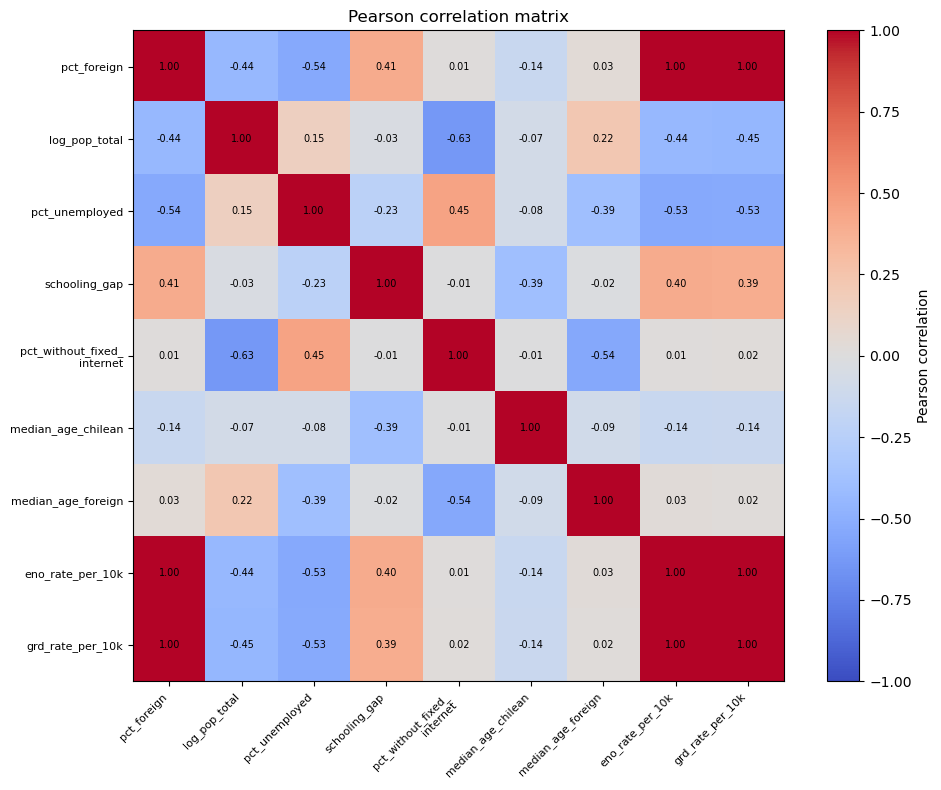

,variable_1,variable_2,correlation,abs_correlation
0,pct_foreign,eno_rate_per_10k,0.999929,0.999929
1,eno_rate_per_10k,grd_rate_per_10k,0.999530,0.999530
2,pct_foreign,grd_rate_per_10k,0.999446,0.999446


In [180]:
# Seleccionar variables para la matriz
vars_corr = [
    "pct_foreign",
    "log_pop_total",
    "pct_unemployed",
    "schooling_gap",
    "pct_without_fixed_internet",
    "median_age_chilean",
    "median_age_foreign",
    "eno_rate_per_10k",
    "grd_rate_per_10k"
]

# Preparar datos
corr_data = analytical_table_derived[vars_corr].copy()

for col in vars_corr:
    corr_data[col] = pd.to_numeric(corr_data[col], errors="coerce")

# Calcular matriz de correlación
corr_matrix = corr_data.corr(method="pearson")

display(corr_matrix.round(3))

# Crear heatmap
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    corr_matrix,
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)

labels = [
    "\n".join(textwrap.wrap(col, width=18))
    for col in vars_corr
]

ax.set_xticks(np.arange(len(vars_corr)))
ax.set_yticks(np.arange(len(vars_corr)))

ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(labels, fontsize=8)

for i in range(len(vars_corr)):
    for j in range(len(vars_corr)):
        value = corr_matrix.iloc[i, j]
        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=7
        )

ax.set_title("Pearson correlation matrix")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Pearson correlation")

plt.tight_layout()
plt.show()

# Obtener las tres correlaciones más fuertes
corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["variable_1", "variable_2", "correlation"]
corr_pairs["abs_correlation"] = corr_pairs["correlation"].abs()

top3_corr = (
    corr_pairs
    .sort_values("abs_correlation", ascending=False)
    .head(3)
    .reset_index(drop=True)
)

display(top3_corr.round(6))

### 1.2 Bivariate scatter plots

Para los gráficos bivariados se usaron las mismas covariables seleccionadas en la matriz de correlación, con el fin de mantener consistencia entre ambas partes del análisis exploratorio. Se incluyeron variables de composición migrante, tamaño poblacional, empleo, educación, acceso a internet fija y edad mediana. En cada gráfico se agregó una línea OLS simple y se etiquetaron las cinco comunas con residuos más extremos para identificar los casos que más se alejan de la tendencia general.

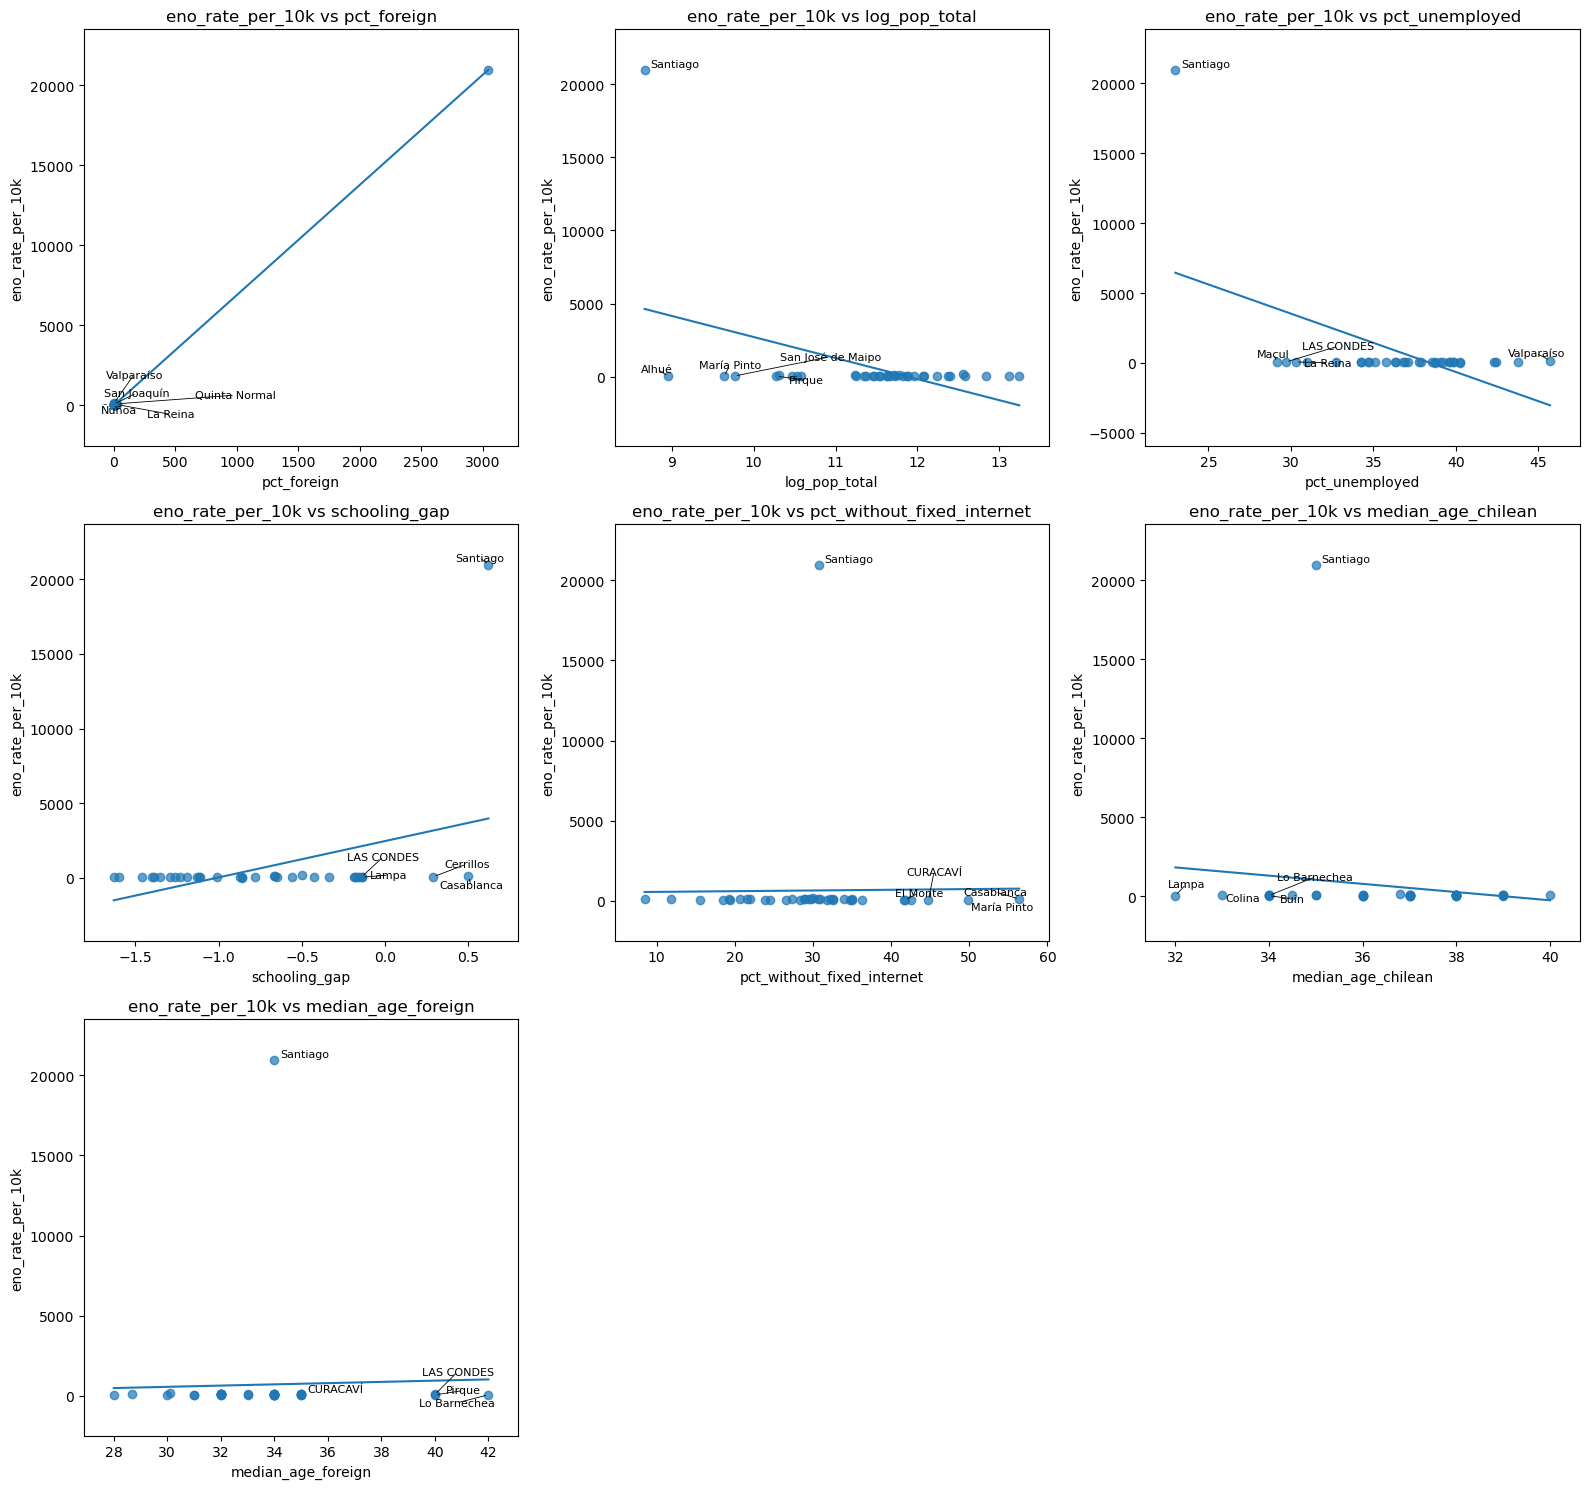

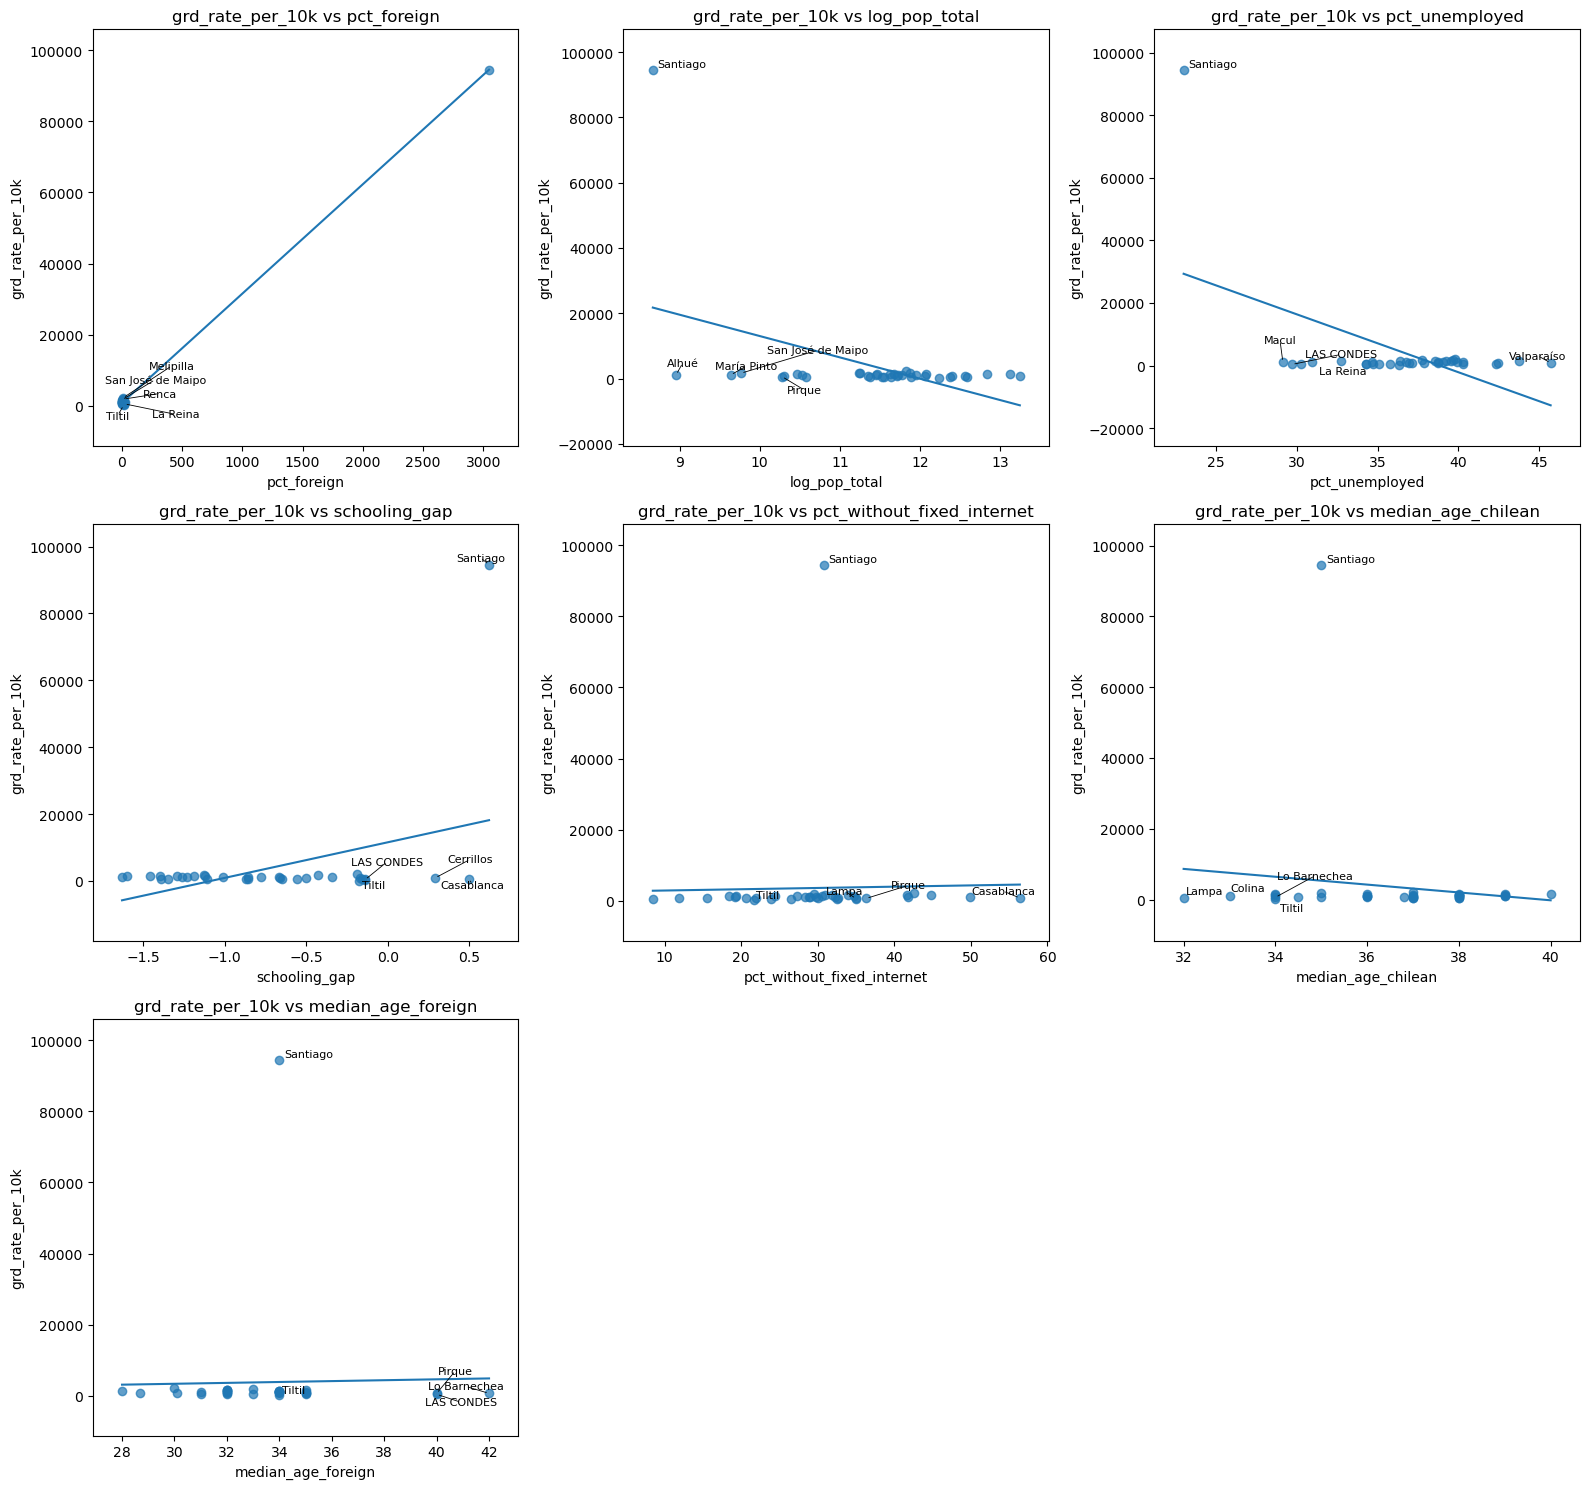

In [183]:
warnings.filterwarnings("ignore")

covariates = [
    "pct_foreign",
    "log_pop_total",
    "pct_unemployed",
    "schooling_gap",
    "pct_without_fixed_internet",
    "median_age_chilean",
    "median_age_foreign"
]

outcomes = [
    "eno_rate_per_10k",
    "grd_rate_per_10k"
]

def plot_bivariate_grid(data, outcome, covariates, comuna_col="nombre_comuna"):
    n_cols = 3
    n_rows = int(np.ceil(len(covariates) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    axes = axes.flatten()

    for i, covariate in enumerate(covariates):
        ax = axes[i]

        plot_data = data[[covariate, outcome, comuna_col]].copy()
        plot_data[covariate] = pd.to_numeric(plot_data[covariate], errors="coerce")
        plot_data[outcome] = pd.to_numeric(plot_data[outcome], errors="coerce")
        plot_data = plot_data.dropna()

        x = plot_data[covariate].values
        y = plot_data[outcome].values

        ax.scatter(x, y, alpha=0.7)

        texts = []

        if len(plot_data) >= 2:
            slope, intercept = np.polyfit(x, y, 1)
            x_line = np.linspace(x.min(), x.max(), 100)
            y_line = slope * x_line + intercept

            ax.plot(x_line, y_line)

            plot_data["prediction"] = slope * plot_data[covariate] + intercept
            plot_data["residual"] = plot_data[outcome] - plot_data["prediction"]
            plot_data["abs_residual"] = plot_data["residual"].abs()

            extreme_points = plot_data.nlargest(5, "abs_residual")

            for _, row in extreme_points.iterrows():
                texts.append(
                    ax.text(
                        row[covariate],
                        row[outcome],
                        str(row[comuna_col]),
                        fontsize=8
                    )
                )

            adjust_text(
                texts,
                ax=ax,
                expand_points=(1.3, 1.5),
                expand_text=(1.2, 1.4),
                force_points=0.5,
                force_text=0.8,
                arrowprops=dict(
                    arrowstyle="-",
                    lw=0.6
                )
            )

        ax.margins(x=0.08, y=0.12)
        ax.set_title(f"{outcome} vs {covariate}")
        ax.set_xlabel(covariate)
        ax.set_ylabel(outcome)

    for j in range(len(covariates), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

for outcome in outcomes:
    plot_bivariate_grid(
        data=analytical_table_derived,
        outcome=outcome,
        covariates=covariates
    )

Al llegar a este punto, identificamos que el grupo 4, encargado de la comuna de Santiago, cometió un error importante en la variable `pct_foreign`. Al ser un porcentaje, esta variable debería estar expresada en una escala de 0 a 100, pero en su archivo aparece con un valor cercano a 3000, lo que no es coherente con el formato esperado.

Debido a que este error afecta directamente los análisis exploratorios y podría distorsionar las correlaciones y gráficos bivariados, decidimos excluir los archivos correspondientes a este grupo. Esta decisión se tomó para mantener la consistencia e integridad de la base final. A partir de esta corrección, se vuelven a ejecutar los pasos 1.1 y 1.2.

### CORRECCIÓN: 1.1 Correlation matrix

Luego de detectar el error en `pct_foreign` para la comuna de Santiago, se decidió crear una nueva versión de la base analítica excluyendo únicamente esa comuna. Esta corrección busca evitar que un valor mal registrado distorsione los análisis exploratorios posteriores, especialmente la matriz de correlación y los gráficos bivariados.

In [187]:
# Copiar base más reciente
analytical_table_derived_no_santiago = analytical_table_derived.copy()

# Estandarizar nombre y código
analytical_table_derived_no_santiago["nombre_comuna_std"] = (
    analytical_table_derived_no_santiago["nombre_comuna"]
    .astype(str)
    .str.strip()
    .str.lower()
)

analytical_table_derived_no_santiago["codigo_comuna"] = (
    analytical_table_derived_no_santiago["codigo_comuna"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

# Eliminar Santiago
analytical_table_derived_no_santiago = analytical_table_derived_no_santiago[
    (analytical_table_derived_no_santiago["nombre_comuna_std"] != "santiago") &
    (analytical_table_derived_no_santiago["codigo_comuna"] != "13101")
].copy()

# Quitar columna auxiliar
analytical_table_derived_no_santiago = analytical_table_derived_no_santiago.drop(
    columns=["nombre_comuna_std"],
    errors="ignore"
)

# Revisar resultado
print("Filas antes:", len(analytical_table_derived))
print("Filas después:", len(analytical_table_derived_no_santiago))

display(
    analytical_table_derived_no_santiago[
        ["codigo_comuna", "nombre_comuna"]
    ].sort_values("codigo_comuna")
)

# Guardar nueva base
analytical_table_derived_no_santiago.to_csv(
    "output/analytical_table_derived_no_santiago.csv",
    index=False,
    encoding="utf-8-sig"
)

Filas antes: 37
Filas después: 36


,codigo_comuna,nombre_comuna
3,13102,Cerrillos
4,13104,Conchalí
5,13105,Estación Central
6,13107,Huechuraba
7,13109,La Reina
8,13110,La Florida
9,13111,La Granja
10,13112,La Pintana
11,13114,LAS CONDES
12,13115,Lo Barnechea


Ahora frente a los múltiples errores que han tenido otros grupos decidimos directamente crear una base definitiva eliminando las comunas que tengan valores faltantes en las variables clave del análisis. Antes de filtrar, se identifica qué comunas se eliminan y en qué columnas tienen datos faltantes, para que la limpieza quede documentada.

In [189]:
analytical_table_final = analytical_table_derived_no_santiago.copy()

required_numeric_cols = [
    "pop_total",
    "pct_foreign",
    "log_pop_total",
    "pct_unemployed",
    "schooling_gap",
    "pct_without_fixed_internet",
    "median_age_chilean",
    "median_age_foreign",
    "eno_total",
    "eno_rate_per_10k",
    "grd_total",
    "grd_rate_per_10k",
    "grd_mean_los"
]

required_id_cols = [
    "codigo_comuna",
    "nombre_comuna"
]

required_cols = required_id_cols + required_numeric_cols

missing_required_cols = [
    col for col in required_cols
    if col not in analytical_table_final.columns
]

if len(missing_required_cols) > 0:
    raise ValueError(f"Faltan columnas requeridas en la base: {missing_required_cols}")

for col in required_numeric_cols:
    analytical_table_final[col] = pd.to_numeric(
        analytical_table_final[col],
        errors="coerce"
    )

analytical_table_final["codigo_comuna"] = (
    analytical_table_final["codigo_comuna"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

analytical_table_final["nombre_comuna"] = (
    analytical_table_final["nombre_comuna"]
    .astype(str)
    .str.strip()
)

missing_mask = analytical_table_final[required_cols].isna()

analytical_table_final["missing_variables"] = missing_mask.apply(
    lambda row: ", ".join(row.index[row]),
    axis=1
)

excluded_missing = analytical_table_final[
    analytical_table_final["missing_variables"] != ""
].copy()

analytical_table_final = analytical_table_final[
    analytical_table_final["missing_variables"] == ""
].copy()

analytical_table_final = analytical_table_final.drop(
    columns=["missing_variables"],
    errors="ignore"
)

summary_final_base = pd.DataFrame({
    "metric": [
        "Rows before filtering",
        "Rows removed because of missing values",
        "Rows in final base"
    ],
    "value": [
        len(analytical_table_derived_no_santiago),
        len(excluded_missing),
        len(analytical_table_final)
    ]
})

print("Resumen de la limpieza")
display(summary_final_base)

print("Comunas eliminadas por valores faltantes")
display(
    excluded_missing[
        [
            "codigo_comuna",
            "nombre_comuna",
            "missing_variables"
        ]
    ].sort_values("nombre_comuna")
)

print("Base definitiva")
display(
    analytical_table_final[
        [
            "codigo_comuna",
            "nombre_comuna",
            "pop_total",
            "pct_foreign",
            "pct_unemployed",
            "schooling_gap",
            "pct_without_fixed_internet",
            "eno_rate_per_10k",
            "grd_rate_per_10k",
            "grd_mean_los"
        ]
    ].sort_values("nombre_comuna")
)

Path("output").mkdir(exist_ok=True)

analytical_table_final.to_csv(
    "output/analytical_table_final.csv",
    index=False,
    encoding="utf-8-sig"
)

Resumen de la limpieza


,metric,value
0,Rows before filtering,36
1,Rows removed because of missing values,3
2,Rows in final base,33


Comunas eliminadas por valores faltantes


,codigo_comuna,nombre_comuna,missing_variables
21,13129,San Joaquín,"pct_unemployed, schooling_gap, median_age_foreign"
25,13203,San José de Maipo,"pct_unemployed, schooling_gap, median_age_foreign"
16,13120,Ñuñoa,"pct_unemployed, schooling_gap, median_age_foreign"


Base definitiva


,codigo_comuna,nombre_comuna,pop_total,pct_foreign,pct_unemployed,schooling_gap,pct_without_fixed_internet,eno_rate_per_10k,grd_rate_per_10k,grd_mean_los
30,13502,Alhué,7768,11.340000,34.66,-0.78,34.69,36.045314,1158.600000,5.640000
28,13402,Buin,116969,5.095367,36.37,-1.19,24.48,47.110000,1321.461242,5.576291
31,13503,CURACAVÍ,34977,4.174172,39.21,-1.60,44.78,47.173900,1483.290000,6.490000
1,5102,Casablanca,29876,7.590000,42.43,0.50,56.39,104.430000,714.290000,4.800000
3,13102,Cerrillos,85041,15.000000,37.88,0.29,32.24,75.490000,896.390000,7.390000
26,13301,Colina,173293,13.090000,38.73,-0.17,32.58,72.650000,850.700000,5.880000
4,13104,Conchalí,121587,14.545963,36.93,-0.66,29.78,93.266550,868.596149,6.366632
34,13602,El Monte,37497,2.450000,39.04,-1.63,41.82,38.936448,1097.200000,5.950000
5,13105,Estación Central,155257,7.300000,40.25,-1.23,28.81,78.060000,1123.690000,6.530000
6,13107,Huechuraba,101808,8.280000,35.10,-1.35,21.92,81.722458,606.000000,6.090000


Luego de limpiar la base, se pasó de 36 a 33 comunas. Se eliminaron San Joaquín, San José de Maipo y Ñuñoa porque tenían valores faltantes en variables clave del análisis, específicamente `pct_unemployed`, `schooling_gap` y `median_age_foreign`. Esta será la base definitiva para los siguientes modelos.

---

Recalculamos la matriz de correlación usando la base corregida, donde se excluyó Santiago por el error detectado en `pct_foreign`. Con esto buscamos que las asociaciones entre variables no queden distorsionadas por ese registro y que las tres correlaciones más fuertes reflejen mejor el comportamiento del resto de las comunas.

,pct_foreign,log_pop_total,pct_unemployed,schooling_gap,pct_without_fixed_internet,median_age_chilean,median_age_foreign,eno_rate_per_10k,grd_rate_per_10k
pct_foreign,1.000,0.196,-0.588,0.370,-0.293,0.044,-0.007,0.287,-0.184
log_pop_total,0.196,1.000,-0.131,0.192,-0.677,-0.099,0.270,0.446,-0.071
pct_unemployed,-0.588,-0.131,1.000,-0.023,0.541,-0.179,-0.441,0.245,0.271
schooling_gap,0.370,0.192,-0.023,1.000,-0.012,-0.369,-0.036,0.216,-0.307
pct_without_fixed_internet,-0.293,-0.677,0.541,-0.012,1.000,-0.033,-0.545,-0.123,0.290
median_age_chilean,0.044,-0.099,-0.179,-0.369,-0.033,1.000,-0.086,0.091,0.209
median_age_foreign,-0.007,0.270,-0.441,-0.036,-0.545,-0.086,1.000,-0.176,-0.353
eno_rate_per_10k,0.287,0.446,0.245,0.216,-0.123,0.091,-0.176,1.000,-0.087
grd_rate_per_10k,-0.184,-0.071,0.271,-0.307,0.290,0.209,-0.353,-0.087,1.000


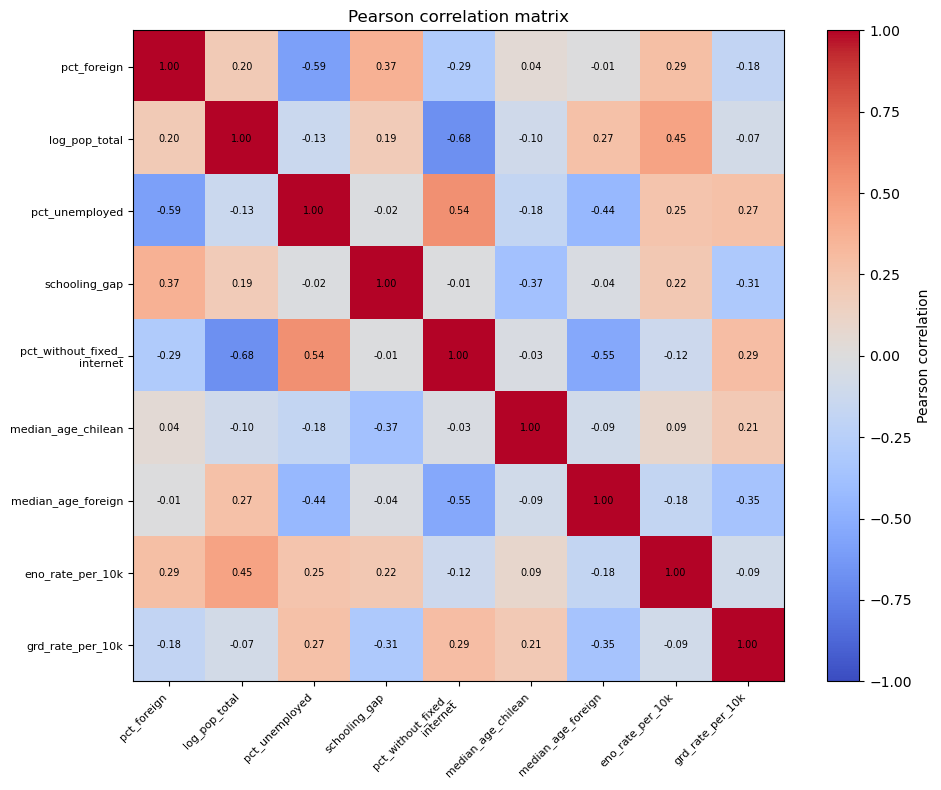

,variable_1,variable_2,correlation,abs_correlation
0,log_pop_total,pct_without_fixed_internet,-0.68,0.68
1,pct_foreign,pct_unemployed,-0.59,0.59
2,pct_without_fixed_internet,median_age_foreign,-0.55,0.55


In [192]:
# Variables para la matriz
vars_corr = [
    "pct_foreign",
    "log_pop_total",
    "pct_unemployed",
    "schooling_gap",
    "pct_without_fixed_internet",
    "median_age_chilean",
    "median_age_foreign",
    "eno_rate_per_10k",
    "grd_rate_per_10k"
]

# Usar base definitiva
corr_data = analytical_table_final[vars_corr].copy()

# Pasar variables a número
for col in vars_corr:
    corr_data[col] = pd.to_numeric(corr_data[col], errors="coerce")

# Calcular matriz de correlación
corr_matrix = corr_data.corr(method="pearson")

display(corr_matrix.round(3))

# Crear heatmap
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    corr_matrix,
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)

labels = [
    "\n".join(textwrap.wrap(col, width=18))
    for col in vars_corr
]

ax.set_xticks(np.arange(len(vars_corr)))
ax.set_yticks(np.arange(len(vars_corr)))

ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(labels, fontsize=8)

for i in range(len(vars_corr)):
    for j in range(len(vars_corr)):
        value = corr_matrix.iloc[i, j]
        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=7
        )

ax.set_title("Pearson correlation matrix")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Pearson correlation")

plt.tight_layout()
plt.show()

# Obtener correlaciones más fuertes
corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["variable_1", "variable_2", "correlation"]
corr_pairs["abs_correlation"] = corr_pairs["correlation"].abs()

top3_corr = (
    corr_pairs
    .sort_values("abs_correlation", ascending=False)
    .head(3)
    .reset_index(drop=True)
)

display(top3_corr.round(2))

Las tres correlaciones más fuertes cambiaron bastante después de excluir Santiago. La más alta fue entre `log_pop_total` y `pct_without_fixed_internet`, con una correlación negativa de -0,68. Este signo sí tiene sentido, porque las comunas con mayor población tienden a ser más urbanas y, por lo mismo, suelen tener mejor acceso a internet fija. En cambio, comunas más pequeñas o rurales pueden presentar mayor porcentaje de hogares sin este servicio.

La segunda correlación más fuerte fue entre `pct_foreign` y `pct_unemployed`, con un valor de -0,59. El signo negativo indica que, en esta base, las comunas con mayor porcentaje de población extranjera tienden a mostrar menor porcentaje aproximado de no empleo. Esto también puede tener sentido, ya que parte de la población migrante puede concentrarse en comunas con mayor actividad laboral o mejores oportunidades de empleo.

La tercera correlación fue entre `pct_without_fixed_internet` y `median_age_foreign`, con un valor de -0,55. Esto muestra que las comunas con mayor falta de internet fija tienden a tener una menor edad mediana de la población extranjera. El signo es razonable si se piensa que en esas comunas la población extranjera puede ser más joven o estar compuesta por hogares en etapas más activas laboralmente.

### CORRECCIÓN: 1.2 Bivariate scatter plots

Ahora se rehacen los gráficos bivariados usando la base corregida sin Santiago. Se mantienen las mismas covariables usadas en la matriz de correlación para que el análisis sea consistente. En cada gráfico se agrega una línea OLS simple y se etiquetan las cinco comunas que más se alejan de esa tendencia.

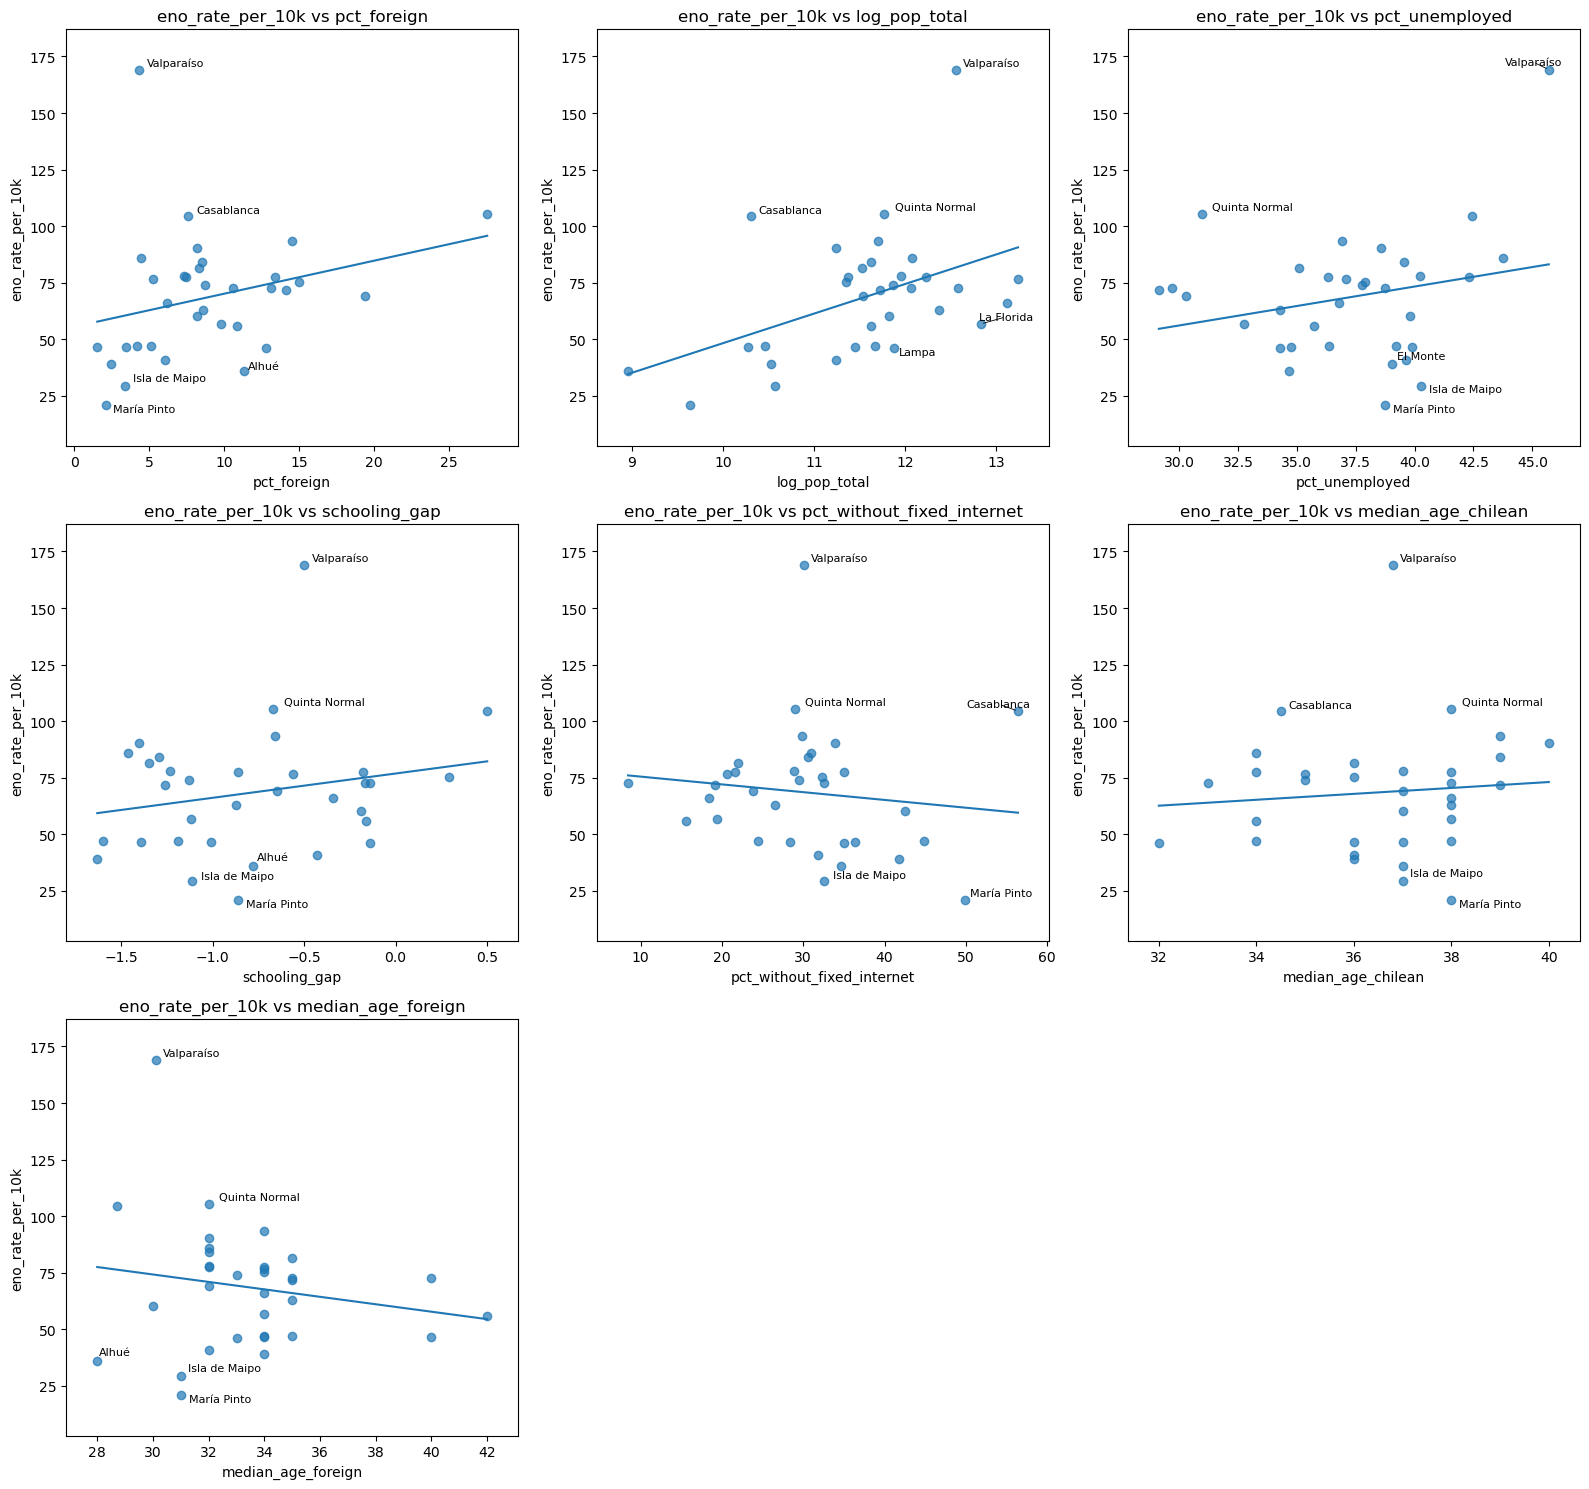

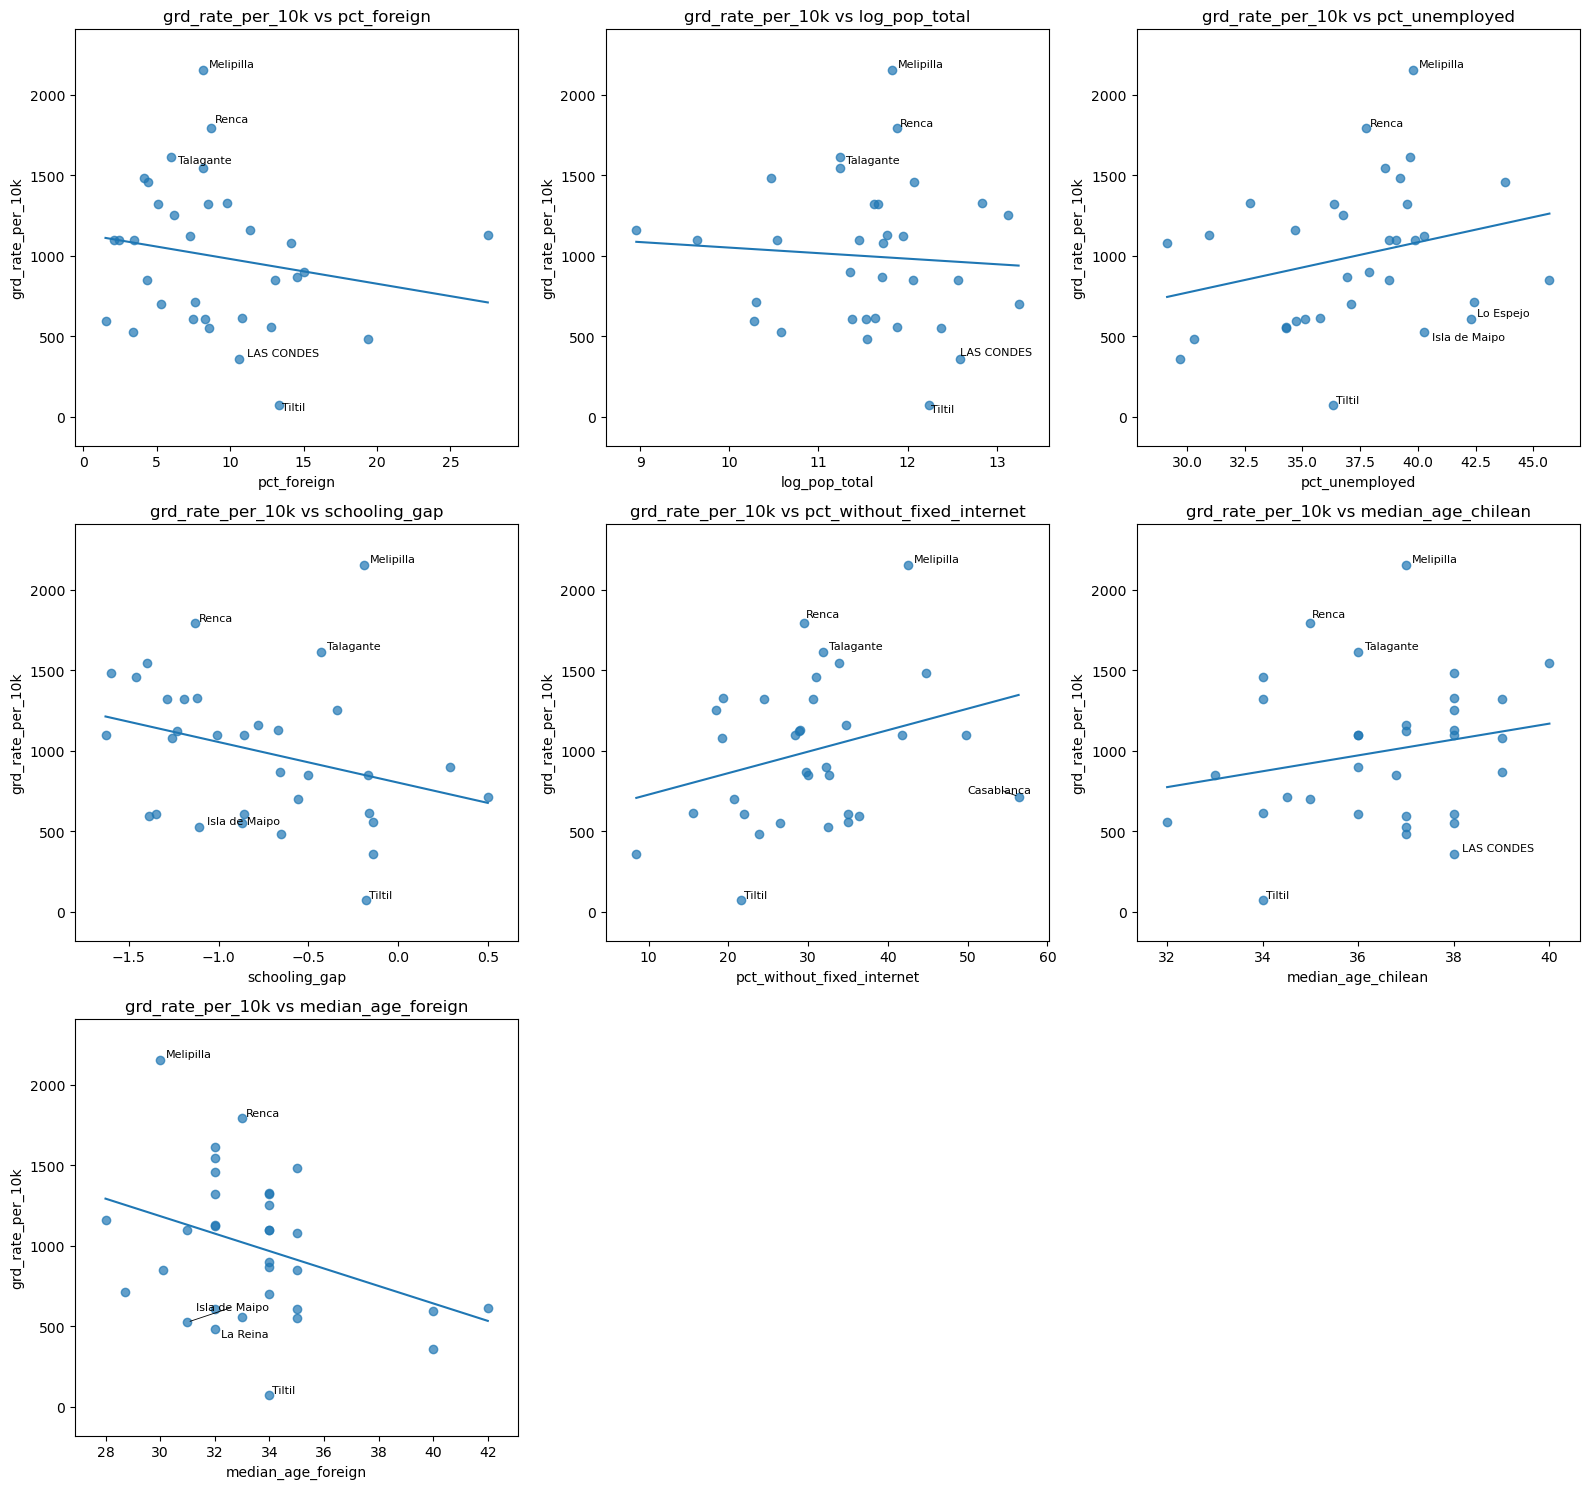

In [196]:
covariates = [
    "pct_foreign",
    "log_pop_total",
    "pct_unemployed",
    "schooling_gap",
    "pct_without_fixed_internet",
    "median_age_chilean",
    "median_age_foreign"
]

outcomes = [
    "eno_rate_per_10k",
    "grd_rate_per_10k"
]

def plot_bivariate_grid(data, outcome, covariates, comuna_col="nombre_comuna"):
    n_cols = 3
    n_rows = int(np.ceil(len(covariates) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    axes = axes.flatten()

    for i, covariate in enumerate(covariates):
        ax = axes[i]

        plot_data = data[[covariate, outcome, comuna_col]].copy()

        plot_data[covariate] = pd.to_numeric(
            plot_data[covariate],
            errors="coerce"
        )

        plot_data[outcome] = pd.to_numeric(
            plot_data[outcome],
            errors="coerce"
        )

        plot_data = plot_data.dropna()

        x = plot_data[covariate].values
        y = plot_data[outcome].values

        ax.scatter(x, y, alpha=0.7)

        texts = []

        if len(plot_data) >= 2:
            slope, intercept = np.polyfit(x, y, 1)
            x_line = np.linspace(x.min(), x.max(), 100)
            y_line = slope * x_line + intercept

            ax.plot(x_line, y_line)

            plot_data["prediction"] = slope * plot_data[covariate] + intercept
            plot_data["residual"] = plot_data[outcome] - plot_data["prediction"]
            plot_data["abs_residual"] = plot_data["residual"].abs()

            extreme_points = plot_data.nlargest(5, "abs_residual")

            for _, row in extreme_points.iterrows():
                texts.append(
                    ax.text(
                        row[covariate],
                        row[outcome],
                        str(row[comuna_col]),
                        fontsize=8
                    )
                )

            adjust_text(
                texts,
                ax=ax,
                expand_points=(1.3, 1.5),
                expand_text=(1.2, 1.4),
                force_points=0.5,
                force_text=0.8,
                arrowprops=dict(
                    arrowstyle="-",
                    lw=0.6
                )
            )

        ax.margins(x=0.08, y=0.12)
        ax.set_title(f"{outcome} vs {covariate}")
        ax.set_xlabel(covariate)
        ax.set_ylabel(outcome)

    for j in range(len(covariates), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

for outcome in outcomes:
    plot_bivariate_grid(
        data=analytical_table_final,
        outcome=outcome,
        covariates=covariates
    )

En los gráficos de `eno_rate_per_10k`, las comunas que más aparecen etiquetadas son Valparaíso, Casablanca, Quinta Normal, María Pinto, Isla de Maipo y Alhué. Las pendientes son positivas para `pct_foreign`, `log_pop_total`, `pct_unemployed`, `schooling_gap` y `median_age_chilean`, mientras que son negativas para `pct_without_fixed_internet` y `median_age_foreign`.

En los gráficos de `grd_rate_per_10k`, las comunas que más se repiten entre los puntos extremos son Melipilla, Renca, Tiltil, Las Condes e Isla de Maipo. Las pendientes son negativas para `pct_foreign`, `log_pop_total`, `schooling_gap` y `median_age_foreign`, y positivas para `pct_unemployed`, `pct_without_fixed_internet` y `median_age_chilean`.

### 1.3 Outlier and leverage discussion

**Valparaíso:** Aparece como un outlier visual en varios gráficos de `eno_rate_per_10k`, ya que presenta una tasa ENO bastante más alta que la mayoría de las comunas. Una explicación posible es que, al ser una comuna grande, con alta movilidad, actividad portuaria y mayor concentración de servicios, puede registrar más notificaciones o tener mayor detección de casos que comunas más pequeñas. Además, muchas personas de otras comunas pueden ir a Valparaíso por trabajo, estudios, turismo, trámites o atención de salud, lo que podría aumentar los registros sanitarios sin que eso quede completamente reflejado en las covariables que usamos.

**Melipilla:** Destaca como outlier en varios gráficos de `grd_rate_per_10k`, especialmente porque muestra tasas GRD elevadas respecto al resto. Esto podría explicarse porque su hospital atiende no solo a población de la comuna, sino también a personas provenientes de comunas cercanas o zonas rurales alrededor. Por eso, sus egresos hospitalarios pueden verse más altos que lo esperado si solo se consideran las características comunales disponibles en la base.

## Part 2: Count-Data Regression

### 2.1 Poisson regression

En esta sección se ajusta una regresión Poisson para explicar `eno_total`, que corresponde al número de notificaciones ENO por comuna. Como las comunas tienen distintos tamaños de población, se usa `log(pop_total)` como offset, de manera que el modelo compare tasas ajustadas por población y no solo conteos brutos.

Las covariables usadas son `pct_foreign`, `schooling_gap`, `pct_unemployed` y `pct_without_fixed_internet`. Se eligieron porque cubren dimensiones distintas del contexto comunal: composición migrante, educación, empleo y acceso a servicioa.

In [203]:
model_data = analytical_table_final.copy()

outcome = "eno_total"

covariates = [
    "pct_foreign",
    "schooling_gap",
    "pct_unemployed",
    "pct_without_fixed_internet"
]

model_cols = [
    outcome,
    "pop_total"
] + covariates

poisson_data = model_data[model_cols].copy()

# Pasar variables a número
for col in model_cols:
    poisson_data[col] = pd.to_numeric(
        poisson_data[col],
        errors="coerce"
    )

# Mantener filas válidas
poisson_data = poisson_data.dropna()
poisson_data = poisson_data[poisson_data["pop_total"] > 0].copy()

# Definir modelo
y = poisson_data[outcome]
X = sm.add_constant(poisson_data[covariates])
offset = np.log(poisson_data["pop_total"])

poisson_model = sm.GLM(
    y,
    X,
    family=sm.families.Poisson(),
    offset=offset
)

poisson_results = poisson_model.fit()

# Tabla de coeficientes
coef_table = pd.DataFrame({
    "coef": poisson_results.params,
    "std_error": poisson_results.bse,
    "z_value": poisson_results.tvalues,
    "p_value": poisson_results.pvalues
})

conf = poisson_results.conf_int()
conf.columns = ["coef_ci_low", "coef_ci_high"]

coef_table = pd.concat([coef_table, conf], axis=1)

# Calcular IRR
coef_table["IRR"] = np.exp(coef_table["coef"])
coef_table["IRR_ci_low"] = np.exp(coef_table["coef_ci_low"])
coef_table["IRR_ci_high"] = np.exp(coef_table["coef_ci_high"])

coef_table = coef_table.round(4)

# Ajuste del modelo
model_fit = pd.DataFrame({
    "metric": [
        "Deviance",
        "Pearson chi-square",
        "AIC",
        "Number of observations"
    ],
    "value": [
        poisson_results.deviance,
        poisson_results.pearson_chi2,
        poisson_results.aic,
        poisson_results.nobs
    ]
})

model_fit["value"] = model_fit["value"].round(4)

# Revisar covariables usadas
covariate_roles = pd.DataFrame({
    "role": [
        "Migration composition",
        "Education measure",
        "Employment measure",
        "Housing/service measure"
    ],
    "variable": covariates
})

print(poisson_results.summary())

print("Covariates used")
display(covariate_roles)

print("Coefficient table with IRR")
display(coef_table)

print("Model fit")
display(model_fit)

                 Generalized Linear Model Regression Results                  
Dep. Variable:              eno_total   No. Observations:                   33
Model:                            GLM   Df Residuals:                       28
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -993.88
Date:                Sun, 03 May 2026   Deviance:                       1712.8
Time:                        22:20:03   Pearson chi2:                 1.72e+03
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

,role,variable
0,Migration composition,pct_foreign
1,Education measure,schooling_gap
2,Employment measure,pct_unemployed
3,Housing/service measure,pct_without_fixed_internet


Coefficient table with IRR


,coef,std_error,z_value,p_value,coef_ci_low,coef_ci_high,IRR,IRR_ci_low,IRR_ci_high
const,-8.5290,0.0778,-109.5580,0.0000,-8.6816,-8.3764,0.0002,0.0002,0.0002
pct_foreign,0.0507,0.0016,32.2144,0.0000,0.0476,0.0538,1.0520,1.0488,1.0552
schooling_gap,-0.0338,0.0122,-2.7678,0.0056,-0.0578,-0.0099,0.9667,0.9438,0.9902
pct_unemployed,0.1031,0.0022,47.6746,0.0000,0.0989,0.1073,1.1086,1.1039,1.1133
pct_without_fixed_internet,-0.0261,0.0010,-25.8920,0.0000,-0.0280,-0.0241,0.9743,0.9723,0.9762


Model fit


,metric,value
0,Deviance,1712.7837
1,Pearson chi-square,1720.5992
2,AIC,1997.7520
3,Number of observations,33.0000


El modelo Poisson se estimó con 33 observaciones y cuatro covariables. Todas las variables incluidas presentan p-values menores a 0,01. En la tabla de IRR, `pct_foreign` tiene un IRR de 1,0520, `schooling_gap` de 0,9667, `pct_unemployed` de 1,1086 y `pct_without_fixed_internet` de 0,9743.

Respecto al ajuste del modelo, la deviance fue 1712,7837, el Pearson chi-square fue 1720,5992 y el AIC fue 1997,7520.

### 2.2 Check for overdispersion

Revisamos si el modelo Poisson presenta sobredispersión. Para esto se calcula la razón entre el Pearson chi-square y los grados de libertad residuales. Si este valor es bastante mayor que 1, significa que la variabilidad observada es mayor a la que asume el modelo Poisson.

In [207]:
# Calcular estadístico de dispersión
dispersion_value = poisson_results.pearson_chi2 / poisson_results.df_resid

dispersion_table = pd.DataFrame({
    "metric": [
        "Pearson chi-square",
        "Residual degrees of freedom",
        "Dispersion statistic"
    ],
    "value": [
        poisson_results.pearson_chi2,
        poisson_results.df_resid,
        dispersion_value
    ]
})

dispersion_table["value"] = dispersion_table["value"].round(4)

display(dispersion_table)

,metric,value
0,Pearson chi-square,1720.5992
1,Residual degrees of freedom,28.0000
2,Dispersion statistic,61.4500


El estadístico de dispersión fue 61,45, calculado como el Pearson chi-square dividido por los grados de libertad residuales. Como este valor es mucho mayor que 1, el modelo Poisson presenta sobredispersión.

Esto implica que la varianza observada en `eno_total` es mayor a la que asume el modelo Poisson. Por lo mismo, los errores estándar del modelo Poisson pueden quedar subestimados y conviene probar un modelo Negative Binomial para manejar mejor esa variabilidad.

### 2.3 Negative Binomial regression

Estimamos el mismo modelo de conteo, pero usando Negative Binomial. La idea es comparar sus coeficientes y p-values con los del modelo Poisson, ya que en el paso anterior se detectó sobredispersión. Si los errores estándar o la significancia cambian de forma importante, el modelo Negative Binomial sería una mejor opción para reportar.

In [211]:
model_data = analytical_table_final.copy()

outcome = "eno_total"

covariates = [
    "pct_foreign",
    "schooling_gap",
    "pct_unemployed",
    "pct_without_fixed_internet"
]

model_cols = [
    outcome,
    "pop_total"
] + covariates

count_data = model_data[model_cols].copy()

# Pasar variables a número
for col in model_cols:
    count_data[col] = pd.to_numeric(
        count_data[col],
        errors="coerce"
    )

# Mantener filas válidas
count_data = count_data.dropna()
count_data = count_data[count_data["pop_total"] > 0].copy()

# Definir datos del modelo
y = count_data[outcome]
X = sm.add_constant(count_data[covariates])
offset = np.log(count_data["pop_total"])

# Ajustar Poisson
poisson_model = sm.GLM(
    y,
    X,
    family=sm.families.Poisson(),
    offset=offset
)

poisson_results = poisson_model.fit()

# Ajustar Negative Binomial
nb_model = sm.NegativeBinomial(
    y,
    X,
    offset=offset
)

nb_results = nb_model.fit(
    disp=False,
    maxiter=1000
)

# Calcular dispersión Poisson
dispersion_value = poisson_results.pearson_chi2 / poisson_results.df_resid

# Crear tabla Poisson
poisson_side = pd.DataFrame({
    "variable": poisson_results.params.index,
    "poisson_coef": poisson_results.params.values,
    "poisson_std_error": poisson_results.bse.values,
    "poisson_p_value": poisson_results.pvalues.values
})

# Crear tabla Negative Binomial
nb_side = pd.DataFrame({
    "variable": nb_results.params.index,
    "nb_coef": nb_results.params.values,
    "nb_std_error": nb_results.bse.values,
    "nb_p_value": nb_results.pvalues.values
})

# Unir resultados
coef_side_by_side = poisson_side.merge(
    nb_side,
    on="variable",
    how="left"
)

coef_side_by_side = coef_side_by_side[
    coef_side_by_side["variable"] != "alpha"
].copy()

# Marcar significancia
coef_side_by_side["poisson_significant_5pct"] = (
    coef_side_by_side["poisson_p_value"] < 0.05
)

coef_side_by_side["nb_significant_5pct"] = (
    coef_side_by_side["nb_p_value"] < 0.05
)

coef_side_by_side["significance_changed"] = (
    coef_side_by_side["poisson_significant_5pct"] !=
    coef_side_by_side["nb_significant_5pct"]
)

coef_side_by_side = coef_side_by_side.round(4)

# Filtrar cambios de significancia
pvalue_changes = coef_side_by_side[
    coef_side_by_side["significance_changed"]
].copy()

# Comparar ajuste
model_comparison = pd.DataFrame({
    "model": [
        "Poisson",
        "Negative Binomial"
    ],
    "AIC": [
        poisson_results.aic,
        nb_results.aic
    ],
    "log_likelihood": [
        poisson_results.llf,
        nb_results.llf
    ],
    "n_observations": [
        poisson_results.nobs,
        nb_results.nobs
    ],
    "dispersion": [
        dispersion_value,
        np.nan
    ],
    "alpha": [
        np.nan,
        nb_results.params.get("alpha", np.nan)
    ]
})

model_comparison = model_comparison.round(4)

# Guardar modelo recomendado para usar después
recommended_model = "Negative Binomial"
selected_count_model = nb_results
selected_count_model_name = "Negative Binomial"

print("Coefficient table side by side")
display(coef_side_by_side)

print("P-value changes")
display(pvalue_changes)

print("Model comparison")
display(model_comparison)

Coefficient table side by side


,variable,poisson_coef,poisson_std_error,poisson_p_value,nb_coef,nb_std_error,nb_p_value,poisson_significant_5pct,nb_significant_5pct,significance_changed
0,const,-8.5290,0.0778,0.0000,-7.9424,0.6672,0.0000,True,True,False
1,pct_foreign,0.0507,0.0016,0.0000,0.0503,0.0123,0.0000,True,True,False
2,schooling_gap,-0.0338,0.0122,0.0056,0.0041,0.0934,0.9654,True,False,True
3,pct_unemployed,0.1031,0.0022,0.0000,0.0805,0.0170,0.0000,True,True,False
4,pct_without_fixed_internet,-0.0261,0.0010,0.0000,-0.0171,0.0058,0.0032,True,True,False


P-value changes


,variable,poisson_coef,poisson_std_error,poisson_p_value,nb_coef,nb_std_error,nb_p_value,poisson_significant_5pct,nb_significant_5pct,significance_changed
2,schooling_gap,-0.0338,0.0122,0.0056,0.0041,0.0934,0.9654,True,False,True


Model comparison


,model,AIC,log_likelihood,n_observations,dispersion,alpha
0,Poisson,1997.7520,-993.8760,33,61.45,NaN
1,Negative Binomial,451.4318,-219.7159,33,NaN,0.0737


Al comparar Poisson con Negative Binomial, se observa que los coeficientes mantienen una dirección similar en la mayoría de las variables, pero los errores estándar aumentan en el modelo Negative Binomial. Esto era esperable después de detectar sobredispersión en el modelo Poisson.

El cambio más importante aparece en `schooling_gap`. En Poisson esta variable era significativa, con p-value de 0,0056, pero en Negative Binomial deja de serlo, con p-value de 0,9654. Esto sí cambia la conclusión, porque ya no habría evidencia suficiente para sostener que esa variable se asocia con `eno_total` en el modelo principal.

El modelo que reportaría como resultado principal es Negative Binomial. La razón es que el modelo Poisson presentó sobredispersión alta y además Negative Binomial tuvo un AIC mucho menor, pasando de 1997,7520 a 451,4318. Por esto, Negative Binomial representa mejor la variabilidad de los datos y entrega una estimación más adecuada para este caso.

### 2.4 Repeat for GRD

Se repite el modelo de conteo usando `grd_total` como outcome. Se mantienen las mismas covariables usadas para ENO y el mismo offset `log(pop_total)`, para que ambos modelos sean comparables. Primero se ajusta Poisson y se revisa la dispersión; luego se estima Negative Binomial y se reporta la tabla IRR del modelo más adecuado.

In [215]:
model_data = analytical_table_final.copy()

outcome_grd = "grd_total"

covariates = [
    "pct_foreign",
    "schooling_gap",
    "pct_unemployed",
    "pct_without_fixed_internet"
]

model_cols = [
    outcome_grd,
    "pop_total"
] + covariates

grd_data = model_data[model_cols].copy()

# Pasar variables a número
for col in model_cols:
    grd_data[col] = pd.to_numeric(
        grd_data[col],
        errors="coerce"
    )

# Mantener filas válidas
grd_data = grd_data.dropna()
grd_data = grd_data[grd_data["pop_total"] > 0].copy()

# Definir datos del modelo
y_grd = grd_data[outcome_grd]
X_grd = sm.add_constant(grd_data[covariates])
offset_grd = np.log(grd_data["pop_total"])

# Ajustar Poisson
grd_poisson_model = sm.GLM(
    y_grd,
    X_grd,
    family=sm.families.Poisson(),
    offset=offset_grd
)

grd_poisson_results = grd_poisson_model.fit()

# Revisar dispersión
grd_dispersion_value = (
    grd_poisson_results.pearson_chi2 /
    grd_poisson_results.df_resid
)

# Ajustar Negative Binomial
grd_nb_model = sm.NegativeBinomial(
    y_grd,
    X_grd,
    offset=offset_grd
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)

    grd_nb_results = grd_nb_model.fit(
        disp=False,
        maxiter=1000
    )

# Comparar modelos
grd_model_comparison = pd.DataFrame({
    "model": [
        "Poisson",
        "Negative Binomial"
    ],
    "AIC": [
        grd_poisson_results.aic,
        grd_nb_results.aic
    ],
    "log_likelihood": [
        grd_poisson_results.llf,
        grd_nb_results.llf
    ],
    "n_observations": [
        grd_poisson_results.nobs,
        grd_nb_results.nobs
    ],
    "dispersion": [
        grd_dispersion_value,
        np.nan
    ],
    "alpha": [
        np.nan,
        grd_nb_results.params.get("alpha", np.nan)
    ]
})

grd_model_comparison = grd_model_comparison.round(4)

# Elegir modelo según dispersión
if grd_dispersion_value > 1.5:
    grd_selected_results = grd_nb_results
    grd_selected_model_name = "Negative Binomial"
else:
    grd_selected_results = grd_poisson_results
    grd_selected_model_name = "Poisson"

# Construir tabla IRR
grd_irr_table = pd.DataFrame({
    "variable": grd_selected_results.params.index,
    "coef": grd_selected_results.params.values,
    "std_error": grd_selected_results.bse.values,
    "p_value": grd_selected_results.pvalues.values
})

grd_conf = grd_selected_results.conf_int()
grd_irr_table["coef_ci_low"] = grd_conf.iloc[:, 0].values
grd_irr_table["coef_ci_high"] = grd_conf.iloc[:, 1].values

grd_irr_table = grd_irr_table[
    ~grd_irr_table["variable"].isin(["const", "alpha"])
].copy()

grd_irr_table["IRR"] = np.exp(grd_irr_table["coef"])
grd_irr_table["IRR_ci_low"] = np.exp(grd_irr_table["coef_ci_low"])
grd_irr_table["IRR_ci_high"] = np.exp(grd_irr_table["coef_ci_high"])

grd_irr_table["effect_distance_from_1"] = (
    grd_irr_table["IRR"] - 1
).abs()

grd_irr_table = grd_irr_table.round(4)

# Identificar mayor efecto
grd_largest_effect = (
    grd_irr_table
    .sort_values("effect_distance_from_1", ascending=False)
    .head(1)
    .copy()
)

print("GRD model comparison")
display(grd_model_comparison)

print("Selected GRD model")
display(pd.DataFrame({
    "selected_model": [grd_selected_model_name],
    "poisson_dispersion": [round(grd_dispersion_value, 4)]
}))

print("GRD IRR table")
display(
    grd_irr_table[
        [
            "variable",
            "coef",
            "std_error",
            "p_value",
            "IRR",
            "IRR_ci_low",
            "IRR_ci_high"
        ]
    ]
)

print("Largest IRR effect")
display(
    grd_largest_effect[
        [
            "variable",
            "IRR",
            "IRR_ci_low",
            "IRR_ci_high",
            "p_value"
        ]
    ]
)

GRD model comparison


,model,AIC,log_likelihood,n_observations,dispersion,alpha
0,Poisson,85709.6334,-42849.8167,33,2872.8512,NaN
1,Negative Binomial,659.5144,-323.7572,33,NaN,0.2211


Selected GRD model


,selected_model,poisson_dispersion
0,Negative Binomial,2872.8512


GRD IRR table


,variable,coef,std_error,p_value,IRR,IRR_ci_low,IRR_ci_high
1,pct_foreign,0.0123,0.0215,0.5682,1.0124,0.9705,1.0560
2,schooling_gap,-0.3180,0.1677,0.0579,0.7276,0.5238,1.0107
3,pct_unemployed,0.0320,0.0334,0.3388,1.0325,0.9670,1.1024
4,pct_without_fixed_internet,0.0108,0.0105,0.3023,1.0109,0.9903,1.0319


Largest IRR effect


,variable,IRR,IRR_ci_low,IRR_ci_high,p_value
2,schooling_gap,0.7276,0.5238,1.0107,0.0579


Para `grd_total` se eligió el modelo Negative Binomial, ya que el modelo Poisson presentó una dispersión muy alta, con un valor de 2872,8512. Además, el AIC del modelo Negative Binomial fue bastante menor que el de Poisson, pasando de 85709,6334 a 659,5144, por lo que entrega un mejor ajuste para estos datos.

En la tabla IRR, el mayor efecto corresponde a `schooling_gap`, con un IRR de 0,7276. Esto indica que, manteniendo constantes las demás variables, un aumento en la brecha de escolaridad se asocia con una menor tasa esperada de egresos GRD. Sin embargo, su p-value es 0,0579, por lo que queda cerca del nivel de significancia de 5%, pero no alcanza a ser significativo bajo ese criterio.

## Part 3: Continuous-Outcome Regression

### 3.1 Pick an outcome

Para esta parte se escogió `grd_mean_los` como outcome continuo. Esta variable mide la duración promedio de estadía hospitalaria en días, por lo que permite analizar diferencias comunales en la intensidad o complejidad de los egresos hospitalarios. Es una variable interesante porque no solo cuenta cuántos egresos hay, sino que también muestra cuánto tiempo permanecen hospitalizadas las personas en promedio.

In [220]:
# Revisar outcome elegido
continuous_outcome = "grd_mean_los"

analytical_table_final[continuous_outcome].describe()

count    33.000000
mean      5.809752
std       0.709197
min       4.176776
25%       5.380000
50%       5.900000
75%       6.310000
max       7.390000
Name: grd_mean_los, dtype: float64

### 3.2 Linear regression

Ajustamos una regresión lineal OLS usando `grd_mean_los` como outcome continuo. Se usan las mismas covariables de la Parte 2 para mantener consistencia entre los modelos: `pct_foreign`, `schooling_gap`, `pct_unemployed` y `pct_without_fixed_internet`. Al final se reporta la tabla de coeficientes junto con el R² y el R² ajustado.

In [223]:
model_data = analytical_table_final.copy()

continuous_outcome = "grd_mean_los"

covariates = [
    "pct_foreign",
    "schooling_gap",
    "pct_unemployed",
    "pct_without_fixed_internet"
]

model_cols = [
    continuous_outcome
] + covariates

ols_data = model_data[model_cols].copy()

# Pasar variables a número
for col in model_cols:
    ols_data[col] = pd.to_numeric(
        ols_data[col],
        errors="coerce"
    )

# Mantener filas válidas
ols_data = ols_data.dropna().copy()

# Definir modelo
y_ols = ols_data[continuous_outcome]
X_ols = sm.add_constant(ols_data[covariates])

ols_model = sm.OLS(
    y_ols,
    X_ols
)

ols_results = ols_model.fit()

# Tabla de coeficientes
ols_coef_table = pd.DataFrame({
    "coef": ols_results.params,
    "std_error": ols_results.bse,
    "t_value": ols_results.tvalues,
    "p_value": ols_results.pvalues
})

ols_conf = ols_results.conf_int()
ols_conf.columns = ["ci_low", "ci_high"]

ols_coef_table = pd.concat(
    [ols_coef_table, ols_conf],
    axis=1
)

ols_coef_table = ols_coef_table.round(4)

# Métricas del modelo
ols_fit_table = pd.DataFrame({
    "metric": [
        "R-squared",
        "Adjusted R-squared",
        "Number of observations"
    ],
    "value": [
        ols_results.rsquared,
        ols_results.rsquared_adj,
        ols_results.nobs
    ]
})

ols_fit_table["value"] = ols_fit_table["value"].round(4)

print(ols_results.summary())

print("OLS coefficient table")
display(ols_coef_table)

print("OLS model fit")
display(ols_fit_table)

                            OLS Regression Results                            
Dep. Variable:           grd_mean_los   R-squared:                       0.205
Model:                            OLS   Adj. R-squared:                  0.091
Method:                 Least Squares   F-statistic:                     1.802
Date:                Sun, 03 May 2026   Prob (F-statistic):              0.157
Time:                        22:20:05   Log-Likelihood:                -31.199
No. Observations:                  33   AIC:                             72.40
Df Residuals:                      28   BIC:                             79.88
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

,coef,std_error,t_value,p_value,ci_low,ci_high
const,2.8418,1.7382,1.6349,0.1133,-0.7187,6.4024
pct_foreign,0.0611,0.0304,2.0060,0.0546,-0.0013,0.1234
schooling_gap,-0.0729,0.2411,-0.3023,0.7647,-0.5668,0.4210
pct_unemployed,0.0840,0.0441,1.9061,0.0670,-0.0063,0.1743
pct_without_fixed_internet,-0.0252,0.0145,-1.7414,0.0926,-0.0548,0.0044


OLS model fit


,metric,value
0,R-squared,0.2047
1,Adjusted R-squared,0.0911
2,Number of observations,33.0000


### 3.3 Diagnostics

Revisamos los supuestos principales del modelo OLS mediante dos gráficos de diagnóstico. Primero, se observa la relación entre residuos y valores ajustados para revisar si hay patrones sistemáticos. Luego, se usa un Q-Q plot para evaluar si los residuos se comportan de forma aproximadamente normal.

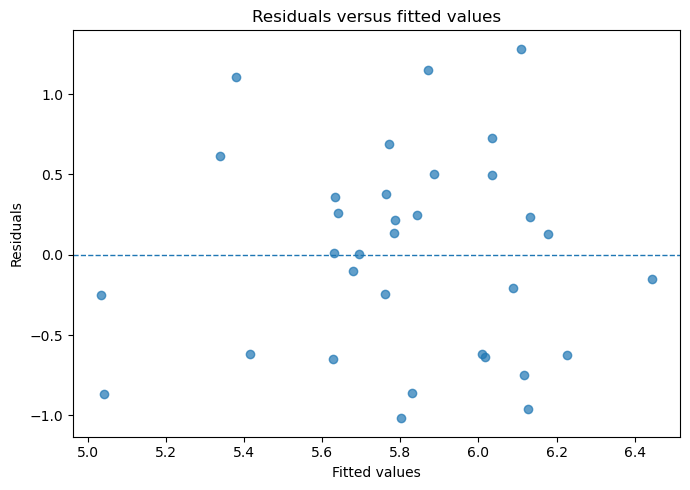

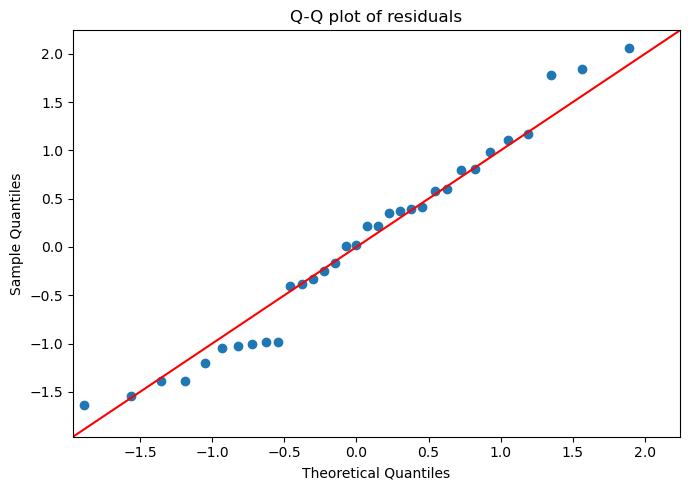

,metric,value
0,Mean residual,-0.000000000000004387
1,Standard deviation,0.6325
2,Minimum residual,-1.0172
3,Maximum residual,1.2821


In [226]:
fitted_values = ols_results.fittedvalues
residuals = ols_results.resid

diagnostic_data = pd.DataFrame({
    "fitted_values": fitted_values,
    "residuals": residuals
})

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    diagnostic_data["fitted_values"],
    diagnostic_data["residuals"],
    alpha=0.7
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_title("Residuals versus fitted values")
ax.set_xlabel("Fitted values")
ax.set_ylabel("Residuals")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))

sm.qqplot(
    residuals,
    line="45",
    fit=True,
    ax=ax
)

ax.set_title("Q-Q plot of residuals")

plt.tight_layout()
plt.show()

residual_summary = pd.DataFrame({
    "metric": [
        "Mean residual",
        "Standard deviation",
        "Minimum residual",
        "Maximum residual"
    ],
    "value": [
        residuals.mean(),
        residuals.std(),
        residuals.min(),
        residuals.max()
    ]
})

residual_summary["value"] = residual_summary["value"].apply(
    lambda x: f"{x:.18f}" if abs(x) < 0.0001 else f"{x:.4f}"
)

display(residual_summary)

En el gráfico de residuos versus valores ajustados, los puntos se distribuyen alrededor de cero sin un patrón demasiado marcado, por lo que no se observa una señal fuerte de no linealidad. De todas formas, hay algo de dispersión en los residuos, con valores entre -1,0172 y 1,2821.

En el Q-Q plot, la mayoría de los puntos sigue razonablemente la línea teórica, aunque se observan pequeñas desviaciones en los extremos. En general, los supuestos del modelo OLS parecen defendibles para este análisis. Si se quisiera mejorar el ajuste, el siguiente paso podría ser probar errores estándar robustos, más que cambiar directamente el outcome.

## Part 4: Ecological Fallacy

En este trabajo, todos los análisis se hicieron a nivel de comuna. Esto significa que cada observación representa una comuna completa y no una persona individual. Por eso, cuando encontramos una relación entre variables como `pct_foreign` y `eno_rate_per_10k`, estamos hablando de una asociación comunal. No es lo mismo decir que una comuna con mayor porcentaje de población extranjera tiene una mayor tasa esperada de notificaciones ENO, que decir que una persona extranjera tiene más probabilidad individual de ser notificada. Esa segunda conclusión no se puede obtener con estos datos, porque no estamos comparando personas, sino territorios. Dentro de una misma comuna pueden vivir personas con características muy distintas, y el promedio comunal no permite saber qué ocurre con cada individuo.

Un ejemplo concreto aparece en el modelo Negative Binomial para ENO. En ese modelo, `pct_foreign` tuvo un IRR cercano a 1,0516. A nivel comunal, esto indica que las comunas con mayor porcentaje de población extranjera tienden a presentar una mayor tasa esperada de notificaciones ENO, manteniendo constantes las demás covariables. El error sería interpretar esto como si las personas extranjeras, por el solo hecho de ser extranjeras, tuvieran más riesgo individual de ser notificadas. Esa lectura sería incorrecta, porque el modelo no compara personas extranjeras con personas chilenas. Lo que realmente compara son comunas con distintas características agregadas. Además, una mayor tasa ENO comunal podría depender de otros elementos, como mayor acceso a atención, mejor capacidad de detección, más registros sanitarios, movilidad diaria o condiciones locales específicas.

Aun así, este tipo de asociación sí puede ser útil para planificación en salud pública. Por ejemplo, en el mapa de tasas ENO predichas, comunas como Valparaíso y Quinta Normal aparecen con valores altos por cada 10.000 habitantes. Esto no permite afirmar una causa individual, pero sí ayuda a identificar territorios donde podría ser razonable reforzar vigilancia sanitaria, revisar capacidad de atención o estudiar con más detalle qué factores locales están influyendo. También puede servir para priorizar recursos, detectar comunas que se alejan de lo esperado y orientar preguntas futuras. En ese sentido, el análisis comunal no sirve para decir qué le pasa a una persona en particular, pero sí puede entregar señales útiles sobre dónde mirar con más atención desde una perspectiva territorial.

Una amenaza adicional a la inferencia es que pueden existir variables omitidas. El modelo incluye composición migrante, educación, empleo y acceso a internet fija, pero no considera otros factores que también podrían afectar las notificaciones ENO, como disponibilidad de centros de salud, distancia a hospitales, movilidad diaria, fiscalización sanitaria o diferencias en calidad de registro. Si esas variables están relacionadas con las covariables incluidas, parte de sus efectos podría quedar mezclada en los coeficientes del modelo. Además, comunas cercanas pueden compartir servicios, flujos de población y dinámicas sanitarias, generando autocorrelación espacial. En futuros análisis se podría abordar esto incorporando variables espaciales, revisando autocorrelación de residuos o usando modelos que consideren dependencia territorial. También sería útil complementar este trabajo con datos individuales, porque eso permitiría distinguir mejor entre patrones comunales y diferencias reales entre personas.

## Part 5: Spatial Visualization of Model Output

### 5.1 Predicted-rate map

Para el mapa de tasas predichas se usa el modelo de conteo principal definido en la Parte 2 y la base definitiva `analytical_table_final`. A partir del conteo predicho de ENO, se calcula la tasa por cada 10.000 habitantes y se une con el shapefile de comunas para construir el mapa coroplético

En la visualización se incorporaron etiquetas comunales sobre el mapa. Para mejorar la legibilidad de las comunas que presentaban mayor sobreposición en sus etiquetas, se usaron flechas para desplazar las etiquetas sin perder la referencia del territorio original.

Escala usada
Mínimo = 33.69
Máximo = 104.74


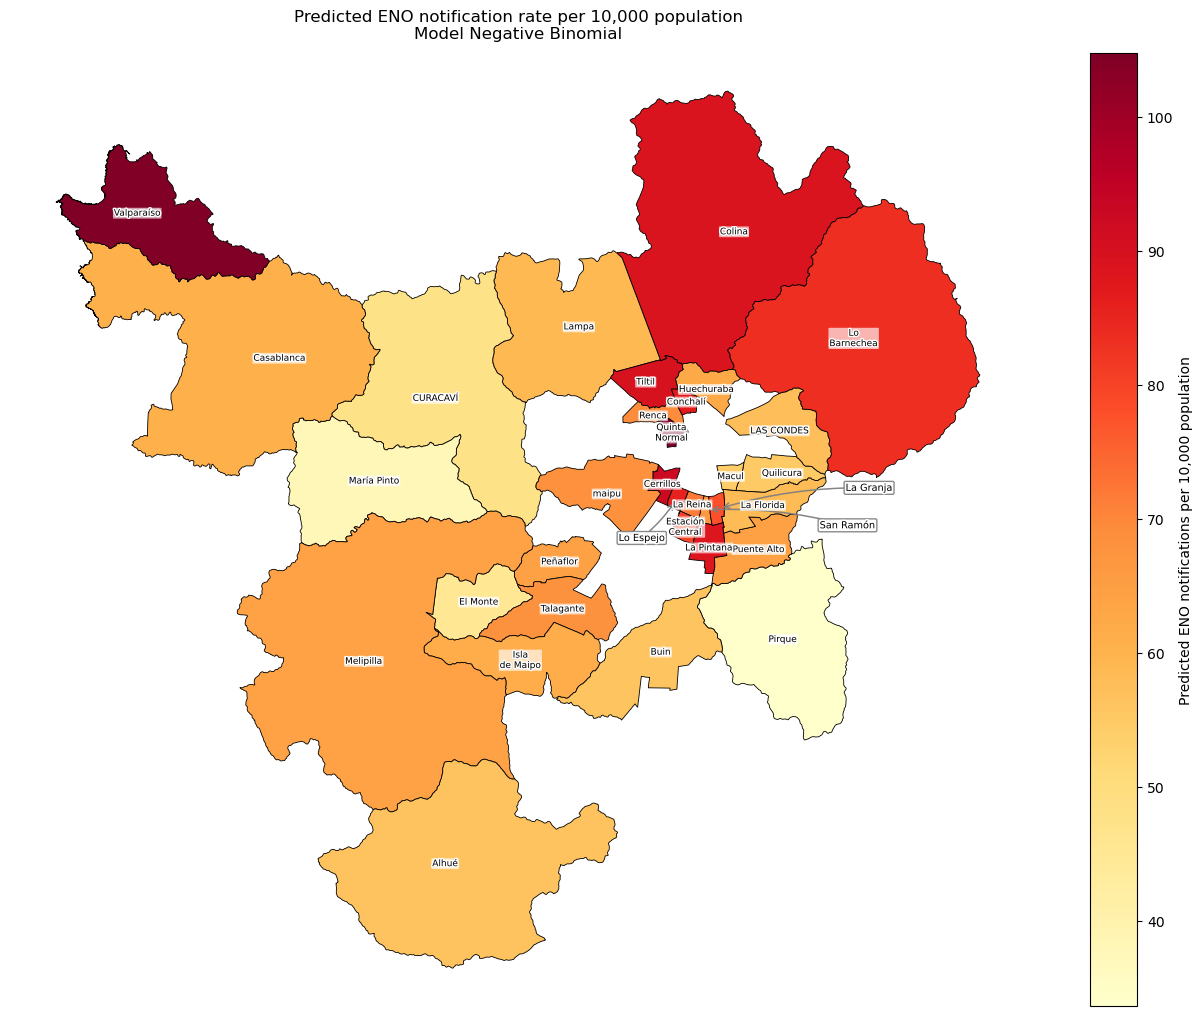

,codigo_comuna,nombre_comuna,pop_total,eno_total,eno_rate_per_10k,predicted_eno_total,predicted_eno_rate_per_10k
24,5101,Valparaíso,284938,4821,169.190000,2984.54,104.74
22,13126,Quinta Normal,129351,1361,105.217586,1354.00,104.68
10,13102,Cerrillos,85041,642,75.490000,784.63,92.27
21,13125,Tiltil,205624,1592,77.420000,1841.61,89.56
3,13301,Colina,173293,1259,72.650000,1543.40,89.06
15,13112,La Pintana,175421,1507,85.907617,1550.77,88.40
11,13104,Conchalí,121587,1134,93.266550,1055.18,86.78
18,13116,Lo Espejo,87295,678,77.667679,747.72,85.65
17,13115,Lo Barnechea,112620,630,55.940000,941.80,83.63
12,13105,Estación Central,155257,1212,78.060000,1240.05,79.87


In [233]:
map_data = analytical_table_final.copy()

zip_path = Path("Comunas.zip")
extract_dir = Path("Comunas")

if zip_path.exists() and not extract_dir.exists():
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)

shp_files = list(Path(".").rglob("comunas.shp"))

if len(shp_files) == 0:
    raise FileNotFoundError("No se encontró comunas.shp")

shp_path = shp_files[0]

os.environ["SHAPE_RESTORE_SHX"] = "YES"
comunas_gdf = gpd.read_file(shp_path)

code_col = "cod_comuna"

if code_col not in comunas_gdf.columns:
    raise ValueError(f"No existe la columna {code_col} en el shapefile.")

covariates = [
    "pct_foreign",
    "schooling_gap",
    "pct_unemployed",
    "pct_without_fixed_internet"
]

for col in ["codigo_comuna", "pop_total"] + covariates:
    map_data[col] = pd.to_numeric(
        map_data[col],
        errors="coerce"
    )

map_data = map_data.dropna(
    subset=["codigo_comuna", "pop_total"] + covariates
).copy()

map_data = map_data[
    map_data["pop_total"] > 0
].copy()

map_data["codigo_comuna"] = (
    map_data["codigo_comuna"]
    .astype(int)
    .astype(str)
)

# Preparar predicción
X_map = sm.add_constant(
    map_data[covariates],
    has_constant="add"
)

offset_map = np.log(map_data["pop_total"])

selected_count_model = nb_results
selected_count_model_name = "Negative Binomial"

map_data["predicted_eno_total"] = selected_count_model.predict(
    exog=X_map,
    offset=offset_map
)

map_data["predicted_eno_rate_per_10k"] = (
    map_data["predicted_eno_total"] /
    map_data["pop_total"] *
    10000
)

# Preparar llave espacial
comunas_gdf[code_col] = (
    comunas_gdf[code_col]
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

# Unir datos con mapa
map_gdf = comunas_gdf.merge(
    map_data[
        [
            "codigo_comuna",
            "nombre_comuna",
            "pop_total",
            "eno_total",
            "eno_rate_per_10k",
            "predicted_eno_total",
            "predicted_eno_rate_per_10k"
        ]
    ],
    left_on=code_col,
    right_on="codigo_comuna",
    how="inner"
)

value_col = "predicted_eno_rate_per_10k"

vmin = map_gdf[value_col].min()
vmax = map_gdf[value_col].max()

print("Escala usada")
print(f"Mínimo = {vmin:.2f}")
print(f"Máximo = {vmax:.2f}")

cmap = plt.cm.YlOrRd
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

fig, ax = plt.subplots(figsize=(13, 13))

map_gdf.plot(
    column=value_col,
    cmap=cmap,
    norm=norm,
    edgecolor="black",
    linewidth=0.6,
    ax=ax,
    legend=False
)

# Barra de color
sm_color = mpl.cm.ScalarMappable(
    cmap=cmap,
    norm=norm
)

sm_color.set_array([])

cbar = fig.colorbar(
    sm_color,
    ax=ax,
    shrink=0.75
)

cbar.set_label("Predicted ENO notifications per 10,000 population")

# Puntos para etiquetas
label_points = map_gdf.geometry.representative_point()
map_gdf["label_x"] = label_points.x
map_gdf["label_y"] = label_points.y

xmin, ymin, xmax, ymax = map_gdf.total_bounds
dx = (xmax - xmin) * 0.035
dy = (ymax - ymin) * 0.035

def format_label(name):
    name = str(name).strip()
    words = name.split()

    if len(words) == 2 and len(name) >= 12:
        return words[0] + "\n" + words[1]

    if len(words) >= 3:
        cut = len(words) // 2
        return " ".join(words[:cut]) + "\n" + " ".join(words[cut:])

    return name

arrow_offsets = {
    "lo espejo": (-1.1 * dx, -1.3 * dy),
    "san ramón": (4.4 * dx, -0.5 * dy),
    "la granja": (4.7 * dx, 0.7 * dy)
}

# Agregar etiquetas
for _, row in map_gdf.iterrows():
    original_name = str(row["nombre_comuna"])
    name_std = original_name.strip().lower()
    label_text = format_label(original_name)

    x = row["label_x"]
    y = row["label_y"]

    if name_std in arrow_offsets:
        offx, offy = arrow_offsets[name_std]
        tx = x + offx
        ty = y + offy

        ax.annotate(
            "",
            xy=(x, y),
            xytext=(tx, ty),
            arrowprops=dict(
                arrowstyle="->",
                color="gray",
                lw=1.1,
                alpha=0.95,
                shrinkA=4,
                shrinkB=4,
                connectionstyle="arc3,rad=0.08"
            ),
            zorder=8
        )

        ax.text(
            tx,
            ty,
            label_text,
            fontsize=7,
            ha="center",
            va="center",
            color="black",
            bbox=dict(
                facecolor="white",
                edgecolor="gray",
                alpha=0.92,
                boxstyle="round,pad=0.15"
            ),
            path_effects=[
                pe.withStroke(
                    linewidth=2.2,
                    foreground="white"
                )
            ],
            zorder=9
        )

    else:
        ax.text(
            x,
            y,
            label_text,
            fontsize=6.5,
            ha="center",
            va="center",
            color="black",
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.65,
                boxstyle="round,pad=0.10"
            ),
            path_effects=[
                pe.withStroke(
                    linewidth=2,
                    foreground="white"
                )
            ],
            zorder=9
        )

ax.set_title(
    f"Predicted ENO notification rate per 10,000 population\nModel {selected_count_model_name}",
    fontsize=12
)

ax.set_axis_off()
plt.tight_layout()
plt.show()

predicted_rate_table = map_gdf[
    [
        "codigo_comuna",
        "nombre_comuna",
        "pop_total",
        "eno_total",
        "eno_rate_per_10k",
        "predicted_eno_total",
        "predicted_eno_rate_per_10k"
    ]
].copy()

predicted_rate_table["predicted_eno_total"] = (
    predicted_rate_table["predicted_eno_total"].round(2)
)

predicted_rate_table["predicted_eno_rate_per_10k"] = (
    predicted_rate_table["predicted_eno_rate_per_10k"].round(2)
)

display(
    predicted_rate_table.sort_values(
        "predicted_eno_rate_per_10k",
        ascending=False
    )
)

Las tasas más altas se observan en Valparaíso y Quinta Normal, ambas sobre 104 casos predichos por cada 10.000 habitantes, seguidas por Cerrillos, Tiltil, Colina y La Pintana. En el extremo más bajo aparecen Pirque, María Pinto, El Monte y Curacaví, con tasas predichas considerablemente menores.

### 5.2 Residual map

Construimos el mapa de residuos de Pearson usando el mismo modelo de conteo utilizado en el mapa anterior. Los residuos comparan los casos ENO observados con los casos predichos, y el mapa usa una paleta divergente centrada en cero para distinguir comunas donde el modelo subestima o sobreestima.

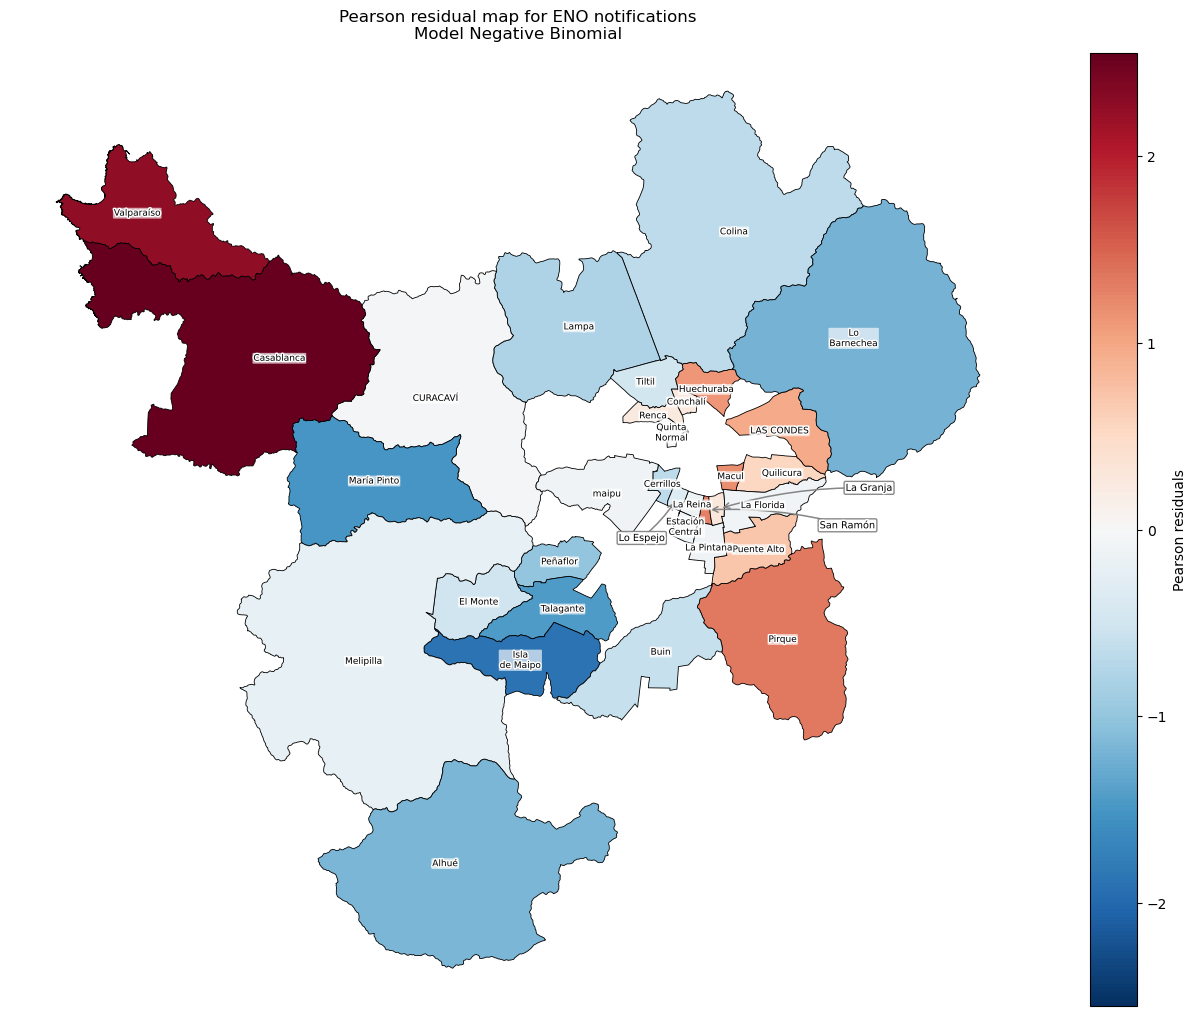

Largest positive residuals


,codigo_comuna,nombre_comuna,eno_total,predicted_eno_total,pearson_residual
23,5102,Casablanca,312,181.57,2.553
24,5101,Valparaíso,4821,2984.54,2.262
5,13202,Pirque,136,97.90,1.344
0,13131,San Ramón,687,507.11,1.290
19,13118,Macul,890,671.42,1.187


Largest negative residuals


,codigo_comuna,nombre_comuna,eno_total,predicted_eno_total,pearson_residual
29,13603,Isla de Maipo,115,242.15,-1.882
9,13504,María Pinto,32,58.46,-1.502
28,13601,Talagante,314,519.32,-1.438
17,13115,Lo Barnechea,630,941.80,-1.211
32,13502,Alhué,28,43.92,-1.167


In [237]:
residual_map_gdf = map_gdf.copy()

residual_map_gdf["eno_total"] = pd.to_numeric(
    residual_map_gdf["eno_total"],
    errors="coerce"
)

residual_map_gdf["predicted_eno_total"] = pd.to_numeric(
    residual_map_gdf["predicted_eno_total"],
    errors="coerce"
)

residual_map_gdf = residual_map_gdf.dropna(
    subset=["eno_total", "predicted_eno_total"]
).copy()

mu = residual_map_gdf["predicted_eno_total"]
y_obs = residual_map_gdf["eno_total"]

# Varianza del modelo
if selected_count_model_name == "Negative Binomial":
    alpha = selected_count_model.params.get("alpha", 0)
    variance = mu + alpha * (mu ** 2)
else:
    variance = mu

# Residuos de Pearson
residual_map_gdf["pearson_residual"] = (
    (y_obs - mu) / np.sqrt(variance)
)

max_abs_resid = residual_map_gdf["pearson_residual"].abs().max()

norm_resid = mpl.colors.TwoSlopeNorm(
    vmin=-max_abs_resid,
    vcenter=0,
    vmax=max_abs_resid
)

fig, ax = plt.subplots(figsize=(13, 13))

residual_map_gdf.plot(
    column="pearson_residual",
    cmap="RdBu_r",
    norm=norm_resid,
    edgecolor="black",
    linewidth=0.6,
    ax=ax,
    legend=False
)

# Barra de color
sm_color = mpl.cm.ScalarMappable(
    cmap="RdBu_r",
    norm=norm_resid
)

sm_color.set_array([])

cbar = fig.colorbar(
    sm_color,
    ax=ax,
    shrink=0.75
)

cbar.set_label("Pearson residuals")

# Puntos para etiquetas
label_points = residual_map_gdf.geometry.representative_point()
residual_map_gdf["label_x"] = label_points.x
residual_map_gdf["label_y"] = label_points.y

xmin, ymin, xmax, ymax = residual_map_gdf.total_bounds
dx = (xmax - xmin) * 0.035
dy = (ymax - ymin) * 0.035

def format_label(name):
    name = str(name).strip()
    words = name.split()

    if len(words) == 2 and len(name) >= 12:
        return words[0] + "\n" + words[1]

    if len(words) >= 3:
        cut = len(words) // 2
        return " ".join(words[:cut]) + "\n" + " ".join(words[cut:])

    return name

arrow_offsets = {
    "lo espejo": (-1.1 * dx, -1.3 * dy),
    "san ramón": (4.4 * dx, -0.5 * dy),
    "la granja": (4.7 * dx, 0.7 * dy)
}

# Agregar etiquetas
for _, row in residual_map_gdf.iterrows():
    original_name = str(row["nombre_comuna"])
    name_std = original_name.strip().lower()
    label_text = format_label(original_name)

    x = row["label_x"]
    y = row["label_y"]

    if name_std in arrow_offsets:
        offx, offy = arrow_offsets[name_std]
        tx = x + offx
        ty = y + offy

        ax.annotate(
            "",
            xy=(x, y),
            xytext=(tx, ty),
            arrowprops=dict(
                arrowstyle="->",
                color="gray",
                lw=1.1,
                alpha=0.95,
                shrinkA=4,
                shrinkB=4,
                connectionstyle="arc3,rad=0.08"
            ),
            zorder=8
        )

        ax.text(
            tx,
            ty,
            label_text,
            fontsize=7,
            ha="center",
            va="center",
            color="black",
            bbox=dict(
                facecolor="white",
                edgecolor="gray",
                alpha=0.92,
                boxstyle="round,pad=0.15"
            ),
            path_effects=[
                pe.withStroke(
                    linewidth=2.2,
                    foreground="white"
                )
            ],
            zorder=9
        )

    else:
        ax.text(
            x,
            y,
            label_text,
            fontsize=6.5,
            ha="center",
            va="center",
            color="black",
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.65,
                boxstyle="round,pad=0.10"
            ),
            path_effects=[
                pe.withStroke(
                    linewidth=2,
                    foreground="white"
                )
            ],
            zorder=9
        )

ax.set_title(
    f"Pearson residual map for ENO notifications\nModel {selected_count_model_name}",
    fontsize=12
)

ax.set_axis_off()
plt.tight_layout()
plt.show()

residual_table = residual_map_gdf[
    [
        "codigo_comuna",
        "nombre_comuna",
        "eno_total",
        "predicted_eno_total",
        "pearson_residual"
    ]
].copy()

residual_table["predicted_eno_total"] = (
    residual_table["predicted_eno_total"].round(2)
)

residual_table["pearson_residual"] = (
    residual_table["pearson_residual"].round(3)
)

largest_positive_residuals = (
    residual_table
    .sort_values("pearson_residual", ascending=False)
    .head(5)
)

largest_negative_residuals = (
    residual_table
    .sort_values("pearson_residual", ascending=True)
    .head(5)
)

print("Largest positive residuals")
display(largest_positive_residuals)

print("Largest negative residuals")
display(largest_negative_residuals)

Los residuos positivos más altos aparecen en Casablanca, Valparaíso, Pirque, San Ramón y Macul. Esto significa que en esas comunas las notificaciones ENO observadas fueron mayores que las predichas por el modelo. Una posible explicación es que estas comunas tengan factores locales que el modelo no captura, como diferencias en acceso al sistema de salud, mayor detección de casos, brotes específicos o dinámicas territoriales que no están representadas por las covariables que usamos.

Los residuos negativos más fuertes aparecen en Isla de Maipo, María Pinto, Talagante, Lo Barnechea y Alhué. En estos casos, el modelo predijo más notificaciones ENO de las que realmente se observaron. Esto podría deberse a menor registro o detección de casos, diferencias en la demanda efectiva de atención, o simplemente a que las variables del modelo sobreestiman el riesgo esperado en comunas con características particulares.n.

### 5.3 Coefficient plot

Construimos un coefficient plot para el modelo principal de conteo. Como el modelo usa enlace logarítmico, los coeficientes se muestran como IRR, lo que permite ver si cada covariable aumenta o disminuye la tasa esperada de notificaciones ENO. La línea vertical en 1 marca el efecto nulo.

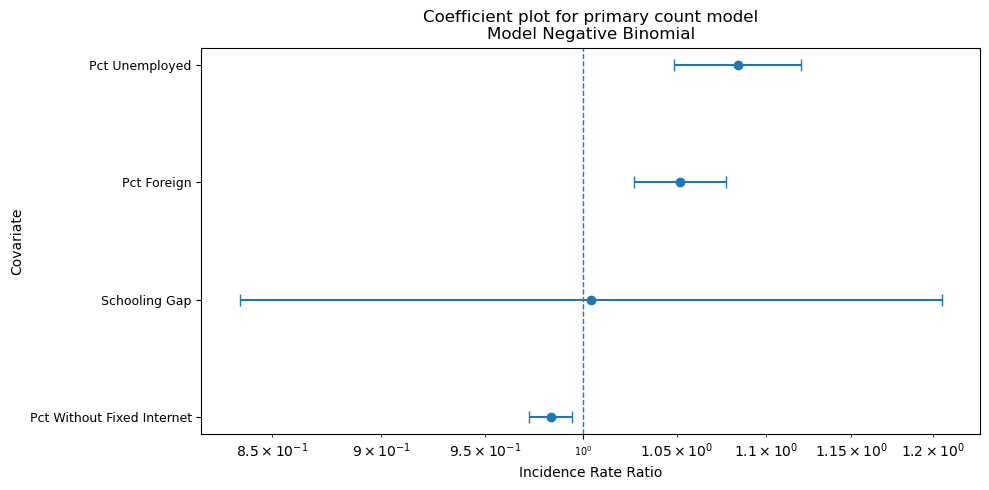

,variable,coef,std_error,p_value,IRR,IRR_ci_low,IRR_ci_high
4,pct_without_fixed_internet,-0.0171,0.0058,0.0032,0.9831,0.9720,0.9943
2,schooling_gap,0.0041,0.0934,0.9654,1.0041,0.8361,1.2058
1,pct_foreign,0.0503,0.0123,0.0000,1.0516,1.0266,1.0772
3,pct_unemployed,0.0805,0.0170,0.0000,1.0839,1.0484,1.1205


In [241]:
primary_count_results = nb_results
primary_count_model_name = "Negative Binomial"

# Crear tabla base
coef_plot_table = pd.DataFrame({
    "variable": primary_count_results.params.index,
    "coef": primary_count_results.params.values,
    "std_error": primary_count_results.bse.values,
    "p_value": primary_count_results.pvalues.values
})

conf = primary_count_results.conf_int()

coef_plot_table["coef_ci_low"] = conf.iloc[:, 0].values
coef_plot_table["coef_ci_high"] = conf.iloc[:, 1].values

# Quitar términos no usados
coef_plot_table = coef_plot_table[
    ~coef_plot_table["variable"].isin(["const", "alpha"])
].copy()

# Calcular IRR
coef_plot_table["IRR"] = np.exp(coef_plot_table["coef"])
coef_plot_table["IRR_ci_low"] = np.exp(coef_plot_table["coef_ci_low"])
coef_plot_table["IRR_ci_high"] = np.exp(coef_plot_table["coef_ci_high"])

# Crear etiquetas
coef_plot_table["label"] = (
    coef_plot_table["variable"]
    .str.replace("_", " ", regex=False)
    .str.title()
)

coef_plot_table = coef_plot_table.sort_values("IRR").copy()

# Calcular barras de error
x = coef_plot_table["IRR"]
xerr_low = coef_plot_table["IRR"] - coef_plot_table["IRR_ci_low"]
xerr_high = coef_plot_table["IRR_ci_high"] - coef_plot_table["IRR"]

fig, ax = plt.subplots(figsize=(10, 5))

ax.errorbar(
    x,
    coef_plot_table["label"],
    xerr=[xerr_low, xerr_high],
    fmt="o",
    capsize=4
)

# Línea de efecto nulo
ax.axvline(
    1,
    linestyle="--",
    linewidth=1
)

# Ajustar eje X
ax.set_xscale("log")

x_min = coef_plot_table["IRR_ci_low"].min() * 0.98
x_max = coef_plot_table["IRR_ci_high"].max() * 1.02

ax.set_xlim(x_min, x_max)
ax.tick_params(axis="x", labelsize=7)
ax.tick_params(axis="y", labelsize=9)

ax.set_xlabel("Incidence Rate Ratio")
ax.set_ylabel("Covariate")
ax.set_title(
    f"Coefficient plot for primary count model\nModel {primary_count_model_name}"
)

plt.tight_layout()
plt.show()

# Tabla de apoyo
coef_plot_display = coef_plot_table[
    [
        "variable",
        "coef",
        "std_error",
        "p_value",
        "IRR",
        "IRR_ci_low",
        "IRR_ci_high"
    ]
].copy()

coef_plot_display = coef_plot_display.round(4)

display(coef_plot_display)

El coefficient plot muestra que `pct_unemployed` tiene el IRR más alto, con un valor de 1.0839, seguido por `pct_foreign` con un IRR de 1,0516. Ambos intervalos de confianza quedan por sobre 1, por lo que sus efectos se ubican claramente en el lado positivo.

`pct_without_fixed_internet` presenta un IRR de 0,9831 y su intervalo queda bajo 1, mostrando un efecto negativo. En cambio, `schooling_gap` tiene un IRR cercano a 1, con un intervalo amplio que cruza la línea nula, por lo que es la covariable con menor evidencia visual de efecto.

## Part 6: Integrated Synthesis

El retrato demográfico a nivel comunal muestra una base bastante heterogénea, donde las comunas no se diferencian solo por tamaño poblacional, sino también por acceso a servicios, composición migrante, empleo y escolaridad. El eje dominante de variación parece estar relacionado con el grado de urbanización y acceso a servicios. Esto se observa claramente en la matriz de correlación, donde `log_pop_total` y `pct_without_fixed_internet` tienen una correlación cercana a -0,70. Es decir, las comunas con mayor población tienden a tener menor porcentaje de hogares sin internet fija, mientras que comunas más pequeñas presentan mayores brechas de acceso. También aparece una relación negativa entre `pct_foreign` y `pct_unemployed`, cercana a -0,59, lo que sugiere que las comunas con mayor porcentaje de población extranjera no necesariamente son las que tienen más no empleo. En conjunto, el patrón demográfico no se reduce a una sola variable, pero sí parece ordenarse principalmente entre comunas más urbanas e integradas y comunas con menor acceso a servicios o más periféricas.

El panorama de salud no calza perfectamente con ese eje demográfico, aunque sí se relaciona con algunas de sus dimensiones. En ENO, el mapa de tasas predichas muestra que Valparaíso y Quinta Normal tienen las tasas más altas, con valores cercanos a 104,74 y 104,68 notificaciones predichas por cada 10.000 habitantes. También aparecen con valores altos Cerrillos, Tiltil, Colina y La Pintana. En cambio, comunas como Pirque, María Pinto y Curacaví muestran tasas predichas más bajas. Esto indica que las notificaciones ENO no dependen solamente del tamaño poblacional o del acceso a servicios, ya que también parecen intervenir factores locales como movilidad, capacidad de detección, diferencias de registro o presencia de servicios. En GRD ocurre algo similar, pero con otro patrón. Melipilla aparece como un outlier visual importante en varios gráficos de `grd_rate_per_10k`, con tasas de egresos hospitalarios bastante altas. Esto puede explicarse porque algunas comunas funcionan como centros de atención para personas de zonas cercanas, por lo que sus indicadores de salud pueden reflejar más que las características de sus residentes. Así, los resultados de salud coinciden parcialmente con el retrato demográfico, pero también muestran casos que se escapan de ese eje.

Los modelos cruzados agregan información que no se ve directamente en una sola base ni en la matriz de correlación. En el modelo ENO, el Poisson presentó sobredispersión alta, con un estadístico de 61,45, por lo que se eligió Negative Binomial como modelo principal. En ese modelo, `pct_unemployed` tuvo el IRR más alto, con 1,0839, seguido por `pct_foreign`, con 1,0516. Esto indica que, manteniendo constantes las demás covariables, ambas variables se asociaron con una mayor tasa esperada de notificaciones ENO. En cambio, `pct_without_fixed_internet` tuvo un IRR de 0.9831, y `schooling_gap` quedó prácticamente sin efecto claro. Para GRD también fue necesario usar Negative Binomial, ya que la dispersión del Poisson fue muy alta, con 2872,8512, y el AIC bajó desde 85709,6334 a 659,5144. Sin embargo, en GRD las covariables no fueron significativas al 5%, aunque `schooling_gap` tuvo el mayor efecto, con un IRR de 0,7276 y un p-value de 0,0579. Esto muestra que ENO y GRD no siguen exactamente el mismo patrón comunal. Además, los residuos ayudan a detectar comunas que el modelo no logra explicar bien. Casablanca y Valparaíso tuvieron residuos positivos altos en ENO, mientras que Isla de Maipo y María Pinto tuvieron residuos negativos importantes. Por lo mismo, el aporte principal del análisis integrado es mostrar que las variables demográficas sí ayudan a explicar parte del comportamiento sanitario, pero todavía quedan diferencias locales que no se explican solo con census, ENO o GRD por separado.